# ECF 2021 — Comportamiento financiero e Insight Discovery Engine

## Pregunta estratégica

**¿Es necesario adaptar las ofertas actuales de Banco Atlas o crear otras nuevas en función de las tendencias nacionales de comportamiento financiero?**

Este notebook parte exclusivamente del fichero Stata original, conserva sus variables y metadatos, reconstruye indicadores con trazabilidad, controla circularidad y redundancia, ejecuta pruebas estadísticas automáticas, corrige los contrastes mediante FDR y prepara una shortlist de historias para revisión humana.

Las relaciones identificadas son asociativas. No deben interpretarse como causalidad.

## 0. Librerías y configuración

In [1]:
from pathlib import Path
from collections import defaultdict
import json
import math
import re
import unicodedata
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from statsmodels.stats.multitest import multipletests
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 160)
pd.set_option("display.max_rows", 160)
pd.set_option("display.max_colwidth", 220)

warnings.filterwarnings("default")

## 1. Rutas del proyecto

In [2]:
SCRIPTS_DIR = Path.cwd().resolve()
DATA_DIR = (SCRIPTS_DIR / "../Data").resolve()
RAW_PATH = DATA_DIR / "2026-07-20_ECF_2021_01_raw.dta"

if not RAW_PATH.exists():
    raise FileNotFoundError(
        f"No se encuentra el fichero requerido: {RAW_PATH}\n"
        "Ejecuta el notebook desde la carpeta Scripts y comprueba que el fichero está en ../Data/."
    )

PRIVATE_DIR = (SCRIPTS_DIR / "../Private").resolve()
PRIVATE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Scripts: {SCRIPTS_DIR}")
print(f"Datos:   {DATA_DIR}")
print(f"Raw:     {RAW_PATH.name}")

Scripts: /Users/rogerdefez/Documents/Cursos i Llibres/BootCamp IT Academy/04_Simulador/ProjecteData/Equip_32/Scripts
Datos:   /Users/rogerdefez/Documents/Cursos i Llibres/BootCamp IT Academy/04_Simulador/ProjecteData/Equip_32/Data
Raw:     2026-07-20_ECF_2021_01_raw.dta


## 2. Carga doble del fichero Stata y auditoría estructural

In [3]:
stata_reader = pd.io.stata.StataReader(RAW_PATH)
VARIABLE_LABELS = stata_reader.variable_labels()
VALUE_LABEL_SETS = stata_reader.value_labels()
VALUE_LABEL_NAMES = list(getattr(stata_reader, "_lbllist", []))
RAW_COLUMNS_METADATA = list(VARIABLE_LABELS)

df_raw_codigos = pd.read_stata(RAW_PATH, convert_categoricals=False)
df_raw_etiquetas = pd.read_stata(RAW_PATH, convert_categoricals=True)

checks_carga = {
    "filas_codigos": df_raw_codigos.shape[0],
    "columnas_codigos": df_raw_codigos.shape[1],
    "filas_etiquetas": df_raw_etiquetas.shape[0],
    "columnas_etiquetas": df_raw_etiquetas.shape[1],
    "misma_forma": df_raw_codigos.shape == df_raw_etiquetas.shape,
    "mismo_orden_columnas": list(df_raw_codigos.columns) == list(df_raw_etiquetas.columns),
    "duplicados_fila_codigos": int(df_raw_codigos.duplicated().sum()),
    "duplicados_fila_etiquetas": int(df_raw_etiquetas.duplicated().sum()),
    "columnas_duplicadas_codigos": int(pd.Index(df_raw_codigos.columns).duplicated().sum()),
    "columnas_duplicadas_etiquetas": int(pd.Index(df_raw_etiquetas.columns).duplicated().sum()),
}
display(pd.DataFrame([checks_carga]))

assert checks_carga["misma_forma"], "Las dos lecturas del fichero no tienen la misma forma."
assert checks_carga["mismo_orden_columnas"], "El orden de columnas difiere entre lecturas."
assert df_raw_codigos.shape[1] == 429, (
    f"Se esperaban 429 variables originales y se han encontrado {df_raw_codigos.shape[1]}."
)

print(f"Carga confirmada: {df_raw_codigos.shape[0]:,} observaciones × {df_raw_codigos.shape[1]} variables originales.")

/var/folders/6f/lhr87vh51bq38sm9v46389m00000gn/T/ipykernel_22209/993767256.py:2: ResourceWarning: StataReader is being used without using a context manager. Using StataReader as a context manager is the only supported method.
  VARIABLE_LABELS = stata_reader.variable_labels()


,filas_codigos,columnas_codigos,filas_etiquetas,columnas_etiquetas,misma_forma,mismo_orden_columnas,duplicados_fila_codigos,duplicados_fila_etiquetas,columnas_duplicadas_codigos,columnas_duplicadas_etiquetas
0,7764,429,7764,429,True,True,0,0,0,0


Carga confirmada: 7,764 observaciones × 429 variables originales.


## 3. Utilidades de metadatos, bloques y familias multirrespuesta

In [4]:
def normalizar_texto(value):
    """Normaliza texto para búsquedas conservadoras."""
    text = "" if value is None else str(value)
    text = unicodedata.normalize("NFKD", text)
    text = "".join(ch for ch in text if not unicodedata.combining(ch))
    return re.sub(r"\s+", " ", text).strip().lower()


def bloque_ecf(variable):
    """Asigna el bloque del cuestionario a partir del prefijo técnico."""
    if variable == "ccaaf":
        return "Perfil territorial"
    match = re.match(r"^([a-k])", variable.lower())
    if not match:
        return "Otros"
    letter = match.group(1).upper()
    labels = {
        "A": "A — Perfil y contexto",
        "B": "B — Banco, productos y ahorro",
        "C": "C — Ingresos",
        "D": "D — Conducta y actitudes",
        "E": "E — Competencias financieras",
        "F": "F — Toma de decisiones en el hogar",
        "G": "G — Pensiones",
        "H": "H — Seguros",
        "I": "I — Vivienda",
        "J": "J — Fragilidad, crédito y resiliencia",
        "K": "K — Variables complementarias",
    }
    return labels.get(letter, "Otros")


def familia_multirrespuesta(variable):
    """Detecta sufijos alfabéticos de opciones sin agrupar las columnas."""
    match = re.match(r"^([a-z]\d{4})(?:_?)([a-z])$", variable.lower())
    return match.group(1) if match else ""


def separar_pregunta_opcion(label, variable):
    """Separa pregunta y opción solo cuando la etiqueta ofrece un separador claro."""
    label = (label or "").strip()
    family = familia_multirrespuesta(variable)
    if not family:
        return label, ""
    patterns = [r"\s+-\s+", r"\s+–\s+", r"\s+—\s+", r":\s+"]
    for pattern in patterns:
        parts = re.split(pattern, label, maxsplit=1)
        if len(parts) == 2 and min(map(len, parts)) >= 3:
            return parts[0].strip(), parts[1].strip()
    return label, ""


def value_label_name_for_position(position):
    """Devuelve el nombre del conjunto de etiquetas asociado por posición, si existe."""
    if position < len(VALUE_LABEL_NAMES):
        return VALUE_LABEL_NAMES[position] or ""
    return ""


def es_multirrespuesta(variable):
    return bool(familia_multirrespuesta(variable))

## 4. Catálogo original de las 429 variables

In [5]:
catalog_rows = []
for position, variable in enumerate(df_raw_codigos.columns):
    label = VARIABLE_LABELS.get(variable, "")
    pregunta, opcion = separar_pregunta_opcion(label, variable)
    label_set_name = value_label_name_for_position(position)
    catalog_rows.append({
        "variable": variable,
        "pregunta_ecf": pregunta,
        "opcion_respuesta": opcion,
        "bloque_ecf": bloque_ecf(variable),
        "familia_multirrespuesta": familia_multirrespuesta(variable),
        "dtype_codigos": str(df_raw_codigos[variable].dtype),
        "dtype_etiquetas": str(df_raw_etiquetas[variable].dtype),
        "n_unicos": int(df_raw_codigos[variable].nunique(dropna=True)),
        "n_validos": int(df_raw_codigos[variable].notna().sum()),
        "pct_nulos": round(float(df_raw_codigos[variable].isna().mean() * 100), 2),
        "etiqueta_valores_asociada": label_set_name,
        "es_multirrespuesta": es_multirrespuesta(variable),
    })

catalogo_original = pd.DataFrame(catalog_rows)
assert len(catalogo_original) == 429
display(catalogo_original.head(15))

,variable,pregunta_ecf,opcion_respuesta,bloque_ecf,familia_multirrespuesta,dtype_codigos,dtype_etiquetas,n_unicos,n_validos,pct_nulos,etiqueta_valores_asociada,es_multirrespuesta
0,a01,a01: anio de la entrevista,,A — Perfil y contexto,,int16,int16,2,7764,0.0,,False
1,a02,a02: mes de la entrevista,,A — Perfil y contexto,,int8,int8,9,7764,0.0,,False
2,a0000,"a0000: es requisito que pregunte su genero, es vd. hombre o mujer?",,A — Perfil y contexto,,int8,category,2,7764,0.0,A0000,False
3,a0400,a0400: en que anio nacio?,,A — Perfil y contexto,,int16,category,65,7764,0.0,A0400,False
4,a04,a04: edad calculada,,A — Perfil y contexto,,int8,category,64,7764,0.0,A04,False
5,a0800,a0800: me podria decir su edad aproximada?,,A — Perfil y contexto,,int8,category,15,7764,0.0,A0800,False
6,a0100,a0100: en que pais nacio?,,A — Perfil y contexto,,int8,category,2,7764,0.0,A0100,False
7,a0320,a0320: nacio alguno de sus padres fuera de espania?,,A — Perfil y contexto,,int8,category,3,7764,0.0,A0320,False
8,a1030,a1030: cual es su estado civil actual?,,A — Perfil y contexto,,int8,category,7,7764,0.0,A1030,False
9,a1040,a1040: cual es su regimen economico matrimonial?,,A — Perfil y contexto,,int8,category,6,7764,0.0,A1040,False


## 5. Funciones seguras para reconstruir indicadores

In [6]:
def columnas_existentes(data, columns):
    return [c for c in columns if c in data.columns]


ETIQUETAS_CENTINELA = {
    "no sabe", "no contesta", "no ha lugar (no aplica filtro)",
    "no ha lugar (no aplica el filtro)", "-5", "-97", "-98", "-99",
}


def numeric_safe(series):
    """Convierte a numérico de forma segura. Para categóricas ordenadas
    (p. ej. tramo_edad, o preguntas Likert/escala del cuestionario), usa
    los códigos de orden en vez de intentar parsear las etiquetas de texto
    como número (pd.to_numeric fallaría y devolvería NaN en todas las filas).

    Antes de tomar los códigos, se enmascaran como nulos las categorías
    centinela ("No sabe", "No contesta", "No ha lugar...", -5/-97/-98/-99):
    Stata las incluye como categorías reales del value label, y su posición
    en la lista de categorías es arbitraria (a menudo la más baja), por lo
    que sin este enmascarado quedarían codificadas como el valor ordinal
    MÁS BAJO de la escala en vez de como ausencia de respuesta, distorsionando
    cualquier prueba que use estos códigos (Spearman, Mann-Whitney, Kruskal-Wallis).
    """
    if isinstance(series.dtype, pd.CategoricalDtype) and series.dtype.ordered:
        texto = series.astype("string").str.strip().str.lower()
        es_centinela = texto.isin(ETIQUETAS_CENTINELA)
        categorias_validas = [
            c for c in series.cat.categories
            if str(c).strip().lower() not in ETIQUETAS_CENTINELA
        ]
        if len(categorias_validas) == len(series.cat.categories):
            # No hay centinelas que enmascarar: comportamiento original.
            codes = series.cat.codes.astype("float")
            codes = codes.mask(codes.eq(-1))
            return codes
        recategorizada = pd.Categorical(
            series.astype("string").where(~es_centinela),
            categories=[str(c) for c in categorias_validas],
            ordered=True,
        )
        codes = pd.Series(recategorizada.codes, index=series.index).astype("float")
        return codes.mask(codes.eq(-1))
    return pd.to_numeric(series, errors="coerce")


def label_text(series):
    return series.astype("string").map(normalizar_texto)


def valor_binario_por_etiqueta(series):
    """
    Convierte una variable etiquetada de selección múltiple en:

    - 1: opción seleccionada o respuesta afirmativa.
    - 0: opción no seleccionada o respuesta negativa.
    - NA: respuesta ausente o no interpretable.
    """
    text = (
        series.astype("string")
        .str.strip()
        .str.lower()
    )

    negative = text.str.contains(
        r"\b(?:no|no mencionado|no seleccionado)\b",
        na=False,
        regex=True
    )

    positive = text.str.contains(
        r"\b(?:sí|si|mencionado|seleccionado)\b",
        na=False,
        regex=True
    )

    result = pd.Series(pd.NA, index=series.index, dtype="Int64")

    result.loc[negative] = 0
    result.loc[positive & ~negative] = 1

    return result


def indicador_alguna_opcion(data, columns):
    """1 si alguna opción está marcada; 0 si todas las opciones observadas son negativas."""
    cols = columnas_existentes(data, columns)
    if len(cols) != len(columns):
        return None, f"Faltan variables: {sorted(set(columns) - set(cols))}"
    binary = pd.concat([valor_binario_por_etiqueta(data[c]).rename(c) for c in cols], axis=1)
    out = binary.eq(1).any(axis=1).astype("Int64")
    out.loc[binary.notna().sum(axis=1).eq(0)] = pd.NA
    return out, ""


def indicador_conteo_opciones(data, columns):
    cols = columnas_existentes(data, columns)
    if len(cols) != len(columns):
        return None, f"Faltan variables: {sorted(set(columns) - set(cols))}"
    binary = pd.concat([valor_binario_por_etiqueta(data[c]).rename(c) for c in cols], axis=1)
    out = binary.eq(1).sum(axis=1).astype("Int64")
    out.loc[binary.notna().sum(axis=1).eq(0)] = pd.NA
    return out, ""


def likert_1_5(series):
    """Extrae una escala 1–5 desde códigos o etiquetas que comienzan por el número."""
    numeric = numeric_safe(series)
    if numeric.dropna().between(1, 5).mean() >= 0.95:
        return numeric.where(numeric.between(1, 5))
    extracted = pd.to_numeric(
        series.astype("string").str.extract(r"^\\s*([1-5])", expand=False),
        errors="coerce",
    )
    return extracted


def media_likert(data, columns, reverse=()):
    if any(c not in data.columns for c in columns):
        return None, f"Faltan variables: {sorted(set(columns) - set(data.columns))}"
    values = pd.DataFrame(index=data.index)
    for c in columns:
        x = likert_1_5(data[c])
        values[c] = 6 - x if c in set(reverse) else x
    out = values.mean(axis=1, skipna=True)
    out.loc[values.notna().sum(axis=1).eq(0)] = np.nan
    return out, ""


def suma_numerica(data, columns):
    if any(c not in data.columns for c in columns):
        return None, f"Faltan variables: {sorted(set(columns) - set(data.columns))}"
    values = data[columns].apply(numeric_safe)
    out = values.sum(axis=1, min_count=1)
    return out, ""


def score_respuestas_correctas(data, answer_key):
    """Compara etiquetas observadas con respuestas documentadas; no aproxima códigos."""
    missing = [c for c in answer_key if c not in data.columns]
    if missing:
        return None, f"Faltan variables: {missing}"
    parts = []
    unresolved = []
    for variable, accepted in answer_key.items():
        observed = set(label_text(data[variable]).dropna().unique())
        accepted_norm = {normalizar_texto(x) for x in accepted}
        if not observed.intersection(accepted_norm):
            unresolved.append(variable)
        parts.append(label_text(data[variable]).isin(accepted_norm).astype("Int64"))
    if unresolved:
        return None, f"No se verificaron etiquetas correctas en: {unresolved}"
    return pd.concat(parts, axis=1).sum(axis=1).astype("Int64"), ""

## 6. Especificaciones internas y trazabilidad de indicadores

In [7]:
INDICATOR_SPECS = [
    dict(indicador="n_canales_uso_banco", definicion="Número de canales utilizados para relacionarse con el banco.", variables=[f"b0110{x}" for x in "abcdef"], metodo="count_any", tipo="conteo", rango="0–6", nulos="NA si ninguna opción es observable"),
    dict(indicador="usa_banca_digital", definicion="Uso de ordenador/tablet o aplicación móvil bancaria.", variables=["b0110d", "b0110e"], metodo="any", tipo="binaria", rango="0–1", nulos="NA sin información"),
    dict(indicador="pref_banca_digital", definicion="Preferencia por ordenador/tablet o aplicación móvil bancaria.", variables=["b0120d", "b0120e"], metodo="any", tipo="binaria", rango="0–1", nulos="NA sin información"),
    dict(indicador="usa_pago_digital", definicion="Uso de aplicaciones o banca online para realizar pagos.", variables=["b0130a", "b0130b"], metodo="any", tipo="binaria", rango="0–1", nulos="NA sin información"),
    dict(indicador="n_productos_financieros", definicion="Número de familias de productos financieros contratados.", variables=["b0301","b0302","b0303","b0304","b0305","b0306","b0307","b0308","b0309","b0310","b0312"], metodo="count_yes", tipo="conteo", rango="0–11", nulos="NA sin información"),
    dict(indicador="tiene_vehiculo_ahorro", definicion="Tenencia de algún producto de ahorro o inversión.", variables=["b0302","b0303","b0304","b0305","b0308","b0312"], metodo="any_yes", tipo="binaria", rango="0–1", nulos="NA sin información"),
    dict(indicador="tiene_exposicion_credito", definicion="Tenencia de hipoteca, préstamo personal o tarjeta de crédito.", variables=["b0301","b0306","b0307"], metodo="any_yes", tipo="binaria", rango="0–1", nulos="NA sin información"),
    dict(indicador="tiene_seguro", definicion="Tenencia de seguro de vida o médico.", variables=["b0309","b0310"], metodo="any_yes", tipo="binaria", rango="0–1", nulos="NA sin información"),
    dict(indicador="n_vehiculos_ahorro", definicion="Número de mecanismos de ahorro utilizados en los últimos 12 meses.", variables=[f"b1000{x}" for x in "abcdefghi"], metodo="count_any", tipo="conteo", rango="0–9", nulos="NA sin información"),
    dict(indicador="ahorra_12m", definicion="Ha utilizado al menos un mecanismo de ahorro en los últimos 12 meses.", variables=[f"b1000{x}" for x in "abcdefghij"], metodo="saving_any", tipo="binaria", rango="0–1", nulos="NA sin información"),
    dict(indicador="ahorro_formal", definicion="Uso de cuentas, depósitos, fondos o planes de pensiones para ahorrar.", variables=["b1000a","b1000b","b1000c","b1000g","b1000h"], metodo="any", tipo="binaria", rango="0–1", nulos="NA sin información"),
    dict(indicador="ahorro_informal", definicion="Uso de efectivo, familia, inmuebles, remesas u otros mecanismos.", variables=["b1000d","b1000e","b1000f","b1000i"], metodo="any", tipo="binaria", rango="0–1", nulos="NA sin información"),
    dict(indicador="score_disciplina_financiera", definicion="Media 1–5 de control, pago puntual, vigilancia e información.", variables=["d0101","d0104","d0106","d0113"], metodo="likert", reverse=[], tipo="continua", rango="1–5", nulos="Media disponible; NA sin ítems"),
    dict(indicador="score_preocupacion_financiera", definicion="Media 1–5 de preocupación, endeudamiento e inquietud.", variables=["d0109","d0110","d0111","d0114","d0117"], metodo="likert", reverse=[], tipo="continua", rango="1–5", nulos="Media disponible; NA sin ítems"),
    dict(indicador="score_planificacion_financiera", definicion="Media 1–5 orientada al futuro; ítems negativos invertidos.", variables=["d0102","d0103","d0107","d0108","d0116"], metodo="likert", reverse=["d0102","d0103","d0108","d0116"], tipo="continua", rango="1–5", nulos="Media disponible; NA sin ítems"),
    dict(indicador="score_actitud_financiera", definicion="Síntesis de disciplina, planificación y preocupación invertida.", variables=["score_disciplina_financiera","score_planificacion_financiera","score_preocupacion_financiera"], metodo="composite_attitude", tipo="continua", rango="1–5", nulos="Media disponible"),
    dict(indicador="orientacion_futuro", definicion="Alias interpretable del componente de planificación financiera.", variables=["score_planificacion_financiera"], metodo="copy_indicator", tipo="continua", rango="1–5", nulos="Hereda nulos"),
    dict(indicador="puntos_destino_consumo", definicion="Puntos del ingreso extra destinados a consumo.", variables=["d0610a","d0610b"], metodo="sum", tipo="continua", rango="Según cuestionario", nulos="Suma con al menos un valor"),
    dict(indicador="puntos_destino_ahorro", definicion="Puntos del ingreso extra destinados a ahorro.", variables=["d0610c"], metodo="sum", tipo="continua", rango="Según cuestionario", nulos="NA sin valor"),
    dict(indicador="puntos_destino_deuda", definicion="Puntos del ingreso extra destinados a pagar deuda.", variables=["d0610d"], metodo="sum", tipo="continua", rango="Según cuestionario", nulos="NA sin valor"),
    dict(indicador="score_alfabetizacion_financiera", definicion="Aciertos sobre inflación, interés compuesto y diversificación.", variables=["e0600","e0900","e1003"], metodo="correct", tipo="conteo", rango="0–3", nulos="0 para respuesta no correcta; auditado"),
    dict(indicador="score_numeracy_financiera", definicion="Aciertos en cálculos financieros básicos.", variables=["e0500","e0700","e0800"], metodo="unresolved", tipo="conteo", rango="0–3", nulos="No construido sin clave verificada"),
    dict(indicador="score_comprension_riesgo", definicion="Aciertos sobre riesgo, diversificación y rendimiento.", variables=["e1001","e1002","e1003"], metodo="unresolved", tipo="conteo", rango="0–3", nulos="No construido sin clave verificada"),
    dict(indicador="score_competencia_economica", definicion="Aciertos sobre tipos de interés y crecimiento económico.", variables=["e1100","e1200","e1300"], metodo="unresolved", tipo="conteo", rango="0–3", nulos="No construido sin clave verificada"),
    dict(indicador="score_conocimiento_productos", definicion="Aciertos sobre inflación y características hipotecarias.", variables=["e0600","e1400"], metodo="unresolved", tipo="conteo", rango="0–2", nulos="No construido sin clave verificada"),
    dict(indicador="financiacion_estres_pago", definicion="Retraso en el pago de deudas contraídas en los últimos 12 meses.", variables=["j1000"], metodo="any_yes", tipo="binaria", rango="0–1", nulos="NA sin información"),
    dict(indicador="restriccion_acceso_credito", definicion="Rechazo, concesión parcial o autoexclusión crediticia en los últimos dos años.", variables=["j0900a","j0900b","j0900c"], metodo="any_yes", tipo="binaria", rango="0–1", nulos="NA sin información"),
    dict(indicador="perdida_ingresos_empleo", definicion="Algún miembro del hogar ha perdido su empleo en los últimos 12 meses.", variables=["j1201"], metodo="any_yes", tipo="binaria", rango="0–1", nulos="NA sin información"),
    dict(indicador="score_fragilidad_financiera", definicion="Índice 0–4 de déficit, estrés de pago, pérdida de ingresos y restricción crediticia.", variables=["j0200","financiacion_estres_pago","perdida_ingresos_empleo","restriccion_acceso_credito"], metodo="fragility", tipo="conteo", rango="0–4", nulos="Suma de componentes observados"),
    dict(indicador="hace_planificacion_gastos", definicion="El hogar planifica periódicamente qué parte de la renta se destina a gastar, ahorrar o pagar recibos.", variables=["j0100"], metodo="any_yes", tipo="binaria", rango="0–1", nulos="NA sin información"),
    dict(indicador="usa_app_gastos", definicion="Uso de una aplicación bancaria o herramienta de gestión de dinero para hacer seguimiento de los gastos del hogar.", variables=["j0110"], metodo="any_yes", tipo="binaria", rango="0–1", nulos="NA sin información"),
    dict(indicador="impaciencia_temporal", definicion="Actitud ante el dinero diferido: nivel de impaciencia revelado al elegir entre una cantidad hoy o una mayor dentro de un año (ítems d0300, d0400, d0500 combinados en una única escala ordenada, respetando la lógica de salto condicional del cuestionario).", variables=["d0300","d0400","d0500"], metodo="time_preference", tipo="ordinal", rango="Muy paciente – Muy impaciente (4 niveles)", nulos="NA si no se completó la secuencia de preguntas"),
    dict(indicador="rol_decision_dia_a_dia", definicion="Papel de la persona muestral en las decisiones económicas del día a día del hogar (solo en hogares de más de un miembro).", variables=["f0900a","f0900b","f0900c","f0900d","f0900e"], metodo="rol_decision_hogar", tipo="categorica", rango="No participa / Decide de forma compartida / Decide en solitario", nulos="NA en hogares unipersonales o sin respuesta"),
    dict(indicador="rol_decision_patrimonio", definicion="Papel de la persona muestral en las decisiones sobre propiedades, productos y deudas del hogar en su conjunto (solo en hogares de más de un miembro).", variables=["f1000a","f1000b","f1000c","f1000d","f1000e"], metodo="rol_decision_hogar", tipo="categorica", rango="No participa / Decide de forma compartida / Decide en solitario", nulos="NA en hogares unipersonales o sin respuesta"),
    dict(indicador="es_referente_financiero_hogar", definicion="La persona muestral es quien tiene mayor conocimiento de la economía y las finanzas del hogar (solo en hogares de más de un miembro).", variables=["f1100"], metodo="referente_hogar", tipo="binaria", rango="0–1", nulos="NA en hogares unipersonales o sin respuesta"),
]

ANSWER_KEYS = {
    "score_alfabetizacion_financiera": {
        "e0600": {"c. Menos de lo que podrían comprar hoy"},
        "e0900": {"Más de 110 euros"},
        "e1003": {"Verdadero"},
    }
}

## 7. Construcción conservadora de indicadores y tablas de auditoría

In [8]:
df_analitico = df_raw_etiquetas.copy()
indicator_records = []
audit_records = []
MAPA_COMPONENTES_INDICADORES = {}

for spec in INDICATOR_SPECS:
    name = spec["indicador"]
    variables = spec["variables"]
    MAPA_COMPONENTES_INDICADORES[name] = list(variables)
    series, issue = None, ""
    method = spec["metodo"]

    try:
        if method in {"any", "any_yes"}:
            series, issue = indicador_alguna_opcion(df_analitico, variables)
        elif method in {"count_any", "count_yes"}:
            series, issue = indicador_conteo_opciones(df_analitico, variables)
        elif method == "saving_any":
            active = variables[:-1]
            series, issue = indicador_alguna_opcion(df_analitico, active)
            if series is not None and variables[-1] in df_analitico:
                explicit_no = valor_binario_por_etiqueta(df_analitico[variables[-1]])
                series.loc[explicit_no.eq(1)] = 0
        elif method == "likert":
            series, issue = media_likert(df_analitico, variables, spec.get("reverse", []))
        elif method == "sum":
            series, issue = suma_numerica(df_analitico, variables)
        elif method == "correct":
            series, issue = score_respuestas_correctas(df_analitico, ANSWER_KEYS[name])
        elif method == "composite_attitude":
            if all(v in df_analitico for v in variables):
                temp = pd.DataFrame({
                    variables[0]: numeric_safe(df_analitico[variables[0]]),
                    variables[1]: numeric_safe(df_analitico[variables[1]]),
                    variables[2]: 6 - numeric_safe(df_analitico[variables[2]]),
                })
                series = temp.mean(axis=1, skipna=True)
            else:
                issue = "Faltan indicadores componentes."
        elif method == "copy_indicator":
            if variables[0] in df_analitico:
                series = df_analitico[variables[0]].copy()
            else:
                issue = "No existe el indicador fuente."
        elif method == "time_preference":
            def _elige_dinero_hoy(col):
                texto = df_analitico[col].astype("string").str.strip().str.lower()
                out = pd.Series(pd.NA, index=df_analitico.index, dtype="Int64")
                out.loc[texto.str.contains("dentro de un", na=False)] = 0
                out.loc[texto.str.contains("euros hoy", na=False)] = 1
                return out
            if all(v in df_analitico.columns for v in variables):
                d0300v = _elige_dinero_hoy(variables[0])
                d0400v = _elige_dinero_hoy(variables[1])
                d0500v = _elige_dinero_hoy(variables[2])
                niveles = pd.Series(pd.NA, index=df_analitico.index, dtype="Int64")
                paciente = d0300v.eq(0)
                impaciente = d0300v.eq(1)
                niveles.loc[paciente & d0500v.eq(0)] = 1
                niveles.loc[paciente & d0500v.eq(1)] = 2
                niveles.loc[impaciente & d0400v.eq(0)] = 3
                niveles.loc[impaciente & d0400v.eq(1)] = 4
                etiquetas_temporales = {1: "Muy paciente", 2: "Paciente moderado", 3: "Impaciente moderado", 4: "Muy impaciente"}
                orden_temporal = list(etiquetas_temporales.values())
                series = pd.Categorical(niveles.map(etiquetas_temporales), categories=orden_temporal, ordered=True)
            else:
                issue = "Faltan variables componentes."
        elif method == "rol_decision_hogar":
            if all(v in df_analitico.columns for v in variables):
                yo = df_analitico[variables[0]].astype("string").str.strip().str.lower()
                otros_df = df_analitico[list(variables[1:])].apply(lambda s: s.astype("string").str.strip().str.lower())
                no_aplica = yo.isna() | yo.isin({
                    "no ha lugar (no aplica filtro)", "no ha lugar (no aplica el filtro)",
                    "no sabe", "no contesta",
                })
                participa_yo = yo.eq("mencionado")
                participa_otros = otros_df.eq("mencionado").any(axis=1)
                rol = pd.Series(pd.NA, index=df_analitico.index, dtype="object")
                rol.loc[~no_aplica & ~participa_yo] = "No participa"
                rol.loc[~no_aplica & participa_yo & ~participa_otros] = "Decide en solitario"
                rol.loc[~no_aplica & participa_yo & participa_otros] = "Decide de forma compartida"
                orden_rol = ["No participa", "Decide de forma compartida", "Decide en solitario"]
                series = pd.Categorical(rol, categories=orden_rol, ordered=False)
            else:
                issue = "Faltan variables componentes."
        elif method == "referente_hogar":
            if variables[0] in df_analitico.columns:
                texto = df_analitico[variables[0]].astype("string").str.strip().str.lower()
                no_aplica = texto.isna() | texto.isin({
                    "no ha lugar (no aplica filtro)", "no ha lugar (no aplica el filtro)", "no contesta",
                })
                series = pd.Series(pd.NA, index=df_analitico.index, dtype="Int64")
                series.loc[~no_aplica] = texto.loc[~no_aplica].eq("titular muestral").astype("Int64")
            else:
                issue = "No existe la variable fuente."
        elif method == "fragility":
            components = []
            for v in variables:
                if v in df_analitico:
                    if v.startswith("j"):
                        components.append(valor_binario_por_etiqueta(df_analitico[v]).rename(v))
                    else:
                        components.append(numeric_safe(df_analitico[v]).rename(v))
            if len(components) == len(variables):
                component_df = pd.concat(components, axis=1)
                series = component_df.fillna(0).sum(axis=1).astype("Int64")
                series.loc[component_df.notna().sum(axis=1).eq(0)] = pd.NA
            else:
                issue = "No están disponibles todos los componentes."
        else:
            issue = "Definición pendiente de una clave de respuestas verificada."

    except Exception as exc:
        issue = f"Error de validación: {type(exc).__name__}: {exc}"
        series = None

    status = "Validado y creado" if series is not None else "No creado"
    if series is not None:
        df_analitico[name] = series

    indicator_records.append({
        "indicador": name,
        "definicion": spec["definicion"],
        "variables_origen": ", ".join(variables),
        "formula": method,
        "tipo": spec["tipo"],
        "rango_esperado": spec["rango"],
        "tratamiento_nulos": spec["nulos"],
        "riesgo_circularidad": "Excluir componentes y derivados equivalentes frente al indicador.",
        "estado_validacion": status if not issue else f"{status}: {issue}",
    })

    s = df_analitico[name] if name in df_analitico else pd.Series(dtype=float)
    numeric = numeric_safe(s)
    audit_records.append({
        "indicador": name,
        "n_validos": int(s.notna().sum()),
        "cobertura_pct": round(float(s.notna().mean() * 100), 2) if len(s) else 0.0,
        "n_unicos": int(s.nunique(dropna=True)),
        "minimo": numeric.min() if numeric.notna().any() else np.nan,
        "maximo": numeric.max() if numeric.notna().any() else np.nan,
        "media": numeric.mean() if numeric.notna().any() else np.nan,
        "observaciones_validacion": issue or "Sin incidencias automáticas.",
    })

diccionario_indicadores = pd.DataFrame(indicator_records)
auditoria_indicadores = pd.DataFrame(audit_records)

display(diccionario_indicadores)
display(auditoria_indicadores)

,indicador,definicion,variables_origen,formula,tipo,rango_esperado,tratamiento_nulos,riesgo_circularidad,estado_validacion
0,n_canales_uso_banco,Número de canales utilizados para relacionarse con el banco.,"b0110a, b0110b, b0110c, b0110d, b0110e, b0110f",count_any,conteo,0–6,NA si ninguna opción es observable,Excluir componentes y derivados equivalentes frente al indicador.,Validado y creado
1,usa_banca_digital,Uso de ordenador/tablet o aplicación móvil bancaria.,"b0110d, b0110e",any,binaria,0–1,NA sin información,Excluir componentes y derivados equivalentes frente al indicador.,Validado y creado
2,pref_banca_digital,Preferencia por ordenador/tablet o aplicación móvil bancaria.,"b0120d, b0120e",any,binaria,0–1,NA sin información,Excluir componentes y derivados equivalentes frente al indicador.,Validado y creado
3,usa_pago_digital,Uso de aplicaciones o banca online para realizar pagos.,"b0130a, b0130b",any,binaria,0–1,NA sin información,Excluir componentes y derivados equivalentes frente al indicador.,Validado y creado
4,n_productos_financieros,Número de familias de productos financieros contratados.,"b0301, b0302, b0303, b0304, b0305, b0306, b0307, b0308, b0309, b0310, b0312",count_yes,conteo,0–11,NA sin información,Excluir componentes y derivados equivalentes frente al indicador.,Validado y creado
5,tiene_vehiculo_ahorro,Tenencia de algún producto de ahorro o inversión.,"b0302, b0303, b0304, b0305, b0308, b0312",any_yes,binaria,0–1,NA sin información,Excluir componentes y derivados equivalentes frente al indicador.,Validado y creado
6,tiene_exposicion_credito,"Tenencia de hipoteca, préstamo personal o tarjeta de crédito.","b0301, b0306, b0307",any_yes,binaria,0–1,NA sin información,Excluir componentes y derivados equivalentes frente al indicador.,Validado y creado
7,tiene_seguro,Tenencia de seguro de vida o médico.,"b0309, b0310",any_yes,binaria,0–1,NA sin información,Excluir componentes y derivados equivalentes frente al indicador.,Validado y creado
8,n_vehiculos_ahorro,Número de mecanismos de ahorro utilizados en los últimos 12 meses.,"b1000a, b1000b, b1000c, b1000d, b1000e, b1000f, b1000g, b1000h, b1000i",count_any,conteo,0–9,NA sin información,Excluir componentes y derivados equivalentes frente al indicador.,Validado y creado
9,ahorra_12m,Ha utilizado al menos un mecanismo de ahorro en los últimos 12 meses.,"b1000a, b1000b, b1000c, b1000d, b1000e, b1000f, b1000g, b1000h, b1000i, b1000j",saving_any,binaria,0–1,NA sin información,Excluir componentes y derivados equivalentes frente al indicador.,Validado y creado


,indicador,n_validos,cobertura_pct,n_unicos,minimo,maximo,media,observaciones_validacion
0,n_canales_uso_banco,7757,99.91,7,0.0,6.0,2.992652,Sin incidencias automáticas.
1,usa_banca_digital,7757,99.91,2,0.0,1.0,0.750032,Sin incidencias automáticas.
2,pref_banca_digital,7764,100.00,2,0.0,1.0,0.546368,Sin incidencias automáticas.
3,usa_pago_digital,7764,100.00,2,0.0,1.0,0.706337,Sin incidencias automáticas.
4,n_productos_financieros,7764,100.00,10,0.0,9.0,2.493818,Sin incidencias automáticas.
5,tiene_vehiculo_ahorro,7764,100.00,2,0.0,1.0,0.438949,Sin incidencias automáticas.
6,tiene_exposicion_credito,7764,100.00,2,0.0,1.0,0.757728,Sin incidencias automáticas.
7,tiene_seguro,7764,100.00,2,0.0,1.0,0.441654,Sin incidencias automáticas.
8,n_vehiculos_ahorro,7755,99.88,7,0.0,6.0,1.127015,Sin incidencias automáticas.
9,ahorra_12m,7755,99.88,2,0.0,1.0,0.732173,Sin incidencias automáticas.


### 7.1 Segmentación por tramos de edad (criterio INE)

Se crea una variable categórica ordenada para analizar diferencias de comportamiento financiero por etapa vital. La edad se toma de la versión codificada de `a04` y se incorpora exclusivamente al dataframe analítico, sin alterar las 429 variables originales.


In [9]:
# ============================================================
# 7.1 TRAMOS DE EDAD (alineados con los grupos de edad del INE)
# ============================================================

BINS_EDAD_INE = [17, 24, 34, 44, 54, 64, 120]
LABELS_EDAD_INE = [
    "18-24 Jóvenes",
    "25-34 Jóvenes adultos",
    "35-44 Adultos iniciales",
    "45-54 Adultos maduros",
    "55-64 Mediana edad",
    "65+ Sénior",
]

# Se utiliza la lectura codificada para garantizar que a04 sea numérica.
edad = pd.to_numeric(df_raw_codigos["a04"], errors="coerce")

df_analitico["tramo_edad"] = pd.cut(
    edad,
    bins=BINS_EDAD_INE,
    labels=LABELS_EDAD_INE,
    right=True,
    ordered=True,
)

# Comprobaciones básicas de trazabilidad y cobertura.
assert df_analitico["tramo_edad"].cat.ordered
assert list(df_analitico["tramo_edad"].cat.categories) == LABELS_EDAD_INE

resumen_tramos_edad = (
    df_analitico["tramo_edad"]
    .value_counts(sort=False, dropna=False)
    .rename_axis("tramo_edad")
    .reset_index(name="personas")
)
resumen_tramos_edad["porcentaje"] = (
    resumen_tramos_edad["personas"] / len(df_analitico) * 100
).round(2)

display(resumen_tramos_edad)
print("Variable 'tramo_edad' creada correctamente en df_analitico.")


,tramo_edad,personas,porcentaje
0,18-24 Jóvenes,793,10.21
1,25-34 Jóvenes adultos,1106,14.25
2,35-44 Adultos iniciales,1470,18.93
3,45-54 Adultos maduros,1801,23.20
4,55-64 Mediana edad,1436,18.50
5,65+ Sénior,1149,14.80
6,NaN,9,0.12


Variable 'tramo_edad' creada correctamente en df_analitico.


## 8. Preguntas de negocio

In [10]:
OBJETIVOS_NEGOCIO = [
    ("H01", "¿Qué factores diferencian a las personas que han ahorrado en los últimos 12 meses?", "ahorra_12m", "Explicar propensión al ahorro", "Diseñar ahorro automático, microahorro y acompañamiento."),
    ("H02", "¿Qué factores caracterizan una mayor fragilidad financiera?", "score_fragilidad_financiera", "Detectar vulnerabilidad y resiliencia", "Crear alertas tempranas, liquidez preventiva y protección de pagos."),
    ("H03", "¿Qué factores se relacionan con el uso de banca digital?", "usa_banca_digital", "Identificar brechas de digitalización", "Ajustar onboarding asistido y modelo híbrido."),
    ("H04", "¿Qué factores se asocian con una mayor diversificación de productos financieros?", "n_productos_financieros", "Comprender profundidad de relación", "Personalizar paquetes y recomendaciones de producto."),
    ("H05", "¿Qué factores se relacionan con una mejor planificación financiera?", "score_planificacion_financiera", "Detectar planificación y orientación futura", "Ofrecer presupuesto, objetivos y asesoramiento sencillo."),
    ("H06", "¿Qué factores se asocian con mayores competencias financieras?", "score_alfabetizacion_financiera", "Entender diferencias de alfabetización", "Adaptar contenidos, explicaciones y protección del cliente."),
]
preguntas_negocio = pd.DataFrame(
    OBJETIVOS_NEGOCIO,
    columns=["id_historia","pregunta_negocio","variable_objetivo","objetivo_analitico","relevancia_banco_atlas"],
)
display(preguntas_negocio)

# ---------------------------------------------------------------------
# Configuración temática de la shortlist
# ---------------------------------------------------------------------
# El ranking completo conserva todas las historias para mantener la trazabilidad.
# La shortlist aplica este filtro configurable según el ámbito del análisis.
AMBITO_ANALISIS = "comportamiento"

# Perfil de audiencia para las recomendaciones gráficas.
# "no_tecnico" prioriza porcentajes, medias, tramos y barras fáciles de explicar.
# "tecnico" permite distribuciones como boxplots cuando aportan valor.
PERFIL_VISUALIZACION = "no_tecnico"

DOMINIO_HISTORIAS = {
    "H01": "comportamiento",
    "H02": "comportamiento",
    "H03": "comportamiento",
    "H04": "comportamiento",
    "H05": "comportamiento",
    "H06": "competencia_financiera",
}

CONFIG_SHORTLIST_TEMATICA = {
    "comportamiento": {
        "dominios_permitidos": {"comportamiento"},
        "max_por_historia": 5,
    },
    "competencia_financiera": {
        "dominios_permitidos": {"competencia_financiera"},
        "max_por_historia": 4,
    },
    "completo": {
        "dominios_permitidos": set(DOMINIO_HISTORIAS.values()),
        "max_por_historia": 4,
    },
}

if AMBITO_ANALISIS not in CONFIG_SHORTLIST_TEMATICA:
    raise ValueError(
        f"AMBITO_ANALISIS={AMBITO_ANALISIS!r} no reconocido. "
        f"Opciones: {list(CONFIG_SHORTLIST_TEMATICA)}"
    )

CONFIG_AMBITO_ACTIVA = CONFIG_SHORTLIST_TEMATICA[AMBITO_ANALISIS]
HISTORIAS_ELEGIBLES_SHORTLIST = {
    historia
    for historia, dominio in DOMINIO_HISTORIAS.items()
    if dominio in CONFIG_AMBITO_ACTIVA["dominios_permitidos"]
}

print(
    f"Ámbito de shortlist: {AMBITO_ANALISIS} | "
    f"Historias elegibles: {sorted(HISTORIAS_ELEGIBLES_SHORTLIST)}"
)


,id_historia,pregunta_negocio,variable_objetivo,objetivo_analitico,relevancia_banco_atlas
0,H01,¿Qué factores diferencian a las personas que han ahorrado en los últimos 12 meses?,ahorra_12m,Explicar propensión al ahorro,"Diseñar ahorro automático, microahorro y acompañamiento."
1,H02,¿Qué factores caracterizan una mayor fragilidad financiera?,score_fragilidad_financiera,Detectar vulnerabilidad y resiliencia,"Crear alertas tempranas, liquidez preventiva y protección de pagos."
2,H03,¿Qué factores se relacionan con el uso de banca digital?,usa_banca_digital,Identificar brechas de digitalización,Ajustar onboarding asistido y modelo híbrido.
3,H04,¿Qué factores se asocian con una mayor diversificación de productos financieros?,n_productos_financieros,Comprender profundidad de relación,Personalizar paquetes y recomendaciones de producto.
4,H05,¿Qué factores se relacionan con una mejor planificación financiera?,score_planificacion_financiera,Detectar planificación y orientación futura,"Ofrecer presupuesto, objetivos y asesoramiento sencillo."
5,H06,¿Qué factores se asocian con mayores competencias financieras?,score_alfabetizacion_financiera,Entender diferencias de alfabetización,"Adaptar contenidos, explicaciones y protección del cliente."


Ámbito de shortlist: comportamiento | Historias elegibles: ['H01', 'H02', 'H03', 'H04', 'H05']


## 9. Catálogo conceptual completo

In [11]:
CONCEPT_RULES = [
    ("Ahorro", ["ahorr", "deposit", "pension", "inversion"]),
    ("Planificación financiera", ["planific", "futuro", "presupuest", "disciplina"]),
    ("Fragilidad financiera", ["fragil", "deficit", "dificultad", "estres", "impago", "perdida de ingresos"]),
    ("Digitalización", ["digital", "internet", "movil", "app", "online", "canal"]),
    ("Productos financieros", ["producto", "cuenta", "fondo", "tarjeta"]),
    ("Crédito", ["credito", "prestamo", "hipoteca", "deuda", "descubierto"]),
    ("Seguros", ["seguro"]),
    ("Vivienda", ["vivienda", "alquiler", "comprar casa"]),
    ("Conocimientos financieros", ["conocimiento", "alfabetizacion", "interes", "inflacion", "riesgo", "calculo"]),
    ("Ingresos y empleo", ["ingreso", "renta", "empleo", "trabajo", "laboral", "salario"]),
    ("Demografía", ["edad", "sexo", "genero", "nacionalidad", "estado civil", "educacion", "comunidad autonoma"]),
    ("Actitudes financieras", ["actitud", "preocupacion", "conducta"]),
    ("Decisión en el hogar", ["decide", "decision del hogar", "toma de decisiones", "referente"]),
]


def clasificar_concepto(variable, descripcion):
    text = normalizar_texto(f"{variable} {descripcion}")
    for concept, terms in CONCEPT_RULES:
        if any(normalizar_texto(t) in text for t in terms):
            return concept
    if variable.lower().startswith("a") or variable == "ccaaf":
        return "Demografía"
    return "Otros"


def clasificar_variable(serie):
    """Clasifica una serie considerando dtype, cardinalidad, nulos y estructura."""
    name = str(serie.name or "").lower()
    n = len(serie)
    valid = serie.dropna()
    unique = valid.nunique()
    if unique <= 1:
        return "constante"
    if re.search(r"(^id$|ident|codigo_encuesta|folio)", name):
        return "identificador"
    if re.search(r"(peso|factor|estrato|cluster|replica)", name):
        return "tecnica"
    if pd.api.types.is_bool_dtype(serie) or unique == 2:
        return "binaria"
    if isinstance(serie.dtype, pd.CategoricalDtype):
        if serie.dtype.ordered:
            return "ordinal"
        return "categorica"
    if pd.api.types.is_numeric_dtype(serie):
        if unique <= 10:
            return "ordinal"
        if unique / max(len(valid), 1) > 0.98 and unique > 100:
            return "identificador"
        return "numerica"
    if unique > min(100, max(20, int(n * 0.2))):
        return "texto"
    return "categorica"


indicator_lookup = diccionario_indicadores.set_index("indicador").to_dict("index")
rows = []
for variable in df_analitico.columns:
    is_indicator = variable in indicator_lookup
    original = catalogo_original.loc[catalogo_original["variable"].eq(variable)]
    if not original.empty:
        meta = original.iloc[0]
        pregunta = meta["pregunta_ecf"]
        opcion = meta["opcion_respuesta"]
        bloque = meta["bloque_ecf"]
        family = meta["familia_multirrespuesta"]
        description = " — ".join(x for x in [pregunta, opcion] if x)
    elif variable in indicator_lookup:
        spec = indicator_lookup[variable]
        description = spec["definicion"]
        pregunta, opcion, bloque, family = description, "", "Indicadores analíticos", ""
    else:
        description = f"Variable derivada de segmentación: {variable}"
        pregunta, opcion, bloque, family = description, "", "Segmentación demográfica derivada", ""
    concept = clasificar_concepto(variable, description)
    var_type = clasificar_variable(df_analitico[variable])
    technical = var_type in {"identificador", "tecnica", "constante", "texto"}
    actionability = 5 if concept in {"Ahorro","Fragilidad financiera","Digitalización","Productos financieros","Crédito","Planificación financiera"} else 3
    interpretability = 5 if is_indicator or var_type in {"binaria","ordinal","categorica"} else 4
    rows.append({
        "variable": variable,
        "descripcion": description,
        "pregunta_ecf": pregunta,
        "opcion_respuesta": opcion,
        "bloque_ecf": bloque,
        "familia_multirrespuesta": family,
        "es_indicador": is_indicator,
        "tipo_variable": var_type,
        "concepto": concept,
        "subconcepto": "",
        "accionabilidad": actionability,
        "interpretabilidad": interpretability,
        "apta_para_modelo": not technical,
        "motivo_exclusion": "Variable técnica, identificador, constante o texto libre." if technical else "",
    })
catalogo_analitico = pd.DataFrame(rows)
display(catalogo_analitico.head(20))

,variable,descripcion,pregunta_ecf,opcion_respuesta,bloque_ecf,familia_multirrespuesta,es_indicador,tipo_variable,concepto,subconcepto,accionabilidad,interpretabilidad,apta_para_modelo,motivo_exclusion
0,a01,a01: anio de la entrevista,a01: anio de la entrevista,,A — Perfil y contexto,,False,binaria,Demografía,,3,5,True,
1,a02,a02: mes de la entrevista,a02: mes de la entrevista,,A — Perfil y contexto,,False,ordinal,Demografía,,3,5,True,
2,a0000,"a0000: es requisito que pregunte su genero, es vd. hombre o mujer?","a0000: es requisito que pregunte su genero, es vd. hombre o mujer?",,A — Perfil y contexto,,False,binaria,Demografía,,3,5,True,
3,a0400,a0400: en que anio nacio?,a0400: en que anio nacio?,,A — Perfil y contexto,,False,ordinal,Demografía,,3,5,True,
4,a04,a04: edad calculada,a04: edad calculada,,A — Perfil y contexto,,False,ordinal,Demografía,,3,5,True,
5,a0800,a0800: me podria decir su edad aproximada?,a0800: me podria decir su edad aproximada?,,A — Perfil y contexto,,False,ordinal,Demografía,,3,5,True,
6,a0100,a0100: en que pais nacio?,a0100: en que pais nacio?,,A — Perfil y contexto,,False,binaria,Demografía,,3,5,True,
7,a0320,a0320: nacio alguno de sus padres fuera de espania?,a0320: nacio alguno de sus padres fuera de espania?,,A — Perfil y contexto,,False,ordinal,Demografía,,3,5,True,
8,a1030,a1030: cual es su estado civil actual?,a1030: cual es su estado civil actual?,,A — Perfil y contexto,,False,ordinal,Demografía,,3,5,True,
9,a1040,a1040: cual es su regimen economico matrimonial?,a1040: cual es su regimen economico matrimonial?,,A — Perfil y contexto,,False,ordinal,Demografía,,3,5,True,


## 10. Circularidad, fuga, redundancia y auditoría de exclusiones

In [12]:
def componentes(variable):
    direct = set(MAPA_COMPONENTES_INDICADORES.get(variable, []))
    expanded = set()
    for item in direct:
        expanded.add(item)
        expanded |= set(MAPA_COMPONENTES_INDICADORES.get(item, []))
    return expanded


def es_circular(objetivo, candidata):
    return candidata in componentes(objetivo) or objetivo in componentes(candidata)


def es_variable_tecnica(variable):
    row = catalogo_analitico.loc[catalogo_analitico["variable"].eq(variable)]
    return row.empty or row.iloc[0]["tipo_variable"] in {"tecnica","identificador","constante","texto"}


def comparten_componentes(variable_a, variable_b):
    ca, cb = componentes(variable_a), componentes(variable_b)
    return bool(ca and cb and ca.intersection(cb))


def son_redundantes(variable_a, variable_b):
    if variable_a == variable_b:
        return True
    if es_circular(variable_a, variable_b) or comparten_componentes(variable_a, variable_b):
        return True
    fa = familia_multirrespuesta(variable_a)
    fb = familia_multirrespuesta(variable_b)
    return bool(fa and fa == fb)


def motivo_exclusion_relacion(objetivo, candidata):
    if objetivo == candidata:
        return "La candidata coincide con el objetivo."
    if es_variable_tecnica(candidata):
        return "Variable técnica, identificador, constante o texto libre."
    if es_circular(objetivo, candidata):
        return "Circularidad: la candidata forma parte del objetivo o viceversa."
    if comparten_componentes(objetivo, candidata):
        return "Redundancia: objetivo y candidata comparten componentes."
    return ""

## 11. Motor estadístico automático

In [13]:
def rank_biserial(u, n1, n2):
    return 2 * u / (n1 * n2) - 1


def epsilon_squared(h, n, k):
    return max(0.0, (h - k + 1) / max(n - k, 1))


def cramers_v(table):
    chi2 = stats.chi2_contingency(table, correction=False)[0]
    n = table.to_numpy().sum()
    r, k = table.shape
    return math.sqrt(chi2 / max(n * (min(k - 1, r - 1)), 1))


def direccion_desde_efecto(effect):
    if pd.isna(effect):
        return "No determinada"
    if effect > 0:
        return "Positiva"
    if effect < 0:
        return "Negativa"
    return "Nula"


def comparar_variables(data, objetivo, candidata, min_n=80, min_group=20, max_categories=20, max_null_pct=70):
    base = {
        "objetivo": objetivo, "candidata": candidata, "prueba": "",
        "tipo_objetivo": "", "tipo_candidata": "", "n_valido": 0,
        "cobertura": 0.0, "estadistico": np.nan, "efecto": np.nan,
        "efecto_abs": np.nan, "p_value": np.nan, "direccion": "No determinada",
        "advertencias": "", "valida_supuestos": False,
    }
    if objetivo not in data or candidata not in data:
        base["advertencias"] = "Variable ausente."
        return base
    x, y = data[candidata], data[objetivo]
    pair = pd.DataFrame({"x": x, "y": y}).dropna()
    base["n_valido"] = len(pair)
    base["cobertura"] = len(pair) / len(data) if len(data) else 0
    tx, ty = clasificar_variable(x), clasificar_variable(y)
    base["tipo_candidata"], base["tipo_objetivo"] = tx, ty

    warnings_list = []
    if len(pair) < min_n:
        base["advertencias"] = f"N válido inferior a {min_n}."
        return base
    if 100 * (1 - base["cobertura"]) > max_null_pct:
        warnings_list.append("Alta proporción de nulos.")
    if pair["x"].nunique() <= 1 or pair["y"].nunique() <= 1:
        base["advertencias"] = "Variable constante en la muestra válida."
        return base

    numeric_types = {"numerica", "ordinal"}
    categorical_types = {"categorica", "binaria"}

    try:
        if tx in numeric_types and ty in numeric_types:
            stat, p = stats.spearmanr(numeric_safe(pair["x"]), numeric_safe(pair["y"]), nan_policy="omit")
            effect = stat
            test = "Spearman"

        elif tx == "binaria" and ty in numeric_types:
            levels = list(pair["x"].dropna().unique())
            groups = [numeric_safe(pair.loc[pair["x"].eq(level), "y"]).dropna() for level in levels]
            if len(groups) != 2 or min(map(len, groups)) < min_group:
                base["advertencias"] = "La variable binaria no genera dos grupos suficientes."
                return base
            stat, p = stats.mannwhitneyu(groups[0], groups[1], alternative="two-sided")
            effect = rank_biserial(stat, len(groups[0]), len(groups[1]))
            test = "Mann–Whitney U"

        elif ty == "binaria" and tx in numeric_types:
            levels = list(pair["y"].dropna().unique())
            groups = [numeric_safe(pair.loc[pair["y"].eq(level), "x"]).dropna() for level in levels]
            if len(groups) != 2 or min(map(len, groups)) < min_group:
                base["advertencias"] = "El objetivo binario no genera dos grupos suficientes."
                return base
            stat, p = stats.mannwhitneyu(groups[0], groups[1], alternative="two-sided")
            effect = rank_biserial(stat, len(groups[0]), len(groups[1]))
            test = "Mann–Whitney U"

        elif tx in categorical_types and ty in numeric_types:
            if pair["x"].nunique() > max_categories:
                base["advertencias"] = "Exceso de categorías."
                return base
            groups = [numeric_safe(g["y"]).dropna() for _, g in pair.groupby("x", observed=True)]
            if len(groups) < 2 or min(map(len, groups)) < min_group:
                base["advertencias"] = "Grupos insuficientes para Kruskal–Wallis."
                return base
            stat, p = stats.kruskal(*groups)
            effect = epsilon_squared(stat, sum(map(len, groups)), len(groups))
            test = "Kruskal–Wallis"

        elif ty in categorical_types and tx in numeric_types:
            if pair["y"].nunique() > max_categories:
                base["advertencias"] = "Exceso de categorías."
                return base
            groups = [numeric_safe(g["x"]).dropna() for _, g in pair.groupby("y", observed=True)]
            if len(groups) < 2 or min(map(len, groups)) < min_group:
                base["advertencias"] = "Grupos insuficientes para Kruskal–Wallis."
                return base
            stat, p = stats.kruskal(*groups)
            effect = epsilon_squared(stat, sum(map(len, groups)), len(groups))
            test = "Kruskal–Wallis"

        elif tx in categorical_types and ty in categorical_types:
            if pair["x"].nunique() > max_categories or pair["y"].nunique() > max_categories:
                base["advertencias"] = "Exceso de categorías."
                return base
            table = pd.crosstab(pair["x"], pair["y"])
            if table.shape[0] < 2 or table.shape[1] < 2:
                base["advertencias"] = "Tabla de contingencia degenerada."
                return base
            stat, p, _, expected = stats.chi2_contingency(table)
            low_expected = (expected < 5).mean()
            if low_expected > 0.20:
                warnings_list.append("Más del 20 % de frecuencias esperadas son inferiores a 5.")
            effect = cramers_v(table)
            test = "Chi-cuadrado"
        else:
            base["advertencias"] = "Combinación de tipos no admitida."
            return base

        base.update({
            "prueba": test,
            "estadistico": float(stat),
            "efecto": float(effect),
            "efecto_abs": abs(float(effect)),
            "p_value": float(p),
            "direccion": direccion_desde_efecto(effect),
            "advertencias": " | ".join(warnings_list),
            "valida_supuestos": not warnings_list,
        })
    except Exception as exc:
        base["advertencias"] = f"Prueba no ejecutada: {type(exc).__name__}: {exc}"
    return base

## 12. Ejecución del motor, corrección FDR y scores

In [14]:
def grafico_para_tipos(tipo_objetivo, tipo_candidata, family="", perfil="no_tecnico"):
    """
    Recomienda una visualización según los tipos de variables y la audiencia.

    En perfil no técnico se evitan boxplots como opción principal:
    se priorizan porcentajes, medias con IC95 %, tramos ordenados y barras.
    """
    if family:
        return (
            "Barras horizontales de porcentajes por opción",
            "Comparar todas las opciones de la familia en una escala común y fácil de leer."
        )

    if tipo_objetivo == "binaria" and tipo_candidata in {"categorica", "binaria"}:
        return (
            "Barras de porcentaje por categoría",
            "Mostrar el porcentaje que presenta el comportamiento objetivo dentro de cada categoría."
        )

    if tipo_objetivo == "binaria" and tipo_candidata in {"numerica", "ordinal"}:
        if perfil == "tecnico":
            return (
                "Boxplot complementario y tasa por tramos",
                "Conservar la distribución técnica, pero acompañarla con porcentajes por tramos."
            )
        return (
            "Barras de porcentaje por tramos ordenados",
            "Agrupar la variable numérica en tramos interpretables y mostrar la tasa del comportamiento objetivo."
        )

    if tipo_objetivo in {"numerica", "ordinal"} and tipo_candidata in {"categorica", "binaria"}:
        if perfil == "tecnico":
            return (
                "Boxplot complementario y media por categoría",
                "Comparar distribuciones y resumirlas mediante medias o medianas."
            )
        return (
            "Dot plot de media con IC95 %",
            "Comparar el valor medio del objetivo entre grupos con una lectura más simple que un boxplot."
        )

    if tipo_objetivo in {"numerica", "ordinal"} and tipo_candidata in {"numerica", "ordinal"}:
        return (
            "Línea por quintiles o tramos ordenados",
            "Resumir la relación mediante grupos ordenados, evitando una nube de puntos difícil de leer."
        )

    return (
        "Barras o dot plot tras revisión",
        "La combinación requiere inspección, priorizando una lectura sencilla para público no técnico."
    )


exclusion_rows = []
result_rows = []

for story in preguntas_negocio.itertuples(index=False):
    objective = story.variable_objetivo
    if objective not in df_analitico:
        exclusion_rows.append({"objetivo": objective, "candidata": "", "motivo_exclusion": "Objetivo no construido; revisar auditoría de indicadores."})
        continue
    for candidate in df_analitico.columns:
        reason = motivo_exclusion_relacion(objective, candidate)
        if reason:
            exclusion_rows.append({"objetivo": objective, "candidata": candidate, "motivo_exclusion": reason})
            continue
        result = comparar_variables(df_analitico, objective, candidate)
        if not result["prueba"]:
            exclusion_rows.append({"objetivo": objective, "candidata": candidate, "motivo_exclusion": result["advertencias"]})
            continue
        result["historia"] = story.id_historia
        result["pregunta_negocio"] = story.pregunta_negocio
        result_rows.append(result)

auditoria_exclusiones = pd.DataFrame(exclusion_rows)
ranking_completo = pd.DataFrame(result_rows)

if not ranking_completo.empty:
    ranking_completo["p_ajustada_fdr"] = np.nan
    for objective, idx in ranking_completo.groupby("objetivo").groups.items():
        pvals = ranking_completo.loc[idx, "p_value"].fillna(1).to_numpy()
        ranking_completo.loc[idx, "p_ajustada_fdr"] = multipletests(pvals, method="fdr_bh")[1]
    ranking_completo["significativa_fdr"] = ranking_completo["p_ajustada_fdr"].le(0.05)

    quality = np.where(ranking_completo["advertencias"].eq(""), 1.0, 0.65)
    effect_component = np.clip(ranking_completo["efecto_abs"] / 0.30, 0, 1)
    coverage_component = np.clip(ranking_completo["cobertura"], 0, 1)
    n_component = np.clip(np.log1p(ranking_completo["n_valido"]) / np.log1p(len(df_analitico)), 0, 1)
    fdr_component = ranking_completo["significativa_fdr"].astype(float)
    ranking_completo["score_evidencia"] = (
        50 * effect_component + 18 * coverage_component + 12 * n_component
        + 10 * fdr_component + 10 * quality
    ).clip(0, 100).round(1)

    meta = catalogo_analitico.set_index("variable")
    ranking_completo["pregunta_ecf"] = ranking_completo["candidata"].map(meta["pregunta_ecf"])
    ranking_completo["opcion_respuesta"] = ranking_completo["candidata"].map(meta["opcion_respuesta"])
    ranking_completo["concepto_candidata"] = ranking_completo["candidata"].map(meta["concepto"])
    ranking_completo["familia_multirrespuesta"] = ranking_completo["candidata"].map(meta["familia_multirrespuesta"])
    ranking_completo["accionabilidad"] = ranking_completo["candidata"].map(meta["accionabilidad"]).fillna(2)
    ranking_completo["interpretabilidad"] = ranking_completo["candidata"].map(meta["interpretabilidad"]).fillna(2)
    novelty = np.where(ranking_completo["familia_multirrespuesta"].eq(""), 5, 4)
    visual = np.where(ranking_completo["tipo_candidata"].isin(["binaria","categorica","ordinal","numerica"]), 5, 2)
    ranking_completo["score_historia"] = (
        0.58 * ranking_completo["score_evidencia"]
        + 5.0 * ranking_completo["accionabilidad"]
        + 3.0 * ranking_completo["interpretabilidad"]
        + 1.5 * novelty
        + 1.5 * visual
    ).clip(0, 100).round(1)

    chart_info = ranking_completo.apply(
        lambda r: grafico_para_tipos(r["tipo_objetivo"], r["tipo_candidata"], r["familia_multirrespuesta"], PERFIL_VISUALIZACION),
        axis=1,
    )
    ranking_completo["grafico_recomendado"] = [x[0] for x in chart_info]
    ranking_completo["motivo_grafico"] = [x[1] for x in chart_info]
    ranking_completo["variables_para_grafico"] = ranking_completo.apply(
        lambda r: f"{r['objetivo']}, {r['familia_multirrespuesta'] or r['candidata']}", axis=1
    )
    ranking_completo = ranking_completo.sort_values(
        ["historia","score_historia","efecto_abs"], ascending=[True,False,False]
    ).reset_index(drop=True)

display(ranking_completo.head(20))

,objetivo,candidata,prueba,tipo_objetivo,tipo_candidata,n_valido,cobertura,estadistico,efecto,efecto_abs,p_value,direccion,advertencias,valida_supuestos,historia,pregunta_negocio,p_ajustada_fdr,significativa_fdr,score_evidencia,pregunta_ecf,opcion_respuesta,concepto_candidata,familia_multirrespuesta,accionabilidad,interpretabilidad,score_historia,grafico_recomendado,motivo_grafico,variables_para_grafico
0,ahorra_12m,j1300,Mann–Whitney U,binaria,ordinal,7755,0.998841,7.003092e+06,0.382846,0.382846,2.934357e-142,Positiva,,True,H01,¿Qué factores diferencian a las personas que han ahorrado en los últimos 12 meses?,3.220457e-140,True,100.0,j1300: cuales son los ingresos brutos anuales totales del hogar?,,Ingresos y empleo,,3,5,100.0,Barras de porcentaje por tramos ordenados,Agrupar la variable numérica en tramos interpretables y mostrar la tasa del comportamiento objetivo.,"ahorra_12m, j1300"
1,ahorra_12m,a1100,Mann–Whitney U,binaria,ordinal,7755,0.998841,8.142094e+06,0.380811,0.380811,5.824053e-151,Positiva,,True,H01,¿Qué factores diferencian a las personas que han ahorrado en los últimos 12 meses?,1.278380e-148,True,100.0,a1100: cual es el mayor nivel de formacion que ha alcanzado?,,Demografía,,3,5,100.0,Barras de porcentaje por tramos ordenados,Agrupar la variable numérica en tramos interpretables y mostrar la tasa del comportamiento objetivo.,"ahorra_12m, a1100"
2,ahorra_12m,j0400,Mann–Whitney U,binaria,ordinal,7755,0.998841,7.630496e+06,0.366159,0.366159,3.474247e-143,Positiva,,True,H01,¿Qué factores diferencian a las personas que han ahorrado en los últimos 12 meses?,5.083981e-141,True,100.0,j0400: durante cuanto tiempo podria(n) hacer frente a sus gastos corrientes...?,,Otros,,3,5,100.0,Barras de porcentaje por tramos ordenados,Agrupar la variable numérica en tramos interpretables y mostrar la tasa del comportamiento objetivo.,"ahorra_12m, j0400"
3,ahorra_12m,age,Mann–Whitney U,binaria,numerica,7755,0.998841,3.899120e+06,-0.338751,0.338751,6.867824e-116,Negativa,,True,H01,¿Qué factores diferencian a las personas que han ahorrado en los últimos 12 meses?,3.349972e-114,True,100.0,age: edad,,Demografía,,3,4,100.0,Barras de porcentaje por tramos ordenados,Agrupar la variable numérica en tramos interpretables y mostrar la tasa del comportamiento objetivo.,"ahorra_12m, age"
4,ahorra_12m,a0400,Mann–Whitney U,binaria,ordinal,7755,0.998841,7.866596e+06,0.338662,0.338662,1.425836e-115,Positiva,,True,H01,¿Qué factores diferencian a las personas que han ahorrado en los últimos 12 meses?,6.259420e-114,True,100.0,a0400: en que anio nacio?,,Demografía,,3,5,100.0,Barras de porcentaje por tramos ordenados,Agrupar la variable numérica en tramos interpretables y mostrar la tasa del comportamiento objetivo.,"ahorra_12m, a0400"
5,ahorra_12m,a04,Mann–Whitney U,binaria,ordinal,7755,0.998841,3.888835e+06,-0.338235,0.338235,2.754383e-115,Negativa,,True,H01,¿Qué factores diferencian a las personas que han ahorrado en los últimos 12 meses?,1.099249e-113,True,100.0,a04: edad calculada,,Demografía,,3,5,100.0,Barras de porcentaje por tramos ordenados,Agrupar la variable numérica en tramos interpretables y mostrar la tasa del comportamiento objetivo.,"ahorra_12m, a04"
6,ahorra_12m,a2500,Mann–Whitney U,binaria,ordinal,7755,0.998841,3.055742e+06,0.328224,0.328224,4.627748e-72,Positiva,,True,H01,¿Qué factores diferencian a las personas que han ahorrado en los últimos 12 meses?,8.464923e-71,True,100.0,a2500: cual es el mayor nivel de formacion que ha alcanzado su pareja?,,Demografía,,3,5,100.0,Barras de porcentaje por tramos ordenados,Agrupar la variable numérica en tramos interpretables y mostrar la tasa del comportamiento objetivo.,"ahorra_12m, a2500"
7,ahorra_12m,tramo_edad,Mann–Whitney U,binaria,ordinal,7746,0.997682,3.973928e+06,-0.323755,0.323755,2.770384e-109,Negativa,,True,H01,¿Qué factores diferencian a las personas que han ahorrado en los últimos 12 meses?,9.355375e-108,True,100.0,Variable derivada de segmentación: tramo_edad,,Demografía,,3,5,100.0,

## 13. Story Builder y shortlist diversa

La shortlist aplica un filtro temático configurable sin alterar el ranking estadístico completo.


In [15]:
def construir_hallazgo(row):
    magnitude = "pequeña"
    if row.efecto_abs >= 0.30:
        magnitude = "alta"
    elif row.efecto_abs >= 0.15:
        magnitude = "moderada"
    direction = row.direccion.lower()
    question = row.pregunta_ecf or row.candidata
    return (
        f"Se observa una asociación {direction} de magnitud {magnitude} entre "
        f"«{question}» y «{row.objetivo}» (n={int(row.n_valido):,}). "
        "El resultado es asociativo y debe validarse por segmentos antes de traducirse a una decisión. "
        "Para Banco Atlas puede señalar una oportunidad de adaptación de producto, canal o acompañamiento."
    )


def crear_shortlist(
    ranking,
    historias_elegibles=None,
    max_por_historia=4,
    max_por_concepto=1,
    max_por_familia=1,
    fdr_max=0.05,
    cobertura_min=0.60,
    efecto_min=0.05,
):
    if ranking.empty:
        return ranking.copy()
    eligible = ranking[
        ranking["p_ajustada_fdr"].le(fdr_max)
        & ranking["cobertura"].ge(cobertura_min)
        & ranking["efecto_abs"].ge(efecto_min)
    ].copy()

    # El filtro temático se aplica solo a la shortlist.
    # El ranking completo conserva todas las historias para auditoría y reutilización.
    if historias_elegibles is not None:
        historias_elegibles = set(historias_elegibles)
        eligible = eligible[eligible["historia"].isin(historias_elegibles)].copy()
    selected = []
    for story, group in eligible.groupby("historia", sort=False):
        concept_counts = defaultdict(int)
        family_counts = defaultdict(int)
        for row in group.sort_values(["score_historia","efecto_abs"], ascending=False).itertuples():
            concept = row.concepto_candidata
            family = row.familia_multirrespuesta
            if concept_counts[concept] >= max_por_concepto:
                continue
            if family and family_counts[family] >= max_por_familia:
                continue
            selected.append(row.Index)
            concept_counts[concept] += 1
            if family:
                family_counts[family] += 1
            if sum(1 for i in selected if eligible.loc[i, "historia"] == story) >= max_por_historia:
                break
    out = eligible.loc[selected].copy()
    out["hallazgo_provisional"] = [construir_hallazgo(r) for r in out.itertuples()]
    return out.reset_index(drop=True)


shortlist_historias = crear_shortlist(
    ranking_completo,
    historias_elegibles=HISTORIAS_ELEGIBLES_SHORTLIST,
    max_por_historia=CONFIG_AMBITO_ACTIVA["max_por_historia"],
)
print(
    f"Shortlist generada para el ámbito «{AMBITO_ANALISIS}»: "
    f"{len(shortlist_historias)} hallazgos."
)
display(shortlist_historias)

Shortlist generada para el ámbito «comportamiento»: 20 hallazgos.


,objetivo,candidata,prueba,tipo_objetivo,tipo_candidata,n_valido,cobertura,estadistico,efecto,efecto_abs,p_value,direccion,advertencias,valida_supuestos,historia,pregunta_negocio,p_ajustada_fdr,significativa_fdr,score_evidencia,pregunta_ecf,opcion_respuesta,concepto_candidata,familia_multirrespuesta,accionabilidad,interpretabilidad,score_historia,grafico_recomendado,motivo_grafico,variables_para_grafico,hallazgo_provisional
0,ahorra_12m,j1300,Mann–Whitney U,binaria,ordinal,7755,0.998841,7.003092e+06,0.382846,0.382846,2.934357e-142,Positiva,,True,H01,¿Qué factores diferencian a las personas que han ahorrado en los últimos 12 meses?,3.220457e-140,True,100.0,j1300: cuales son los ingresos brutos anuales totales del hogar?,,Ingresos y empleo,,3,5,100.0,Barras de porcentaje por tramos ordenados,Agrupar la variable numérica en tramos interpretables y mostrar la tasa del comportamiento objetivo.,"ahorra_12m, j1300","Se observa una asociación positiva de magnitud alta entre «j1300: cuales son los ingresos brutos anuales totales del hogar?» y «ahorra_12m» (n=7,755). El resultado es asociativo y debe validarse por segmentos antes d..."
1,ahorra_12m,a1100,Mann–Whitney U,binaria,ordinal,7755,0.998841,8.142094e+06,0.380811,0.380811,5.824053e-151,Positiva,,True,H01,¿Qué factores diferencian a las personas que han ahorrado en los últimos 12 meses?,1.278380e-148,True,100.0,a1100: cual es el mayor nivel de formacion que ha alcanzado?,,Demografía,,3,5,100.0,Barras de porcentaje por tramos ordenados,Agrupar la variable numérica en tramos interpretables y mostrar la tasa del comportamiento objetivo.,"ahorra_12m, a1100","Se observa una asociación positiva de magnitud alta entre «a1100: cual es el mayor nivel de formacion que ha alcanzado?» y «ahorra_12m» (n=7,755). El resultado es asociativo y debe validarse por segmentos antes de tr..."
2,ahorra_12m,j0400,Mann–Whitney U,binaria,ordinal,7755,0.998841,7.630496e+06,0.366159,0.366159,3.474247e-143,Positiva,,True,H01,¿Qué factores diferencian a las personas que han ahorrado en los últimos 12 meses?,5.083981e-141,True,100.0,j0400: durante cuanto tiempo podria(n) hacer frente a sus gastos corrientes...?,,Otros,,3,5,100.0,Barras de porcentaje por tramos ordenados,Agrupar la variable numérica en tramos interpretables y mostrar la tasa del comportamiento objetivo.,"ahorra_12m, j0400","Se observa una asociación positiva de magnitud alta entre «j0400: durante cuanto tiempo podria(n) hacer frente a sus gastos corrientes...?» y «ahorra_12m» (n=7,755). El resultado es asociativo y debe validarse por se..."
3,ahorra_12m,usa_banca_digital,Chi-cuadrado,binaria,binaria,7748,0.997939,7.143531e+02,0.303979,0.303979,2.262409e-157,Positiva,,True,H01,¿Qué factores diferencian a las personas que han ahorrado en los últimos 12 meses?,9.931976e-155,True,100.0,Uso de ordenador/tablet o aplicación móvil bancaria.,,Digitalización,,5,5,100.0,Barras de porcentaje por categoría,Mostrar el porcentaje que presenta el comportamiento objetivo dentro de cada categoría.,"ahorra_12m, usa_banca_digital","Se observa una asociación positiva de magnitud alta entre «Uso de ordenador/tablet o aplicación móvil bancaria.» y «ahorra_12m» (n=7,748). El resultado es asociativo y debe validarse por segmentos antes de traducirse..."
4,ahorra_12m,j0300a,Mann–Whitney U,binaria,ordinal,7755,0.998841,4.655325e+05,0.268761,0.268761,5.993825e-29,Positiva,,True,H01,¿Qué factores diferencian a las personas que han ahorrado en los últimos 12 meses?,4.111390e-28,True,94.8,j0300a,gastos exceden ingresos?: a. utilizar ahorros,Ahorro,j0300,5,5,100.0,Barras horizontales de porcentajes por opción,Comparar todas las opciones de la familia en una escala común y fácil de leer.,"ahorra_12m, j0300","Se observa una asociación positiva de magnitud moderada entre «j0300a» y «ahorra_12m» (n=7,755). El resultado es asociativo y debe validarse por segmentos antes de traducirse a una decisión. Para Banco Atlas puede se..."
5,score_fragilidad_financiera,j0900d,Spearman,ordina

## 14. Evaluación automática y tabla de revisión humana

Esta etapa convierte la shortlist estadística en una tabla preparada para decidir los insights finales.

La evaluación es **reglada y auditable**: no sustituye el criterio del analista. Genera automáticamente:

1. explicación del hallazgo;
2. evaluación empresarial y narrativa;
3. riesgos metodológicos;
4. visualización recomendada para público no técnico;
5. titular de storytelling;
6. score de prioridad y decisión preliminar.

Los campos de revisión humana se conservan para validar fórmula, codificación, robustez por segmentos y decisión final.


In [16]:

def nivel_efecto(efecto_abs):
    if pd.isna(efecto_abs):
        return "no determinado"
    if efecto_abs >= 0.30:
        return "alto"
    if efecto_abs >= 0.15:
        return "moderado"
    if efecto_abs >= 0.05:
        return "pequeño"
    return "muy pequeño"


def etiqueta_variable(row):
    """Devuelve una etiqueta comprensible sin perder la referencia a la variable."""
    pregunta = str(row.get("pregunta_ecf", "") or "").strip()
    opcion = str(row.get("opcion_respuesta", "") or "").strip()
    candidata = str(row.get("candidata", "") or "").strip()
    if opcion:
        return f"{pregunta} — {opcion}" if pregunta else opcion
    return pregunta or candidata


def generar_explicacion(row):
    candidata = etiqueta_variable(row)
    objetivo = str(row.get("objetivo", "el comportamiento objetivo"))
    direccion = str(row.get("direccion", "detectada")).lower()
    magnitud = nivel_efecto(row.get("efecto_abs", np.nan))
    return (
        f"La variable «{candidata}» presenta una asociación {direccion} de magnitud "
        f"{magnitud} con «{objetivo}». La comparación se basa en "
        f"{int(row.get('n_valido', 0)):,} observaciones válidas y describe una relación, "
        "no un efecto causal."
    )


def generar_evaluacion(row):
    score_historia = float(row.get("score_historia", 0) or 0)
    accionabilidad = float(row.get("accionabilidad", 0) or 0)
    interpretabilidad = float(row.get("interpretabilidad", 0) or 0)
    concepto = str(row.get("concepto_candidata", "Otros"))
    if score_historia >= 80 and accionabilidad >= 4 and interpretabilidad >= 4:
        nivel = "Muy alta"
    elif score_historia >= 70 and interpretabilidad >= 4:
        nivel = "Alta"
    elif score_historia >= 60:
        nivel = "Media"
    else:
        nivel = "Baja"
    return (
        f"{nivel} utilidad potencial para una historia de comportamiento. "
        f"El concepto «{concepto}» obtiene accionabilidad {accionabilidad:.0f}/5 e "
        f"interpretabilidad {interpretabilidad:.0f}/5."
    )


def detectar_riesgos(row):
    riesgos = []
    objetivo = str(row.get("objetivo", ""))
    candidata = str(row.get("candidata", ""))
    concepto = str(row.get("concepto_candidata", ""))
    family = str(row.get("familia_multirrespuesta", "") or "")
    advertencias = str(row.get("advertencias", "") or "").strip()
    efecto = float(row.get("efecto_abs", 0) or 0)
    cobertura = float(row.get("cobertura", 0) or 0)

    if concepto in {"Ahorro", "Fragilidad financiera", "Planificación financiera"}:
        riesgos.append("proximidad conceptual con el indicador objetivo")
    if candidata.startswith("a") or concepto == "Demografía":
        riesgos.append("posible confusión por edad, ingresos, educación u otras variables sociodemográficas")
    if family:
        riesgos.append("redundancia con otras opciones de la misma pregunta multirrespuesta")
    if efecto < 0.10:
        riesgos.append("efecto pequeño aunque pueda ser estadísticamente significativo")
    if cobertura < 0.80:
        riesgos.append("cobertura incompleta y posible sesgo por datos ausentes")
    if advertencias:
        riesgos.append(advertencias)
    riesgos.append("la asociación no permite establecer causalidad")

    # Eliminar duplicados conservando orden.
    riesgos = list(dict.fromkeys(riesgos))
    return "; ".join(riesgos) + "."


def generar_storytelling(row):
    objetivo = str(row.get("objetivo", "el comportamiento analizado"))
    candidata = etiqueta_variable(row)
    direccion = str(row.get("direccion", "")).lower()

    if "posit" in direccion or "mayor" in direccion:
        verbo = "se asocia con un mayor nivel de"
    elif "negat" in direccion or "menor" in direccion:
        verbo = "se asocia con un menor nivel de"
    else:
        verbo = "diferencia el nivel de"

    return f"«{candidata}» {verbo} «{objetivo}»."


def penalizacion_riesgo(row):
    penalty = 0
    concepto = str(row.get("concepto_candidata", ""))
    family = str(row.get("familia_multirrespuesta", "") or "")
    advertencias = str(row.get("advertencias", "") or "").strip()
    efecto = float(row.get("efecto_abs", 0) or 0)
    cobertura = float(row.get("cobertura", 0) or 0)

    if concepto in {"Ahorro", "Fragilidad financiera", "Planificación financiera"}:
        penalty += 6
    if family:
        penalty += 4
    if advertencias:
        penalty += 8
    if efecto < 0.10:
        penalty += 6
    if cobertura < 0.80:
        penalty += 5
    return penalty


def calcular_prioridad(row):
    """
    Combina evidencia, capacidad narrativa, accionabilidad e interpretabilidad.
    Penaliza riesgos previsibles para evitar priorizar relaciones significativas
    pero redundantes, débiles o difíciles de comunicar.
    """
    score = (
        0.35 * float(row.get("score_evidencia", 0) or 0)
        + 0.35 * float(row.get("score_historia", 0) or 0)
        + 3.5 * float(row.get("accionabilidad", 0) or 0)
        + 2.5 * float(row.get("interpretabilidad", 0) or 0)
        - penalizacion_riesgo(row)
    )
    return round(float(np.clip(score, 0, 100)), 1)


def clasificar_prioridad(score):
    if score >= 80:
        return "Muy alta"
    if score >= 70:
        return "Alta"
    if score >= 60:
        return "Media"
    return "Baja"


def decision_preliminar(row):
    score = float(row["score_prioridad"])
    p_fdr = float(row.get("p_ajustada_fdr", 1) or 1)
    efecto = float(row.get("efecto_abs", 0) or 0)
    interpretabilidad = float(row.get("interpretabilidad", 0) or 0)

    if p_fdr <= 0.05 and score >= 75 and efecto >= 0.10 and interpretabilidad >= 4:
        return "Candidato final"
    if p_fdr <= 0.05 and score >= 60:
        return "Revisar"
    return "Reserva"


def automatizar_revision(shortlist):
    revision = shortlist.copy()
    if revision.empty:
        return revision

    revision.insert(0, "id_insight", [f"INS-{i:02d}" for i in range(1, len(revision) + 1)])
    revision["explicacion_automatica"] = revision.apply(generar_explicacion, axis=1)
    revision["evaluacion_automatica"] = revision.apply(generar_evaluacion, axis=1)
    revision["riesgos_automaticos"] = revision.apply(detectar_riesgos, axis=1)
    revision["visualizacion_propuesta"] = revision["grafico_recomendado"]
    revision["justificacion_visualizacion"] = revision["motivo_grafico"]
    revision["storytelling_provisional"] = revision.apply(generar_storytelling, axis=1)
    revision["score_prioridad"] = revision.apply(calcular_prioridad, axis=1)
    revision["prioridad_automatica"] = revision["score_prioridad"].map(clasificar_prioridad)
    revision["decision_preliminar"] = revision.apply(decision_preliminar, axis=1)
    revision["orden_sugerido"] = (
        revision["score_prioridad"]
        .rank(method="first", ascending=False)
        .astype(int)
    )

    # Campos reservados para control humano.
    for column in [
        "formula_revisada",
        "codificacion_revisada",
        "robustez_segmentos",
        "aporta_historia_nueva",
        "decision_analista",
        "comentario_analista",
    ]:
        revision[column] = "Pendiente"

    preferred_order = [
        "id_insight", "orden_sugerido", "historia", "pregunta_negocio",
        "objetivo", "candidata", "pregunta_ecf", "opcion_respuesta",
        "explicacion_automatica", "evaluacion_automatica", "riesgos_automaticos",
        "visualizacion_propuesta", "justificacion_visualizacion",
        "storytelling_provisional", "score_prioridad", "prioridad_automatica",
        "decision_preliminar", "prueba", "efecto", "efecto_abs",
        "p_ajustada_fdr", "n_valido", "cobertura",
        "score_evidencia", "score_historia", "accionabilidad",
        "interpretabilidad", "concepto_candidata", "familia_multirrespuesta",
        "formula_revisada", "codificacion_revisada", "robustez_segmentos",
        "aporta_historia_nueva", "decision_analista", "comentario_analista",
    ]
    remaining = [c for c in revision.columns if c not in preferred_order]
    return revision.reindex(columns=preferred_order + remaining).sort_values(
        ["orden_sugerido", "historia"]
    ).reset_index(drop=True)


revision_humana = automatizar_revision(shortlist_historias)

columnas_resumen_revision = [
    "id_insight", "orden_sugerido", "historia", "objetivo", "candidata",
    "score_prioridad", "prioridad_automatica", "decision_preliminar",
    "visualizacion_propuesta", "storytelling_provisional",
]
print(
    "Evaluación automática completada. "
    f"Candidatos finales preliminares: "
    f"{revision_humana['decision_preliminar'].eq('Candidato final').sum()}."
)
display(revision_humana[columnas_resumen_revision])


Evaluación automática completada. Candidatos finales preliminares: 15.


,id_insight,orden_sugerido,historia,objetivo,candidata,score_prioridad,prioridad_automatica,decision_preliminar,visualizacion_propuesta,storytelling_provisional
0,INS-04,1,H01,ahorra_12m,usa_banca_digital,100.0,Muy alta,Candidato final,Barras de porcentaje por categoría,«Uso de ordenador/tablet o aplicación móvil bancaria.» se asocia con un mayor nivel de «ahorra_12m».
1,INS-12,2,H03,usa_banca_digital,usa_pago_digital,100.0,Muy alta,Reserva,Barras de porcentaje por categoría,«Uso de aplicaciones o banca online para realizar pagos.» se asocia con un mayor nivel de «usa_banca_digital».
2,INS-15,3,H03,usa_banca_digital,n_productos_financieros,100.0,Muy alta,Candidato final,Barras de porcentaje por tramos ordenados,«Número de familias de productos financieros contratados.» se asocia con un mayor nivel de «usa_banca_digital».
3,INS-17,4,H04,n_productos_financieros,b0201,100.0,Muy alta,Candidato final,Dot plot de media con IC95 %,«b0201: ha oido hablar de las hipotecas?» se asocia con un mayor nivel de «n_productos_financieros».
4,INS-20,5,H04,n_productos_financieros,usa_banca_digital,100.0,Muy alta,Candidato final,Dot plot de media con IC95 %,«Uso de ordenador/tablet o aplicación móvil bancaria.» se asocia con un mayor nivel de «n_productos_financieros».
5,INS-09,6,H02,score_fragilidad_financiera,b1204c,96.0,Muy alta,Candidato final,Barras horizontales de porcentajes por opción,«b1204c — que tipo de desavenencia sobre prestamos bancarios?: c. solicitud de red» se asocia con un mayor nivel de «score_fragilidad_financiera».
6,INS-01,7,H01,ahorra_12m,j1300,93.0,Muy alta,Candidato final,Barras de porcentaje por tramos ordenados,«j1300: cuales son los ingresos brutos anuales totales del hogar?» se asocia con un mayor nivel de «ahorra_12m».
7,INS-02,8,H01,ahorra_12m,a1100,93.0,Muy alta,Candidato final,Barras de porcentaje por tramos ordenados,«a1100: cual es el mayor nivel de formacion que ha alcanzado?» se asocia con un mayor nivel de «ahorra_12m».
8,INS-03,9,H01,ahorra_12m,j0400,93.0,Muy alta,Candidato final,Barras de porcentaje por tramos ordenados,«j0400: durante cuanto tiempo podria(n) hacer frente a sus gastos corrientes...?» se asocia con un mayor nivel de «ahorra_12m».
9,INS-08,10,H02,score_fragilidad_financiera,j1202,93.0,Muy alta,Candidato final,Línea por quintiles o tramos ordenados,"«j1202: ultimos 12 meses,algun miembro de su hogar en paro ha encontrado empleo?» se asocia con un mayor nivel de «score_fragilidad_financiera»."


## 15. Inspector de relaciones

In [17]:
def inspeccionar_relacion(objetivo, candidata):
    """Muestra metadatos, distribución, contraste, advertencias y recomendación gráfica."""
    if objetivo not in df_analitico or candidata not in df_analitico:
        raise KeyError("Objetivo o candidata no disponibles.")
    meta = catalogo_analitico.set_index("variable")
    relation = ranking_completo[
        ranking_completo["objetivo"].eq(objetivo)
        & ranking_completo["candidata"].eq(candidata)
    ]
    result = comparar_variables(df_analitico, objetivo, candidata)
    if not relation.empty:
        result.update(relation.iloc[0].to_dict())

    display(Markdown(f"### {objetivo} ↔ {candidata}"))
    info = pd.DataFrame({
        "campo": [
            "Objetivo","Candidata","Pregunta ECF","Opción de respuesta",
            "Definición del objetivo","Componentes objetivo","Componentes candidata",
            "Tipo objetivo","Tipo candidata","Circularidad detectada","Gráfico recomendado"
        ],
        "valor": [
            objetivo, candidata,
            meta.loc[candidata, "pregunta_ecf"] if candidata in meta.index else "",
            meta.loc[candidata, "opcion_respuesta"] if candidata in meta.index else "",
            indicator_lookup.get(objetivo, {}).get("definicion", ""),
            ", ".join(sorted(componentes(objetivo))),
            ", ".join(sorted(componentes(candidata))),
            clasificar_variable(df_analitico[objetivo]),
            clasificar_variable(df_analitico[candidata]),
            es_circular(objetivo, candidata),
            result.get("grafico_recomendado", grafico_para_tipos(result["tipo_objetivo"], result["tipo_candidata"])[0]),
        ]
    })
    display(info)
    display(pd.DataFrame([result]))

    summary = pd.DataFrame({
        "variable": [objetivo, candidata],
        "n_validos": [df_analitico[objetivo].notna().sum(), df_analitico[candidata].notna().sum()],
        "pct_nulos": [df_analitico[objetivo].isna().mean()*100, df_analitico[candidata].isna().mean()*100],
        "n_unicos": [df_analitico[objetivo].nunique(dropna=True), df_analitico[candidata].nunique(dropna=True)],
    })
    display(summary)

    tx, ty = clasificar_variable(df_analitico[candidata]), clasificar_variable(df_analitico[objetivo])
    pair = df_analitico[[candidata, objetivo]].dropna()
    if tx in {"categorica","binaria","ordinal"} and ty in {"categorica","binaria","ordinal"}:
        display(pd.crosstab(pair[candidata], pair[objetivo], margins=True))
    elif tx in {"categorica","binaria","ordinal"}:
        display(pair.groupby(candidata, observed=True)[objetivo].agg(["count","mean","median","std"]))
    elif ty in {"categorica","binaria","ordinal"}:
        display(pair.groupby(objetivo, observed=True)[candidata].agg(["count","mean","median","std"]))
    else:
        display(pair.describe().T)
    return result

## 16. Resumen ejecutivo del motor

In [18]:
resumen_motor = pd.DataFrame({
    "metrica": [
        "observaciones","variables raw","indicadores creados","variables analíticas totales",
        "preguntas de negocio","relaciones candidatas","relaciones excluidas","relaciones válidas",
        "relaciones significativas FDR","hallazgos shortlist",
        "familias multirrespuesta representadas","conceptos representados"
    ],
    "valor": [
        len(df_analitico), len(df_raw_codigos.columns),
        int(diccionario_indicadores["estado_validacion"].str.startswith("Validado y creado").sum()),
        len(df_analitico.columns), len(preguntas_negocio),
        len(ranking_completo) + len(auditoria_exclusiones), len(auditoria_exclusiones),
        len(ranking_completo),
        int(ranking_completo.get("significativa_fdr", pd.Series(dtype=bool)).sum()),
        len(shortlist_historias),
        shortlist_historias.get("familia_multirrespuesta", pd.Series(dtype=str)).replace("", np.nan).nunique(),
        shortlist_historias.get("concepto_candidata", pd.Series(dtype=str)).nunique(),
    ]
})
display(resumen_motor)

,metrica,valor
0,observaciones,7764
1,variables raw,429
2,indicadores creados,31
3,variables analíticas totales,461
4,preguntas de negocio,6
5,relaciones candidatas,2766
6,relaciones excluidas,562
7,relaciones válidas,2204
8,relaciones significativas FDR,1413
9,hallazgos shortlist,20


## 17. Exportación de resultados

In [19]:
# Sufijo _V3: esta es una versión con motor corregido y ampliado (ver
# secciones 19 y siguientes). Se exporta aparte para no sobrescribir los
# CSV ya compartidos con el equipo desde el notebook original.
EXPORTS = {
    "2026-07-20_ECF_2021_02_Catalogo_Original_V3.csv": catalogo_original,
    "2026-07-20_ECF_2021_02_Diccionario_Indicadores_V3.csv": diccionario_indicadores,
    "2026-07-20_ECF_2021_02_Auditoria_Indicadores_V3.csv": auditoria_indicadores,
    "2026-07-20_ECF_2021_02_Auditoria_Exclusiones_V3.csv": auditoria_exclusiones,
    "2026-07-20_ECF_2021_02_Insight_Ranking_V3.csv": ranking_completo,
    "2026-07-20_ECF_2021_02_Insight_Shortlist_V3.csv": shortlist_historias,
    "2026-07-20_ECF_2021_02_Insight_Revision_V3.csv": revision_humana,
    "2026-07-20_ECF_2021_02_Catalogo_Analitico_V3.csv": catalogo_analitico,
}
for filename, table in EXPORTS.items():
    table.to_csv(PRIVATE_DIR / filename, index=False, encoding="utf-8-sig")
print(f"Exportados {len(EXPORTS)} archivos en {PRIVATE_DIR}")

Exportados 8 archivos en /Users/rogerdefez/Documents/Cursos i Llibres/BootCamp IT Academy/04_Simulador/ProjecteData/Equip_32/Private


## 18. Validación final automática

In [20]:
REQUIRED_OBJECTS = [
    "df_raw_codigos","df_raw_etiquetas","catalogo_original","diccionario_indicadores",
    "auditoria_indicadores","df_analitico","preguntas_negocio","catalogo_analitico",
    "auditoria_exclusiones","ranking_completo","shortlist_historias","revision_humana",
    "resumen_motor","inspeccionar_relacion"
]
missing_objects = [name for name in REQUIRED_OBJECTS if name not in globals()]
assert not missing_objects, f"Faltan objetos obligatorios: {missing_objects}"
assert list(df_raw_codigos.columns) == list(df_raw_etiquetas.columns)
assert len(df_raw_codigos.columns) == 429
assert set(df_raw_codigos.columns).issubset(df_analitico.columns)
assert set(shortlist_historias["historia"]).issubset(HISTORIAS_ELEGIBLES_SHORTLIST)
if AMBITO_ANALISIS == "comportamiento":
    assert "H06" not in set(shortlist_historias["historia"]), (
        "H06 pertenece a competencia financiera y no debe entrar en la shortlist de comportamiento."
    )
assert "score_prioridad" in revision_humana.columns
assert "decision_preliminar" in revision_humana.columns
assert "visualizacion_propuesta" in revision_humana.columns
assert revision_humana["score_prioridad"].between(0, 100).all()
assert not revision_humana["visualizacion_propuesta"].str.contains(
    "Boxplot por categoría|Boxplot o mediana por grupo", case=False, na=False
).any(), "El perfil no técnico no debe recomendar boxplots como visualización principal."
assert set(EXPORTS) == {
    "2026-07-20_ECF_2021_02_Catalogo_Original_V3.csv",
    "2026-07-20_ECF_2021_02_Diccionario_Indicadores_V3.csv",
    "2026-07-20_ECF_2021_02_Auditoria_Indicadores_V3.csv",
    "2026-07-20_ECF_2021_02_Auditoria_Exclusiones_V3.csv",
    "2026-07-20_ECF_2021_02_Insight_Ranking_V3.csv",
    "2026-07-20_ECF_2021_02_Insight_Shortlist_V3.csv",
    "2026-07-20_ECF_2021_02_Insight_Revision_V3.csv",
    "2026-07-20_ECF_2021_02_Catalogo_Analitico_V3.csv",
}
print("Validación estructural superada.")

Validación estructural superada.


# FASE 4 — Visualización y comunicación de hallazgos

Esta fase convierte en respuestas visuales los insights de **comportamiento financiero** más
relevantes para la pregunta de negocio de esta semana:

> És necessari adaptar les nostres ofertes actuals o crear-ne de noves en funció de les
> tendències nacionals en comportament financer?

**Qué cambia respecto a la versión anterior de este notebook** (ver sección 19 más abajo para el detalle técnico):

- Se corrigió un error real en la fórmula de `score_fragilidad_financiera` (un componente estaba
  invertido) y un error en `numeric_safe()` que distorsionaba cualquier variable ordinal con
  preguntas de salto condicional (p. ej. `d0400`, `j0400`).
- Se añadieron indicadores nuevos construidos a partir de los bloques **B (Cartera y modos de
  obtención de información), D (Actitudes ante el ahorro), F (Toma de decisiones en el hogar) y
  J (Gasto y fragilidad financiera)** del cuestionario ECF, que antes no tenían una construcción
  propia: impaciencia temporal, uso de apps de control de gastos, planificación de gastos del
  hogar, rol de decisión en el hogar y referente financiero del hogar.
- La segmentación por edad (`tramo_edad`, criterio INE, sección 7.1) ya se construye **antes**
  del motor estadístico (secciones 9–12), así que se integra aquí de forma nativa en cada
  historia, no como un anexo posterior.
- Todos los gráficos de esta fase son nuevos: se seleccionaron a partir del ranking regenerado,
  priorizando hallazgos de los bloques B/D/F/J que sean accionables, no circulares y libres de
  redundancia de diseño (ver criterios en la sección 20).

Criterios de diseño (se mantienen de la versión anterior):

- se agrupan los hallazgos por pregunta de negocio;
- se priorizan porcentajes, barras ordenadas, dot plots y líneas sencillas;
- se evita el boxplot como gráfico principal;
- cada gráfico incorpora interpretación, conclusión, implicaciones, recomendaciones y cautela metodológica;
- las asociaciones se presentan como relaciones descriptivas, no como causalidad.

In [165]:
# Configuración visual y funciones auxiliares de la Fase 4

import re
import textwrap

PATRON_PREFIJO_NUMERICO = re.compile(r"^(\d[\d.,]*(?:\s*[-–—]\s*\d[\d.,]*)?\+?)\s+(?=\w)(.+)$")

# Estilo visual unificado con la referencia de Week 3
sns.set_theme(style="white")

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "font.size": 16,
    "axes.titlesize": 16,
    "axes.labelsize": 16,
    "xtick.labelsize": 13,
    "ytick.labelsize": 12,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": False,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": True,
    "axes.spines.bottom": True,
    "axes.linewidth": 1.2,
    "legend.frameon": False,
})

# Paleta corporativa utilizada en Week 3
COLORS = [
    "#1F5C45",
    "#4F8A6A",
    "#8DB79A",
    "#AAD7B8",
    "#C8E2D5",
    "#DDEFE6",
]

# Alias conservados para mantener compatibles los gráficos actuales
COLOR_PRINCIPAL = COLORS[0]
COLOR_SECUNDARIO = COLORS[2]
COLOR_NEUTRO = COLORS[4]

def _num(series):
    """Conversión numérica segura, preservando nulos."""
    return pd.to_numeric(series, errors="coerce")

def _binaria(series):
    """Convierte indicadores binarios, etiquetas Sí/No o Mencionado/No mencionado a 1/0."""
    if pd.api.types.is_numeric_dtype(series):
        out = pd.to_numeric(series, errors="coerce")
        return out.where(out.isin([0, 1]))
    txt = series.astype("string").str.strip().str.lower()
    mapa = {
        "sí": 1, "si": 1, "mencionado": 1, "yes": 1, "1": 1,
        "no": 0, "no mencionado": 0, "0": 0,
    }
    return txt.map(mapa).astype("Float64")

def resumen_proporcion(df, grupo, objetivo):
    tmp = pd.DataFrame({
        "grupo": grupo.astype("string"),
        "y": _binaria(objetivo),
    }).dropna()
    out = (
        tmp.groupby("grupo", observed=True)["y"]
        .agg(n="size", proporcion="mean")
        .reset_index()
    )
    out["porcentaje"] = out["proporcion"] * 100
    se = np.sqrt(out["proporcion"] * (1 - out["proporcion"]) / out["n"])
    out["ci_low"] = np.clip((out["proporcion"] - 1.96 * se) * 100, 0, 100)
    out["ci_high"] = np.clip((out["proporcion"] + 1.96 * se) * 100, 0, 100)
    return out

def resumen_media(df, grupo, objetivo):
    tmp = pd.DataFrame({
        "grupo": grupo.astype("string"),
        "y": _num(objetivo),
    }).dropna()
    out = (
        tmp.groupby("grupo", observed=True)["y"]
        .agg(n="size", media="mean", sd="std")
        .reset_index()
    )
    out["se"] = out["sd"] / np.sqrt(out["n"])
    out["ci_low"] = out["media"] - 1.96 * out["se"]
    out["ci_high"] = out["media"] + 1.96 * out["se"]
    return out

def estilo_ejes(ax, xlabel="", ylabel=""):
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.spines["left"].set_linewidth(1.1)
    ax.spines["bottom"].set_linewidth(1.1)
    ax.tick_params(axis="both", length=4)
    return ax

def preparar_etiquetas_x(etiquetas, ancho_max_caracteres=16, max_lineas=3):
    """Divide en varias líneas (hasta max_lineas) las etiquetas del eje X que
    superen ancho_max_caracteres, respetando palabras completas.

    Si la etiqueta empieza con un número o rango numérico seguido de texto
    (p. ej. "25-34 Jóvenes adultos", "65+ Sénior"), el número se separa entre
    paréntesis en su propia línea ("(25-34)") y el resto del texto se envuelve
    aparte, para no mezclar el dato numérico con la descripción."""
    formateadas = []
    for etiqueta in etiquetas:
        texto = str(etiqueta)
        coincidencia = PATRON_PREFIJO_NUMERICO.match(texto)
        if coincidencia:
            numero, resto = coincidencia.group(1), coincidencia.group(2)
            lineas = [f"({numero})"] + (
                textwrap.wrap(resto, width=ancho_max_caracteres, break_long_words=False) or [resto]
            )
        elif len(texto) <= ancho_max_caracteres:
            lineas = [texto]
        else:
            lineas = textwrap.wrap(texto, width=ancho_max_caracteres, break_long_words=False) or [texto]
        if len(lineas) > max_lineas:
            lineas = lineas[:max_lineas - 1] + [" ".join(lineas[max_lineas - 1:])]
        formateadas.append("\n".join(lineas))
    return formateadas


def aplicar_etiquetas_x(ax, x, etiquetas, ancho_max_caracteres=16, max_lineas=3, rotacion=20):
    """Aplica las etiquetas del eje X dividiéndolas en varias líneas si son
    demasiado largas. Si, tras dividir, la línea más larga resultante ya cabe
    en horizontal, se muestran sin rotar (rotation=0); si no, se mantiene la
    rotación indicada (por defecto la que ya usaba cada gráfico)."""
    etiquetas_formateadas = preparar_etiquetas_x(etiquetas, ancho_max_caracteres, max_lineas)
    ancho_maximo = max(
        (max((len(linea) for linea in etiqueta.split("\n")), default=0) for etiqueta in etiquetas_formateadas),
        default=0,
    )
    if ancho_maximo <= ancho_max_caracteres:
        ax.set_xticks(x, etiquetas_formateadas, rotation=0, ha="center")
    else:
        ax.set_xticks(x, etiquetas_formateadas, rotation=rotacion, ha="right")
    return etiquetas_formateadas


GRIS_OSCURO_LABEL = "#333333"
BLANCO_LABEL = "#FFFFFF"


def _color_contraste_barra(patch):
    """Color de texto con contraste frente al color de relleno de la barra:
    claro (blanco) sobre columnas oscuras, gris oscuro sobre columnas claras.
    Se calcula a partir de la luminancia percibida del color real de la barra,
    así que funciona igual si el color se pasó como string único o como lista."""
    r, g, b = patch.get_facecolor()[:3]
    luminancia = 0.299 * r + 0.587 * g + 0.114 * b
    return BLANCO_LABEL if luminancia < 0.5 else GRIS_OSCURO_LABEL


def etiquetas_barras(ax, decimales=1, sufijo="%", horizontal=False):
    """Escribe el valor de cada barra DENTRO de la propia columna, con un color
    de texto que contrasta con el color de relleno de esa barra."""
    if horizontal:
        for p in ax.patches:
            valor = p.get_width()
            ax.text(
                valor / 2,
                p.get_y() + p.get_height() / 2,
                f"{valor:.{decimales}f}{sufijo}",
                va="center",
                ha="center",
                color=_color_contraste_barra(p),
                fontsize=16,
            )
    else:
        for p in ax.patches:
            valor = p.get_height()
            ax.text(
                p.get_x() + p.get_width() / 2,
                valor / 2,
                f"{valor:.{decimales}f}{sufijo}",
                ha="center",
                va="center",
                color=_color_contraste_barra(p),
                fontsize=16,
            )

def bloque_texto(interpretacion, conclusion, implicaciones, recomendaciones, cautela=None):
    texto = f"""
**Interpretación.** {interpretacion}

**Conclusión.** {conclusion}

**Implicaciones.** {implicaciones}

**Recomendaciones.** {recomendaciones}
"""
    if cautela:
        texto += f"\n\n**Cautela metodológica.** {cautela}"
    display(Markdown(texto))

def diferencia_extremos(tabla, valor_col):
    t = tabla.dropna(subset=[valor_col]).copy()
    if t.empty:
        return None
    menor = t.loc[t[valor_col].idxmin()]
    mayor = t.loc[t[valor_col].idxmax()]
    return menor, mayor, float(mayor[valor_col] - menor[valor_col])

print("Funciones de visualización de la Fase 4 preparadas.")


Funciones de visualización de la Fase 4 preparadas.


## 19. Nota técnica — correcciones y ampliaciones del motor en esta versión (V3)

Antes de rehacer la Fase 4 se auditó el motor completo (secciones 6–18) contra la documentación
oficial del cuestionario ECF 2021. Se encontraron y corrigieron dos errores reales, y se amplió
la cobertura de indicadores en los bloques B, D, F y J:

**a) `score_fragilidad_financiera` tenía un componente invertido.**
La fórmula original sumaba `j0100` (si el hogar planifica sus gastos, Sí/No) como si fuera un
síntoma de fragilidad. Planificar gastos es una conducta protectora, no un síntoma: con la
fórmula original, los hogares que SÍ planifican obtenían una fragilidad media de **1.66**, frente
a **0.49** en los que no planifican — el signo contrario al esperado, causado mecánicamente por
sumar +1 al declarar "Sí". Además, `restriccion_acceso_credito` usaba `j1201`/`j1203` (pérdida de
empleo / problema de salud), variables que no miden restricción de crédito; y
`financiacion_estres_pago` incluía `j0400` (colchón de liquidez, una escala de 7 niveles) con un
método pensado para variables Sí/No, que nunca podía detectar la opción marcada.

Se corrigió la fórmula para que sus cuatro componentes coincidan con su propia definición
("déficit, estrés de pago, pérdida de ingresos y restricción crediticia"): `j0200` (déficit),
`financiacion_estres_pago` corregido a solo `j1000` (retraso de pago), `perdida_ingresos_empleo`
nuevo a partir de `j1201`, y `restriccion_acceso_credito` corregido a `j0900a/b/c` (rechazo,
concesión parcial o autoexclusión de crédito — las variables que de verdad miden ese concepto).
`j0100` pasa a ser su propio indicador, `hace_planificacion_gastos`.

**b) `numeric_safe()` trataba las categorías de "No sabe"/"No contesta"/"No ha lugar" como si
fueran posiciones reales de una escala ordinal.**
Stata almacena estas categorías de no-respuesta como parte de las mismas etiquetas de valor que
la escala sustantiva, en una posición arbitraria (a menudo la más baja). Ejemplo confirmado con
`d0400` (solo se pregunta a quien fue impaciente en `d0300`): "No ha lugar (no aplica filtro)"
ocupaba el código ordinal más bajo, por debajo incluso de "3.000 euros dentro de un año". Esto
inflaba el "efecto" de `d0400` sobre el ahorro (0.25) porque en realidad mezclaba dos poblaciones
distintas (quien nunca fue preguntado, con quien sí respondió). Al enmascarar estas categorías
antes de tomar los códigos, el efecto baja a 0.17 y pasa a medir lo que dice medir: la respuesta
real dentro de quienes fueron preguntados. Esta corrección es general: se aplica a cualquier
variable ordinal del cuestionario con la misma estructura, no solo a `d0400`.

**c) Indicadores nuevos a partir de B, D, F y J.**
El motor ya podía usar como candidatas sueltas variables como `d0300`, `j0110` o `f1100`, pero
varias de ellas tienen lógica de salto condicional o categorías nominales que el motor no sabía
tratar correctamente por sí solo. Se añadieron construcciones dedicadas:

| Indicador | Bloque ECF | Qué mide |
|---|---|---|
| `impaciencia_temporal` | D | Nivel de impaciencia (4 niveles) combinando `d0300`, `d0400` y `d0500` respetando la lógica de salto del cuestionario |
| `hace_planificacion_gastos` | J | El hogar planifica periódicamente sus gastos (`j0100`) |
| `usa_app_gastos` | J | Uso de app bancaria o herramienta de gestión para seguir los gastos del hogar (`j0110`) |
| `perdida_ingresos_empleo` | J | Algún miembro del hogar perdió su empleo en los últimos 12 meses (`j1201`) |
| `rol_decision_dia_a_dia` / `rol_decision_patrimonio` | F | Si la persona muestral decide en solitario, de forma compartida, o no participa en las decisiones económicas del hogar |
| `es_referente_financiero_hogar` | F | Si la persona muestral es quien tiene mayor conocimiento de la economía y las finanzas del hogar |

Con estas correcciones se relanzó el motor completo (secciones 9–18) y se regeneró el ranking.
Los apartados siguientes seleccionan, de ese ranking corregido, los hallazgos de comportamiento
más relevantes para la pregunta de negocio.

In [166]:
# Verificación: impacto de las correcciones sobre score_fragilidad_financiera y tramo_edad

verif_planificacion = (
    df_analitico.groupby(df_analitico["hace_planificacion_gastos"], observed=True)["score_fragilidad_financiera"]
    .agg(n="size", fragilidad_media="mean")
)
display(verif_planificacion.round(2))

verif_tramo_edad = (
    ranking_completo[ranking_completo["candidata"].eq("tramo_edad")]
    .sort_values("score_historia", ascending=False)
)
display(verif_tramo_edad[[
    "historia", "objetivo", "efecto", "direccion", "p_ajustada_fdr",
    "significativa_fdr", "score_historia", "n_valido",
]])

print(
    "Fragilidad financiera media, muestra completa:",
    round(df_analitico["score_fragilidad_financiera"].mean(), 3),
)

,n,fragilidad_media
hace_planificacion_gastos,,
0,2878,0.44
1,4882,0.63


,historia,objetivo,efecto,direccion,p_ajustada_fdr,significativa_fdr,score_historia,n_valido
7,H01,ahorra_12m,-0.323755,Negativa,9.355375e-108,True,100.0,7746
895,H03,usa_banca_digital,-0.485374,Negativa,5.618587e-231,True,100.0,7748
1528,H04,n_productos_financieros,0.116514,Positiva,2.600633e-24,True,85.3,7755
602,H02,score_fragilidad_financiera,-0.096978,Negativa,7.829483e-17,True,83.3,7751
2119,H06,score_alfabetizacion_financiera,0.022196,Positiva,8.426879e-02,False,70.3,7755


Fragilidad financiera media, muestra completa: 0.561


## 20. Criterios de selección de insights de comportamiento (B, D, F, J)

Se revisó el ranking regenerado para las historias H01–H04 (ahorro, fragilidad, banca digital,
diversificación de productos), buscando específicamente predictores procedentes de los bloques
**B, D, F y J** del cuestionario, cruzados cuando procede con demografía y con `tramo_edad`.

Se descartan de nuevo, por los mismos motivos que en la revisión anterior, las variables casi
tautológicas detectadas por el propio motor (`riesgo_circularidad` / familias multirrespuesta que
solapan con la definición del objetivo): la familia `j0300` completa frente a fragilidad, `b0130c`
y `usa_pago_digital` frente a banca digital, `b1100c` frente a nº de productos, y `j0900d`
("ninguna de las anteriores") frente a fragilidad, por ser el complemento casi exacto de
`restriccion_acceso_credito`.

Se deja fuera, de forma deliberada, cualquier variable centrada en **conocimiento o notoriedad de
producto** (p. ej. `b0209`/`b0210`, si haber oído hablar de seguros) por su cercanía conceptual con
`score_alfabetizacion_financiera` (H06), que corresponde al análisis de competencias financieras
del compañero de equipo. La única excepción deliberada es `es_referente_financiero_hogar`
(bloque F): se incluye porque es una variable de **comportamiento** (quién asume el rol de gestor
financiero del hogar), y se señala explícitamente como punto de entrada útil para el análisis de
competencias, no como una métrica de conocimiento en sí misma.

Insights seleccionados para esta ampliación:

1. **Impaciencia temporal (D)** → ahorro y banca digital.
2. **Edad (INE, 7.1)** → ahorro y banca digital, con el cruce edad × banca digital → ahorro.
3. **Canal preferido de relación con el banco (B)** → tramo de edad (móvil/app vs. oficina presencial).
4. **Uso de apps de control de gastos (J)** → uso de banca digital.
5. **Colchón de liquidez (J)** → fragilidad financiera (corregida).
6. **Percepción de estrechez financiera y planificación de gastos (D/J)** → fragilidad financiera.
7. **Rol de decisión en el hogar (F)** → diversificación de productos financieros.
8. **Referente financiero del hogar (F)** → diversificación de productos *(y entrada para competencias financieras)*.

## H01/H03 — Impaciencia temporal y comportamiento financiero

**Bloque ECF: D — Actitudes ante el ahorro.**

`impaciencia_temporal` combina tres decisiones hipotéticas (`d0300`, `d0400`, `d0500`: elegir
entre una cantidad de dinero hoy o una mayor dentro de un año) en una escala de 4 niveles. En el
ranking regenerado es uno de los predictores más fuertes y limpios de toda la Fase 4 para ahorro
y banca digital, muy por delante de variables ya conocidas como el número de productos.

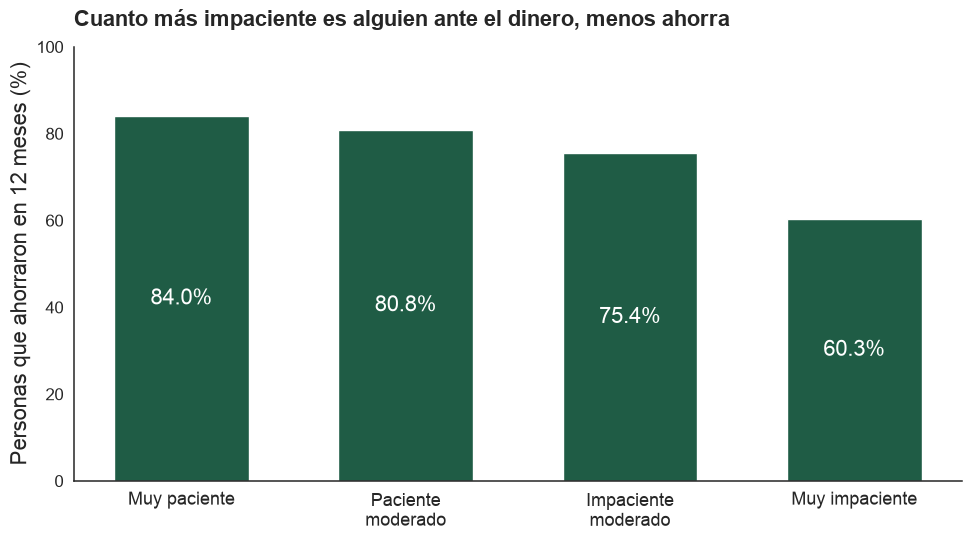


**Interpretación.** El porcentaje que ahorró en los últimos 12 meses pasa de 84.0% en «Muy paciente» a 60.3% en «Muy impaciente». La diferencia descriptiva es de 23.7 puntos porcentuales, con un patrón descendente en los cuatro niveles.

**Conclusión.** La impaciencia ante el dinero (preferir una cantidad menor hoy frente a una mayor dentro de un año) es uno de los predictores más claros del ahorro declarado.

**Implicaciones.** A diferencia de la edad o los ingresos, la impaciencia temporal es una actitud, no una restricción económica: describe cómo alguien valora el futuro frente al presente, independientemente de cuánto pueda ahorrar.

**Recomendaciones.** Diseñar mecanismos de compromiso previo (ahorro automático, bloqueo temporal de retiradas, recompensas inmediatas por objetivos de ahorro a corto plazo) pensados específicamente para perfiles impacientes, en vez de asumir que basta con más información o mejores tipos de interés.


**Cautela metodológica.** La medida proviene de una elección hipotética sobre dinero, no de una decisión real. La asociación es descriptiva: la impaciencia puede reflejar también restricciones de liquidez inmediatas, no solo una preferencia estable.

,grupo,n,porcentaje,ci_low,ci_high
2,Muy paciente,1981,84.0,82.4,85.6
3,Paciente moderado,861,80.8,78.2,83.5
0,Impaciente moderado,2369,75.4,73.7,77.2
1,Muy impaciente,2477,60.3,58.4,62.2


In [167]:
# INS-V3-01a — Ahorro según impaciencia temporal

orden_impaciencia = ["Muy paciente", "Paciente moderado", "Impaciente moderado", "Muy impaciente"]

tabla_impaciencia_ahorro = resumen_proporcion(
    df_analitico,
    df_analitico["impaciencia_temporal"].astype("string"),
    df_analitico["ahorra_12m"],
)
tabla_impaciencia_ahorro["grupo"] = pd.Categorical(tabla_impaciencia_ahorro["grupo"], orden_impaciencia, ordered=True)
tabla_impaciencia_ahorro = tabla_impaciencia_ahorro.sort_values("grupo")

fig, ax = plt.subplots(figsize=(10, 5.7))
x = np.arange(len(tabla_impaciencia_ahorro))
y = tabla_impaciencia_ahorro["porcentaje"].to_numpy()
ax.bar(x, y, color=COLOR_PRINCIPAL, width=0.6)
aplicar_etiquetas_x(ax, x, tabla_impaciencia_ahorro["grupo"], rotacion=12)
ax.set_ylim(0, min(100, max(y) + 18))
ax.set_title("Cuanto más impaciente es alguien ante el dinero, menos ahorra", loc="left", pad=15, weight="bold")
estilo_ejes(ax, ylabel="Personas que ahorraron en 12 meses (%)")
etiquetas_barras(ax)
plt.tight_layout()
plt.show()

ext = diferencia_extremos(tabla_impaciencia_ahorro, "porcentaje")
if ext:
    menor, mayor, dif = ext
    bloque_texto(
        interpretacion=(
            f"El porcentaje que ahorró en los últimos 12 meses pasa de {mayor['porcentaje']:.1f}% "
            f"en «{mayor['grupo']}» a {menor['porcentaje']:.1f}% en «{menor['grupo']}». "
            f"La diferencia descriptiva es de {dif:.1f} puntos porcentuales, con un patrón "
            "descendente en los cuatro niveles."
        ),
        conclusion=(
            "La impaciencia ante el dinero (preferir una cantidad menor hoy frente a una mayor "
            "dentro de un año) es uno de los predictores más claros del ahorro declarado."
        ),
        implicaciones=(
            "A diferencia de la edad o los ingresos, la impaciencia temporal es una actitud, no una "
            "restricción económica: describe cómo alguien valora el futuro frente al presente, "
            "independientemente de cuánto pueda ahorrar."
        ),
        recomendaciones=(
            "Diseñar mecanismos de compromiso previo (ahorro automático, bloqueo temporal de "
            "retiradas, recompensas inmediatas por objetivos de ahorro a corto plazo) pensados "
            "específicamente para perfiles impacientes, en vez de asumir que basta con más "
            "información o mejores tipos de interés."
        ),
        cautela=(
            "La medida proviene de una elección hipotética sobre dinero, no de una decisión real. "
            "La asociación es descriptiva: la impaciencia puede reflejar también restricciones de "
            "liquidez inmediatas, no solo una preferencia estable."
        ),
    )

display(tabla_impaciencia_ahorro[["grupo", "n", "porcentaje", "ci_low", "ci_high"]].round(1))

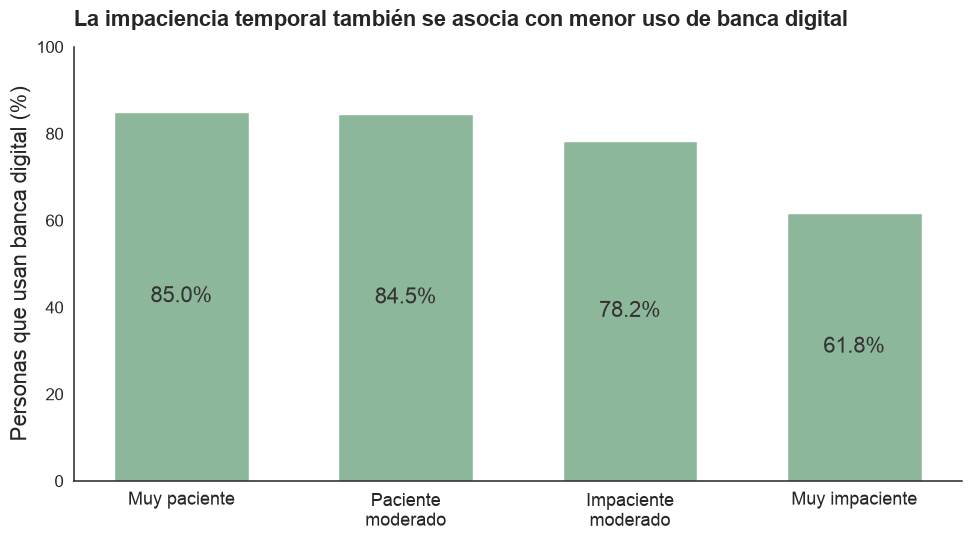


**Interpretación.** El uso de banca digital pasa de 85.0% en «Muy paciente» a 61.8% en «Muy impaciente», una diferencia de 23.2 puntos.

**Conclusión.** La impaciencia temporal no solo se asocia con menor ahorro: también describe perfiles con menor uso de banca digital y menor diversificación de productos (efecto similar, no graficado aquí para no repetir el mismo patrón tres veces).

**Implicaciones.** Es probable que la impaciencia temporal esté capturando un perfil general de menor vinculación financiera, más que un efecto específico sobre canales digitales.

**Recomendaciones.** Combinar esta señal con las de ahorro: los perfiles más impacientes son los que más se beneficiarían de automatización (para el ahorro) y de onboarding simplificado (para lo digital), precisamente porque son los que menos utilizan ambos hoy.


**Cautela metodológica.** Comparación asociativa; no se controla aquí por edad, aunque la impaciencia temporal no forma parte de ninguna fórmula de indicador y no depende de tramo_edad por diseño.

,grupo,n,porcentaje,ci_low,ci_high
2,Muy paciente,1980,85.0,83.4,86.6
3,Paciente moderado,862,84.5,82.0,86.9
0,Impaciente moderado,2369,78.2,76.6,79.9
1,Muy impaciente,2479,61.8,59.8,63.7


In [168]:
# INS-V3-01b — Uso de banca digital según impaciencia temporal

tabla_impaciencia_digital = resumen_proporcion(
    df_analitico,
    df_analitico["impaciencia_temporal"].astype("string"),
    df_analitico["usa_banca_digital"],
)
tabla_impaciencia_digital["grupo"] = pd.Categorical(tabla_impaciencia_digital["grupo"], orden_impaciencia, ordered=True)
tabla_impaciencia_digital = tabla_impaciencia_digital.sort_values("grupo")

fig, ax = plt.subplots(figsize=(10, 5.7))
x = np.arange(len(tabla_impaciencia_digital))
y = tabla_impaciencia_digital["porcentaje"].to_numpy()
ax.bar(x, y, color=COLOR_SECUNDARIO, width=0.6)
aplicar_etiquetas_x(ax, x, tabla_impaciencia_digital["grupo"], rotacion=12)
ax.set_ylim(0, min(100, max(y) + 18))
ax.set_title("La impaciencia temporal también se asocia con menor uso de banca digital", loc="left", pad=15, weight="bold")
estilo_ejes(ax, ylabel="Personas que usan banca digital (%)")
etiquetas_barras(ax)
plt.tight_layout()
plt.show()

ext = diferencia_extremos(tabla_impaciencia_digital, "porcentaje")
if ext:
    menor, mayor, dif = ext
    bloque_texto(
        interpretacion=(
            f"El uso de banca digital pasa de {mayor['porcentaje']:.1f}% en «{mayor['grupo']}» "
            f"a {menor['porcentaje']:.1f}% en «{menor['grupo']}», una diferencia de {dif:.1f} puntos."
        ),
        conclusion=(
            "La impaciencia temporal no solo se asocia con menor ahorro: también describe perfiles "
            "con menor uso de banca digital y menor diversificación de productos (efecto similar, "
            "no graficado aquí para no repetir el mismo patrón tres veces)."
        ),
        implicaciones=(
            "Es probable que la impaciencia temporal esté capturando un perfil general de menor "
            "vinculación financiera, más que un efecto específico sobre canales digitales."
        ),
        recomendaciones=(
            "Combinar esta señal con las de ahorro: los perfiles más impacientes son los que más "
            "se beneficiarían de automatización (para el ahorro) y de onboarding simplificado "
            "(para lo digital), precisamente porque son los que menos utilizan ambos hoy."
        ),
        cautela=(
            "Comparación asociativa; no se controla aquí por edad, aunque la impaciencia temporal "
            "no forma parte de ninguna fórmula de indicador y no depende de tramo_edad por diseño."
        ),
    )

display(tabla_impaciencia_digital[["grupo", "n", "porcentaje", "ci_low", "ci_high"]].round(1))

## H01/H03 — Comportamiento financiero según tramo de edad (criterio INE)

**Fuente externa: proyecciones y tramos de edad del INE (sección 7.1).**

La segmentación por edad ya forma parte del motor desde antes del descubrimiento de insights
(secciones 7.1 y 9–12), y es el predictor con mayor `score_historia` de todo el ranking para
ahorro y para banca digital. Se presenta aquí de forma nativa, junto con el cruce que comprueba
si el efecto de la banca digital sobre el ahorro se mantiene dentro de cada tramo de edad.

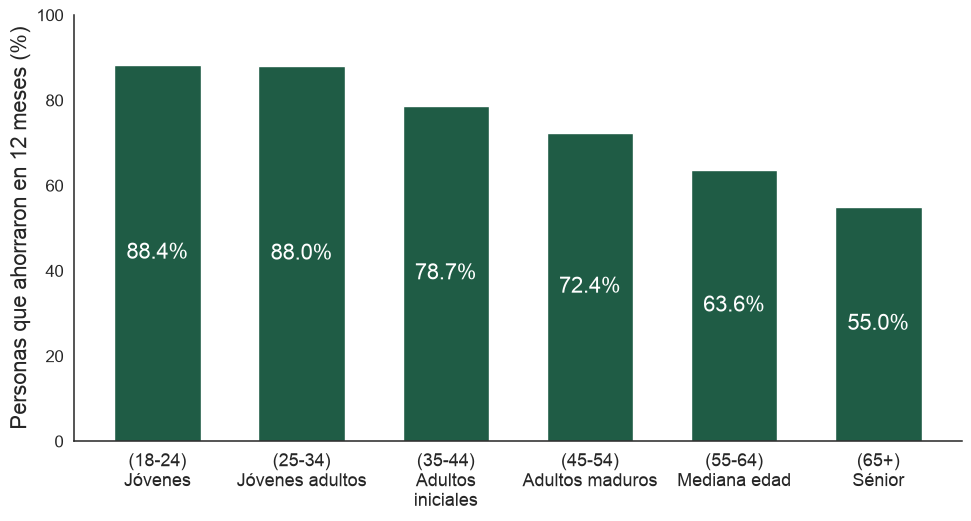


**Interpretación.** El porcentaje que ahorró pasa de 88.4% en «18-24 Jóvenes» a 55.0% en «65+ Sénior», con caída sostenida tramo a tramo (diferencia de 33.4 puntos).

**Conclusión.** La edad es uno de los factores más determinantes del ahorro declarado, con un patrón monótono decreciente que atraviesa todos los tramos de vida.

**Implicaciones.** Los perfiles jóvenes y adultos-jóvenes muestran alta propensión al ahorro pese a rentas previsiblemente menores; los tramos sénior ahorran menos, lo que puede reflejar menor capacidad de generar nuevo ahorro tras la jubilación más que falta de hábito.

**Recomendaciones.** Diseñar propuestas de ahorro distintas por etapa vital: automatización y microahorro para perfiles jóvenes, y para tramos sénior un enfoque en preservación de capital, liquidez y planificación de la desacumulación en vez de captación de nuevo ahorro.


**Cautela metodológica.** La relación es asociativa: la edad puede actuar como proxy de ingresos, situación laboral o composición del hogar.

,grupo,n,porcentaje,ci_low,ci_high
0,18-24 Jóvenes,793,88.4,86.2,90.6
1,25-34 Jóvenes adultos,1106,88.0,86.1,89.9
2,35-44 Adultos iniciales,1470,78.7,76.6,80.8
3,45-54 Adultos maduros,1796,72.4,70.4,74.5
4,55-64 Mediana edad,1434,63.6,61.1,66.1
5,65+ Sénior,1147,55.0,52.1,57.9


In [169]:
# INS-V3-02a — Ahorro en los últimos 12 meses, por tramo de edad

tabla_edad_ahorro = resumen_proporcion(df_analitico, df_analitico["tramo_edad"].astype("string"), df_analitico["ahorra_12m"])
orden_edad = list(LABELS_EDAD_INE)
tabla_edad_ahorro["grupo"] = pd.Categorical(tabla_edad_ahorro["grupo"], orden_edad, ordered=True)
tabla_edad_ahorro = tabla_edad_ahorro.sort_values("grupo")

fig, ax = plt.subplots(figsize=(10, 5.5))
x = np.arange(len(tabla_edad_ahorro))
y = tabla_edad_ahorro["porcentaje"].to_numpy()
ax.bar(x, y, color=COLOR_PRINCIPAL, width=0.6)
aplicar_etiquetas_x(ax, x, tabla_edad_ahorro["grupo"], rotacion=20)
ax.set_ylim(0, min(100, max(y) + 18))
# ax.set_title("El ahorro cae de forma sostenida con la edad", loc="left", pad=15, weight="bold")
estilo_ejes(ax, ylabel="Personas que ahorraron en 12 meses (%)")
etiquetas_barras(ax)
plt.tight_layout()
plt.show()

ext = diferencia_extremos(tabla_edad_ahorro, "porcentaje")
if ext:
    menor, mayor, dif = ext
    bloque_texto(
        interpretacion=(
            f"El porcentaje que ahorró pasa de {mayor['porcentaje']:.1f}% en «{mayor['grupo']}» "
            f"a {menor['porcentaje']:.1f}% en «{menor['grupo']}», con caída sostenida tramo a tramo "
            f"(diferencia de {dif:.1f} puntos)."
        ),
        conclusion=(
            "La edad es uno de los factores más determinantes del ahorro declarado, con un patrón "
            "monótono decreciente que atraviesa todos los tramos de vida."
        ),
        implicaciones=(
            "Los perfiles jóvenes y adultos-jóvenes muestran alta propensión al ahorro pese a rentas "
            "previsiblemente menores; los tramos sénior ahorran menos, lo que puede reflejar menor "
            "capacidad de generar nuevo ahorro tras la jubilación más que falta de hábito."
        ),
        recomendaciones=(
            "Diseñar propuestas de ahorro distintas por etapa vital: automatización y microahorro "
            "para perfiles jóvenes, y para tramos sénior un enfoque en preservación de capital, "
            "liquidez y planificación de la desacumulación en vez de captación de nuevo ahorro."
        ),
        cautela=(
            "La relación es asociativa: la edad puede actuar como proxy de ingresos, situación "
            "laboral o composición del hogar."
        ),
    )

display(tabla_edad_ahorro[["grupo", "n", "porcentaje", "ci_low", "ci_high"]].round(1))

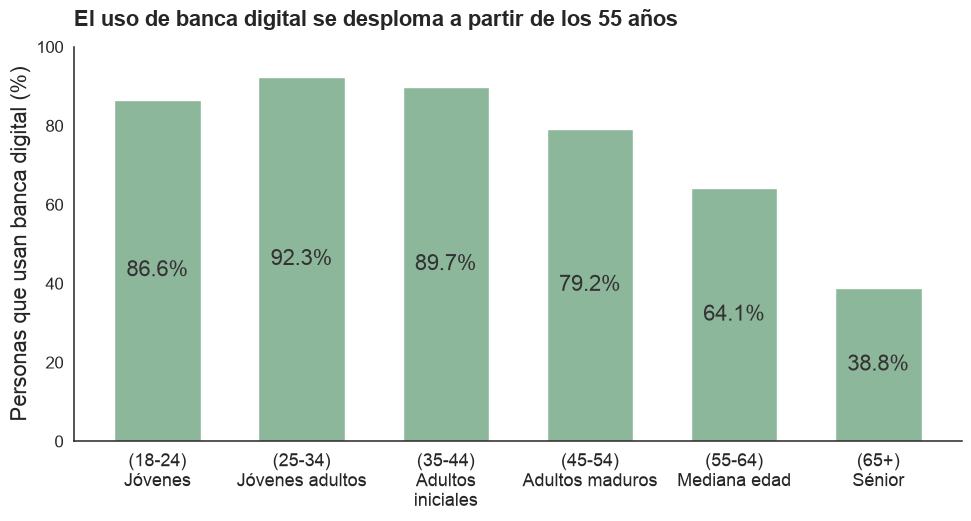


**Interpretación.** El uso de banca digital pasa de 92.3% en «25-34 Jóvenes adultos» a 38.8% en «65+ Sénior», una diferencia de 53.5 puntos, concentrada sobre todo a partir de los 55 años.

**Conclusión.** La edad es el factor con mayor score de todo el motor para explicar el uso de banca digital, por delante incluso del nivel educativo.

**Implicaciones.** Existe una brecha digital generacional clara: los tramos sénior no solo ahorran menos, sino que además tienen mucho menos contacto con los canales donde Banco Atlas podría reforzar hábitos de ahorro automatizado.

**Recomendaciones.** Mantener y reforzar un modelo híbrido (oficina + digital asistido) para los tramos de 55 años en adelante en vez de empujar una migración puramente digital.


**Cautela metodológica.** Asociativo, no causal. La brecha puede reflejar cohortes generacionales (adopción tecnológica) más que la edad biológica en sí misma.

,grupo,n,porcentaje,ci_low,ci_high
0,18-24 Jóvenes,793,86.6,84.3,89.0
1,25-34 Jóvenes adultos,1105,92.3,90.7,93.9
2,35-44 Adultos iniciales,1470,89.7,88.2,91.3
3,45-54 Adultos maduros,1798,79.2,77.3,81.1
4,55-64 Mediana edad,1435,64.1,61.6,66.6
5,65+ Sénior,1147,38.8,36.0,41.6


In [170]:
# INS-V3-02b — Uso de banca digital, por tramo de edad

tabla_edad_digital = resumen_proporcion(df_analitico, df_analitico["tramo_edad"].astype("string"), df_analitico["usa_banca_digital"])
tabla_edad_digital["grupo"] = pd.Categorical(tabla_edad_digital["grupo"], orden_edad, ordered=True)
tabla_edad_digital = tabla_edad_digital.sort_values("grupo")

fig, ax = plt.subplots(figsize=(10, 5.5))
x = np.arange(len(tabla_edad_digital))
y = tabla_edad_digital["porcentaje"].to_numpy()
ax.bar(x, y, color=COLOR_SECUNDARIO, width=0.6)
aplicar_etiquetas_x(ax, x, tabla_edad_digital["grupo"], rotacion=20)
ax.set_ylim(0, min(100, max(y) + 18))
ax.set_title("El uso de banca digital se desploma a partir de los 55 años", loc="left", pad=15, weight="bold")
estilo_ejes(ax, ylabel="Personas que usan banca digital (%)")
etiquetas_barras(ax)
plt.tight_layout()
plt.show()

ext = diferencia_extremos(tabla_edad_digital, "porcentaje")
if ext:
    menor, mayor, dif = ext
    bloque_texto(
        interpretacion=(
            f"El uso de banca digital pasa de {mayor['porcentaje']:.1f}% en «{mayor['grupo']}» a "
            f"{menor['porcentaje']:.1f}% en «{menor['grupo']}», una diferencia de {dif:.1f} puntos, "
            "concentrada sobre todo a partir de los 55 años."
        ),
        conclusion=(
            "La edad es el factor con mayor score de todo el motor para explicar el uso de banca "
            "digital, por delante incluso del nivel educativo."
        ),
        implicaciones=(
            "Existe una brecha digital generacional clara: los tramos sénior no solo ahorran menos, "
            "sino que además tienen mucho menos contacto con los canales donde Banco Atlas podría "
            "reforzar hábitos de ahorro automatizado."
        ),
        recomendaciones=(
            "Mantener y reforzar un modelo híbrido (oficina + digital asistido) para los tramos de "
            "55 años en adelante en vez de empujar una migración puramente digital."
        ),
        cautela=(
            "Asociativo, no causal. La brecha puede reflejar cohortes generacionales (adopción "
            "tecnológica) más que la edad biológica en sí misma."
        ),
    )

display(tabla_edad_digital[["grupo", "n", "porcentaje", "ci_low", "ci_high"]].round(1))

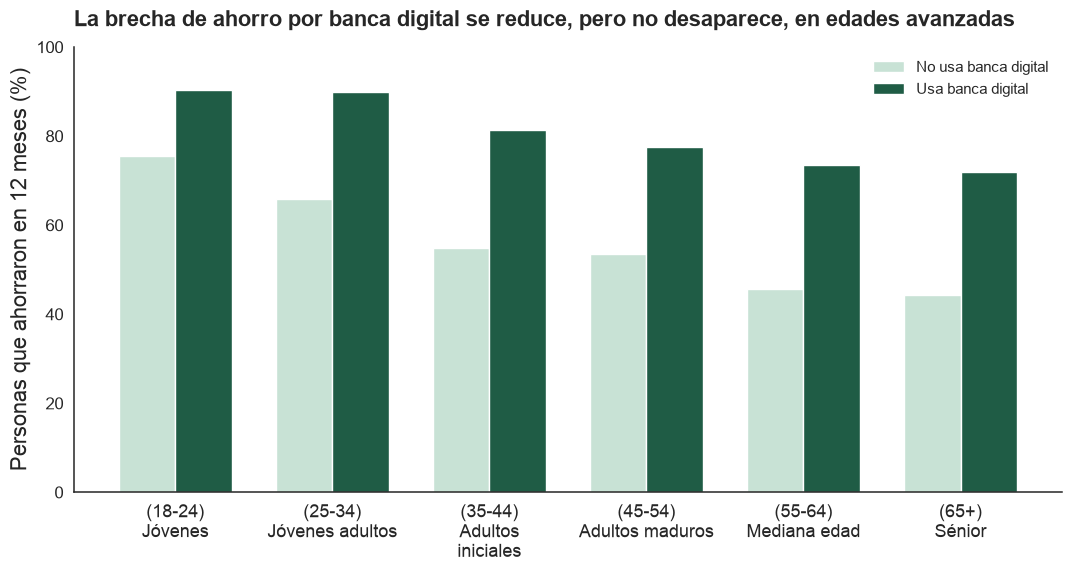


**Interpretación.** La brecha de ahorro entre quienes usan y no usan banca digital oscila entre 14.9 puntos (en «18-24 Jóvenes») y 27.8 puntos (en «55-64 Mediana edad»). Se mantiene positiva en todos los tramos.

**Conclusión.** El efecto de la banca digital sobre el ahorro no es un artefacto de que los usuarios digitales sean simplemente más jóvenes: la asociación se sostiene dentro de cada tramo de edad, aunque con distinta intensidad.

**Implicaciones.** Impulsar canales digitales entre los tramos sénior podría aportar valor incremental en ahorro, no solo alcance digital, aunque el efecto relativo sea menor que en tramos jóvenes.

**Recomendaciones.** Priorizar la migración/adopción digital asistida en los tramos de mayor brecha absoluta; usar la brecha por tramo para dimensionar el esfuerzo comercial en digitalización.


**Cautela metodológica.** Comparación asociativa y con tamaños de muestra desiguales entre celdas (ver tabla).

grupo_digital,No usa banca digital,Usa banca digital,brecha_puntos
tramo_edad,,,
18-24 Jóvenes,75.5,90.4,14.9
25-34 Jóvenes adultos,65.9,89.8,23.9
35-44 Adultos iniciales,55.0,81.4,26.5
45-54 Adultos maduros,53.5,77.5,24.0
55-64 Mediana edad,45.7,73.6,27.8
65+ Sénior,44.3,71.9,27.6


In [171]:
# INS-V3-02c — Cruce: ¿el vínculo entre banca digital y ahorro se mantiene en todos los tramos de edad?

tmp = df_analitico[["tramo_edad", "ahorra_12m", "usa_banca_digital"]].copy()
tmp["ahorra_12m"] = _binaria(tmp["ahorra_12m"])
tmp["usa_banca_digital"] = _binaria(tmp["usa_banca_digital"])
tmp = tmp.dropna()

tabla_cruce_edad_digital = (
    tmp.groupby(["tramo_edad", "usa_banca_digital"], observed=True)["ahorra_12m"]
    .agg(n="size", proporcion="mean")
    .reset_index()
)
tabla_cruce_edad_digital["porcentaje"] = tabla_cruce_edad_digital["proporcion"] * 100

fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(orden_edad))
width = 0.36
for offset, (valor, color, label) in zip(
    [-width / 2, width / 2],
    [(0.0, COLOR_NEUTRO, "No usa banca digital"), (1.0, COLOR_PRINCIPAL, "Usa banca digital")],
):
    sub = tabla_cruce_edad_digital[tabla_cruce_edad_digital["usa_banca_digital"].eq(valor)].set_index("tramo_edad").reindex(orden_edad)
    ax.bar(x + offset, sub["porcentaje"], width=width, color=color, label=label)

aplicar_etiquetas_x(ax, x, orden_edad, rotacion=20)
ax.set_ylim(0, 100)
ax.set_title("La brecha de ahorro por banca digital se reduce, pero no desaparece, en edades avanzadas",
             loc="left", pad=15, weight="bold")
estilo_ejes(ax, ylabel="Personas que ahorraron en 12 meses (%)")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

piv_edad_digital = tabla_cruce_edad_digital.copy()
piv_edad_digital["grupo_digital"] = piv_edad_digital["usa_banca_digital"].map({0.0: "No usa banca digital", 1.0: "Usa banca digital"})
piv_edad_digital = piv_edad_digital.pivot(index="tramo_edad", columns="grupo_digital", values="porcentaje").reindex(orden_edad)
piv_edad_digital["brecha_puntos"] = piv_edad_digital["Usa banca digital"] - piv_edad_digital["No usa banca digital"]
brecha_min = piv_edad_digital["brecha_puntos"].idxmin()
brecha_max = piv_edad_digital["brecha_puntos"].idxmax()

bloque_texto(
    interpretacion=(
        f"La brecha de ahorro entre quienes usan y no usan banca digital oscila entre "
        f"{piv_edad_digital['brecha_puntos'].min():.1f} puntos (en «{brecha_min}») y "
        f"{piv_edad_digital['brecha_puntos'].max():.1f} puntos (en «{brecha_max}»). Se mantiene "
        "positiva en todos los tramos."
    ),
    conclusion=(
        "El efecto de la banca digital sobre el ahorro no es un artefacto de que los usuarios "
        "digitales sean simplemente más jóvenes: la asociación se sostiene dentro de cada tramo "
        "de edad, aunque con distinta intensidad."
    ),
    implicaciones=(
        "Impulsar canales digitales entre los tramos sénior podría aportar valor incremental en "
        "ahorro, no solo alcance digital, aunque el efecto relativo sea menor que en tramos jóvenes."
    ),
    recomendaciones=(
        "Priorizar la migración/adopción digital asistida en los tramos de mayor brecha absoluta; "
        "usar la brecha por tramo para dimensionar el esfuerzo comercial en digitalización."
    ),
    cautela=(
        "Comparación asociativa y con tamaños de muestra desiguales entre celdas (ver tabla)."
    ),
)

display(piv_edad_digital.round(1))

## H03 — Canal preferido de relación con el banco, por tramo de edad

**Bloque ECF: B — Cartera y modos de obtención de información** (`b0120a-f`: *"De las siguientes,
señale las maneras en las que prefiere relacionarse con un banco"* — oficina, cajero, teléfono,
ordenador/tablet, móvil/apps).

Es una pregunta multirespuesta (una persona puede preferir varios canales a la vez), así que no
se compara "un canal por persona" sino el **porcentaje que prefiere cada canal dentro de cada
tramo de edad**. `Cajero automático` y `Otros (especificar)` se agrupan en una única serie
("Otros canales") porque, por separado, ninguno de los dos diferencia por edad de forma
relevante (`Otros` solo tiene 30 menciones en toda la muestra) y añadirlos como series propias
solo aportaría ruido visual.

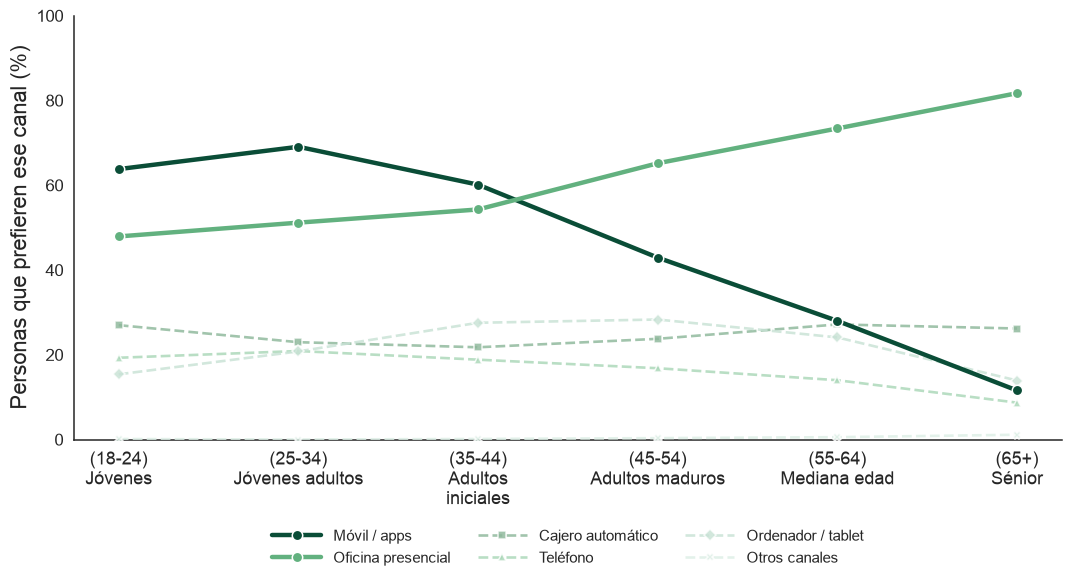


**Interpretación.** La preferencia por móvil/apps cae del 63.8% en «18-24 Jóvenes» al 11.6% en «65+ Sénior» (Cramér's V = 0.393, el efecto más grande de todo el bloque B para banca digital), mientras que la oficina presencial sube del 47.9% al 81.7% (Cramér's V = 0.237). El teléfono y el ordenador/tablet muestran gradientes más suaves; el cajero automático y 'otros' apenas varían con la edad (Cramér's V < 0.06 en ambos casos, ver tabla).

**Conclusión.** El canal preferido de relación con el banco no es uniforme: se invierte casi por completo entre los tramos jóvenes (dominados por móvil/apps) y los tramos sénior (dominados por oficina presencial), con el ordenador/tablet como canal intermedio propio de la edad adulta.

**Implicaciones.** Una misma campaña de captación —por ejemplo, de depósitos— comunicada por un único canal llegará de forma muy desigual según el tramo de edad del segmento objetivo: una campaña solo en app apenas alcanzará a los mayores de 55, y una campaña solo de oficina desaprovechará el alcance entre los menores de 45.

**Recomendaciones.** Diseñar el mix de canal por campaña según la edad del segmento objetivo: priorizar app/web para captación entre menores de 45, mantener oficina presencial y refuerzo telefónico como canal principal a partir de 55 años, y usar ordenador/tablet como canal de apoyo en las edades intermedias (45-54, donde alcanza su máximo).


**Cautela metodológica.** Es una preferencia declarada de canal general de relación con el banco, no específica de productos de ahorro/depósito; y es asociativa, no causal: la edad puede actuar aquí como proxy de alfabetización digital más que como causa directa.

,canal,n_valido,cramers_v,p_value
0,Móvil / apps,7755,0.393,3.827805e-257
1,Oficina presencial,7755,0.237,5.253066e-92
2,Ordenador / tablet,7755,0.129,2.607097e-26
3,Teléfono,7755,0.104,1.391530e-16
4,Otros canales,7755,0.058,9.589937e-05
5,Cajero automático,7755,0.048,3.332747e-03


canal,Móvil / apps,Oficina presencial,Cajero automático,Teléfono,Ordenador / tablet,Otros canales
grupo,,,,,,
18-24 Jóvenes,63.8,47.9,27.0,19.3,15.4,0.1
25-34 Jóvenes adultos,69.1,51.2,23.0,20.9,20.8,0.0
35-44 Adultos iniciales,60.1,54.3,21.8,18.8,27.6,0.1
45-54 Adultos maduros,42.9,65.2,23.8,16.8,28.3,0.3
55-64 Mediana edad,28.0,73.4,27.2,14.0,24.1,0.6
65+ Sénior,11.6,81.7,26.2,8.7,13.9,1.1


In [172]:
# INS-V3-canal — Canal preferido de relación con el banco, por tramo de edad
# Un único gráfico de líneas: un canal por serie, edad en el eje X.
#
# IMPORTANTE:
# Los colores y estilos definidos aquí son locales para este gráfico.
# No modifican la configuración global COLORS del notebook.

CANALES_RELACION = {
    "Móvil / apps": ["b0120e"],
    "Oficina presencial": ["b0120a"],
    "Cajero automático": ["b0120b"],
    "Teléfono": ["b0120c"],
    "Ordenador / tablet": ["b0120d"],
    "Otros canales": ["b0120f"],
}


# ============================================================
# 1. PREPARACIÓN DE DATOS
# ============================================================

filas_canal = []
detalle_estadistico = []

for nombre_canal, columnas in CANALES_RELACION.items():

    indicador_canal, _ = indicador_alguna_opcion(
        df_analitico,
        columnas
    )

    tabla = resumen_proporcion(
        df_analitico,
        df_analitico["tramo_edad"].astype("string"),
        indicador_canal
    )

    tabla["canal"] = nombre_canal
    filas_canal.append(tabla)

    # Tabla temporal para las pruebas estadísticas
    tmp = pd.DataFrame({
        "tramo": df_analitico["tramo_edad"],
        "v": _binaria(indicador_canal)
    }).dropna()

    tabla_contingencia = pd.crosstab(
        tmp["tramo"],
        tmp["v"]
    )

    efecto_v = cramers_v(tabla_contingencia)

    _, p_valor, _, _ = stats.chi2_contingency(
        tabla_contingencia
    )

    detalle_estadistico.append({
        "canal": nombre_canal,
        "n_valido": len(tmp),
        "cramers_v": round(efecto_v, 3),
        "p_value": p_valor,
    })


tabla_canal_edad = pd.concat(
    filas_canal,
    ignore_index=True
)

orden_edad_canal = list(LABELS_EDAD_INE)

tabla_canal_edad["grupo"] = pd.Categorical(
    tabla_canal_edad["grupo"],
    categories=orden_edad_canal,
    ordered=True
)

tabla_canal_edad = tabla_canal_edad.sort_values(
    ["canal", "grupo"]
)

orden_canales = list(CANALES_RELACION)


# ============================================================
# 2. CONFIGURACIÓN VISUAL LOCAL
# ============================================================

# Primero se recuperan los colores globales para los canales
# que deben conservar su color habitual.
colores_globales_canal = dict(
    zip(
        orden_canales,
        COLORS[:len(orden_canales)]
    )
)

# Paleta local exclusiva para este gráfico.
# Los cuatro canales secundarios mantienen el color global.
colores_canal = {
    "Móvil / apps": "#0A4D37",                  # Verde muy oscuro
    "Oficina presencial": "#62B17F",            # Verde más claro
    "Cajero automático": colores_globales_canal["Cajero automático"],
    "Teléfono": colores_globales_canal["Teléfono"],
    "Ordenador / tablet": colores_globales_canal["Ordenador / tablet"],
    "Otros canales": colores_globales_canal["Otros canales"],
}

# Estilos de línea locales.
# Los dos canales principales permanecen continuos.
# Los canales secundarios se representan con línea discontinua.
estilos_linea_canal = {
    "Móvil / apps": "-",
    "Oficina presencial": "-",
    "Cajero automático": "--",
    "Teléfono": "--",
    "Ordenador / tablet": "--",
    "Otros canales": "--",
}

# Mayor grosor para las dos relaciones principales.
grosores_linea_canal = {
    "Móvil / apps": 3.2,
    "Oficina presencial": 3.2,
    "Cajero automático": 1.9,
    "Teléfono": 1.9,
    "Ordenador / tablet": 1.9,
    "Otros canales": 1.9,
}

# Marcadores diferenciados para facilitar la lectura,
# especialmente cuando las líneas se cruzan.
marcadores_canal = {
    "Móvil / apps": "o",
    "Oficina presencial": "o",
    "Cajero automático": "s",
    "Teléfono": "^",
    "Ordenador / tablet": "D",
    "Otros canales": "X",
}

# Los canales principales aparecen por encima del resto.
zorder_canal = {
    "Móvil / apps": 5,
    "Oficina presencial": 5,
    "Cajero automático": 3,
    "Teléfono": 3,
    "Ordenador / tablet": 3,
    "Otros canales": 3,
}


# ============================================================
# 3. GRÁFICO
# ============================================================

fig, ax = plt.subplots(figsize=(11, 6.2))

x = np.arange(len(orden_edad_canal))

for canal in orden_canales:

    serie = (
        tabla_canal_edad[
            tabla_canal_edad["canal"].eq(canal)
        ]
        .set_index("grupo")
        .reindex(orden_edad_canal)
    )

    es_canal_principal = canal in {
        "Móvil / apps",
        "Oficina presencial"
    }

    ax.plot(
        x,
        serie["porcentaje"],
        label=canal,
        color=colores_canal[canal],
        linestyle=estilos_linea_canal[canal],
        linewidth=grosores_linea_canal[canal],
        marker=marcadores_canal[canal],
        markersize=7.5 if es_canal_principal else 6,
        markerfacecolor=colores_canal[canal],
        markeredgecolor="white",
        markeredgewidth=1.1,
        alpha=1.0 if es_canal_principal else 0.82,
        zorder=zorder_canal[canal],
    )


# ============================================================
# 4. FORMATO
# ============================================================

aplicar_etiquetas_x(
    ax,
    x,
    orden_edad_canal,
    rotacion=20
)

ax.set_ylim(0, 100)

# ax.set_title(
#     "El canal preferido para relacionarse con el banco cambia radicalmente con la edad",
#     loc="left",
#     pad=15,
#     weight="bold"
# )

estilo_ejes(
    ax,
    ylabel="Personas que prefieren ese canal (%)"
)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.18),
    ncol=3,
    frameon=False,
    handlelength=3.2,
    columnspacing=1.8
)

plt.tight_layout()
plt.show()


# ============================================================
# 5. TABLA ESTADÍSTICA
# ============================================================

tabla_estadistico_canal = (
    pd.DataFrame(detalle_estadistico)
    .sort_values(
        "cramers_v",
        ascending=False
    )
)


# ============================================================
# 6. VARIABLES PARA LA INTERPRETACIÓN
# ============================================================

fila_app = (
    tabla_canal_edad[
        tabla_canal_edad["canal"].eq("Móvil / apps")
    ]
    .set_index("grupo")
)

fila_oficina = (
    tabla_canal_edad[
        tabla_canal_edad["canal"].eq("Oficina presencial")
    ]
    .set_index("grupo")
)

v_app = tabla_estadistico_canal.loc[
    tabla_estadistico_canal["canal"].eq("Móvil / apps"),
    "cramers_v"
].iloc[0]

v_oficina = tabla_estadistico_canal.loc[
    tabla_estadistico_canal["canal"].eq("Oficina presencial"),
    "cramers_v"
].iloc[0]


# ============================================================
# 7. INTERPRETACIÓN Y CONCLUSIONES
# ============================================================

bloque_texto(
    interpretacion=(
        f"La preferencia por móvil/apps cae del "
        f"{fila_app.loc[orden_edad_canal[0], 'porcentaje']:.1f}% "
        f"en «{orden_edad_canal[0]}» al "
        f"{fila_app.loc[orden_edad_canal[-1], 'porcentaje']:.1f}% "
        f"en «{orden_edad_canal[-1]}» "
        f"(Cramér's V = {v_app:.3f}, el efecto más grande de todo el bloque B "
        "para banca digital), mientras que la oficina presencial sube del "
        f"{fila_oficina.loc[orden_edad_canal[0], 'porcentaje']:.1f}% al "
        f"{fila_oficina.loc[orden_edad_canal[-1], 'porcentaje']:.1f}% "
        f"(Cramér's V = {v_oficina:.3f}). "
        "El teléfono y el ordenador/tablet muestran gradientes más suaves; "
        "el cajero automático y 'otros' apenas varían con la edad "
        "(Cramér's V < 0.06 en ambos casos, ver tabla)."
    ),

    conclusion=(
        "El canal preferido de relación con el banco no es uniforme: "
        "se invierte casi por completo entre los tramos jóvenes "
        "(dominados por móvil/apps) y los tramos sénior "
        "(dominados por oficina presencial), con el ordenador/tablet "
        "como canal intermedio propio de la edad adulta."
    ),

    implicaciones=(
        "Una misma campaña de captación —por ejemplo, de depósitos— "
        "comunicada por un único canal llegará de forma muy desigual "
        "según el tramo de edad del segmento objetivo: una campaña solo "
        "en app apenas alcanzará a los mayores de 55, y una campaña solo "
        "de oficina desaprovechará el alcance entre los menores de 45."
    ),

    recomendaciones=(
        "Diseñar el mix de canal por campaña según la edad del segmento "
        "objetivo: priorizar app/web para captación entre menores de 45, "
        "mantener oficina presencial y refuerzo telefónico como canal "
        "principal a partir de 55 años, y usar ordenador/tablet como canal "
        "de apoyo en las edades intermedias "
        "(45-54, donde alcanza su máximo)."
    ),

    cautela=(
        "Es una preferencia declarada de canal general de relación con "
        "el banco, no específica de productos de ahorro/depósito; y es "
        "asociativa, no causal: la edad puede actuar aquí como proxy de "
        "alfabetización digital más que como causa directa."
    ),
)


# ============================================================
# 8. TABLAS DE APOYO
# ============================================================

display(
    tabla_estadistico_canal.reset_index(drop=True)
)

display(
    tabla_canal_edad
    .pivot(
        index="grupo",
        columns="canal",
        values="porcentaje"
    )[orden_canales]
    .round(1)
)

## H03 — Uso de apps de control de gastos y banca digital

**Bloque ECF: J — Gasto y fragilidad financiera.**

`usa_app_gastos` (`j0110`) recoge si el hogar usa una app bancaria o herramienta de gestión de
dinero para seguir sus gastos. No formaba parte de ningún indicador hasta esta versión, y resulta
uno de los predictores más fuertes de banca digital dentro de los bloques revisados.

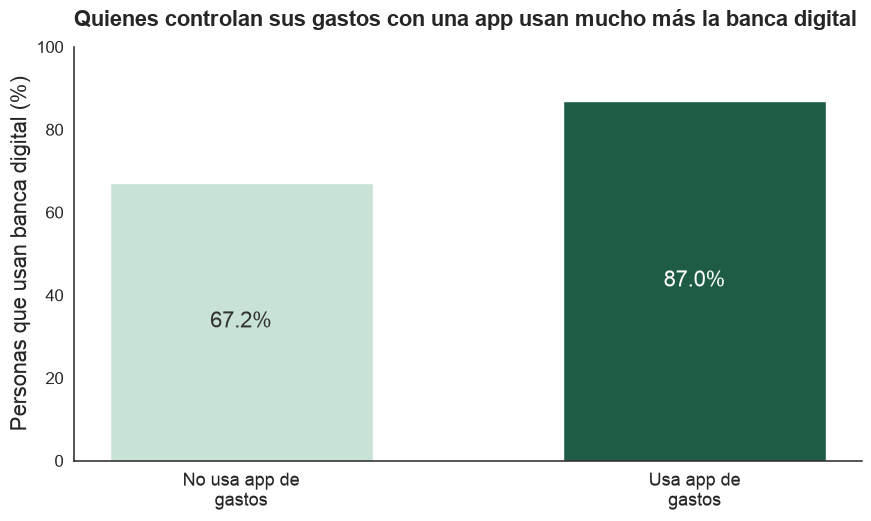


**Interpretación.** El uso de banca digital pasa de 67.2% en «No usa app de gastos» a 87.0% en «Usa app de gastos», una diferencia de 19.8 puntos.

**Conclusión.** El control activo de gastos mediante una app es uno de los comportamientos más estrechamente ligados al uso de banca digital dentro de los bloques revisados.

**Implicaciones.** Es probable que ambas conductas compartan un mismo perfil de cliente digitalmente activo; no obstante, la app de control de gastos es en sí misma una funcionalidad que Banco Atlas puede ofrecer y promocionar directamente.

**Recomendaciones.** Incluir o destacar herramientas de categorización y seguimiento de gastos dentro de la app bancaria como puerta de entrada a la digitalización, en vez de tratarlas como una función secundaria.


**Cautela metodológica.** Asociación fuerte pero no causal: ambas variables pueden reforzarse mutuamente (usar la app de gastos facilita el uso de banca digital, y viceversa).

,grupo,n,porcentaje,ci_low,ci_high
0,No usa app de gastos,4697,67.2,65.9,68.6
1,Usa app de gastos,3056,87.0,85.8,88.2


In [173]:
# INS-V3-03 — Banca digital según uso de apps de control de gastos

tmp = pd.DataFrame({
    "Usa banca digital": _binaria(df_analitico["usa_banca_digital"]),
    "Usa app de gastos": _binaria(df_analitico["usa_app_gastos"]),
}).dropna()

grupo_app = tmp["Usa app de gastos"].map({0.0: "No usa app de gastos", 1.0: "Usa app de gastos"})
tabla_app_digital = resumen_proporcion(tmp, grupo_app, tmp["Usa banca digital"])
orden_app = ["No usa app de gastos", "Usa app de gastos"]
tabla_app_digital["grupo"] = pd.Categorical(tabla_app_digital["grupo"], orden_app, ordered=True)
tabla_app_digital = tabla_app_digital.sort_values("grupo")

fig, ax = plt.subplots(figsize=(9, 5.5))
x = np.arange(len(tabla_app_digital))
y = tabla_app_digital["porcentaje"].to_numpy()
ax.bar(x, y, color=[COLOR_NEUTRO, COLOR_PRINCIPAL], width=0.58)
aplicar_etiquetas_x(ax, x, tabla_app_digital["grupo"])
ax.set_ylim(0, min(100, max(y) + 18))
ax.set_title("Quienes controlan sus gastos con una app usan mucho más la banca digital", loc="left", pad=15, weight="bold")
estilo_ejes(ax, ylabel="Personas que usan banca digital (%)")
etiquetas_barras(ax)
plt.tight_layout()
plt.show()

ext = diferencia_extremos(tabla_app_digital, "porcentaje")
if ext:
    menor, mayor, dif = ext
    bloque_texto(
        interpretacion=(
            f"El uso de banca digital pasa de {menor['porcentaje']:.1f}% en «{menor['grupo']}» a "
            f"{mayor['porcentaje']:.1f}% en «{mayor['grupo']}», una diferencia de {dif:.1f} puntos."
        ),
        conclusion=(
            "El control activo de gastos mediante una app es uno de los comportamientos más "
            "estrechamente ligados al uso de banca digital dentro de los bloques revisados."
        ),
        implicaciones=(
            "Es probable que ambas conductas compartan un mismo perfil de cliente digitalmente "
            "activo; no obstante, la app de control de gastos es en sí misma una funcionalidad que "
            "Banco Atlas puede ofrecer y promocionar directamente."
        ),
        recomendaciones=(
            "Incluir o destacar herramientas de categorización y seguimiento de gastos dentro de la "
            "app bancaria como puerta de entrada a la digitalización, en vez de tratarlas como una "
            "función secundaria."
        ),
        cautela=(
            "Asociación fuerte pero no causal: ambas variables pueden reforzarse mutuamente (usar la "
            "app de gastos facilita el uso de banca digital, y viceversa)."
        ),
    )

display(tabla_app_digital[["grupo", "n", "porcentaje", "ci_low", "ci_high"]].round(1))

## H02 — Colchón de liquidez y fragilidad financiera (índice corregido)

**Bloque ECF: J — Gasto y fragilidad financiera.**

`j0400` (meses que el hogar podría cubrir sus gastos corrientes sin ingresos) se cruza aquí con
`score_fragilidad_financiera` ya corregido (sección 19). Es el predictor con mayor efecto de toda
la historia H02 tras la corrección.

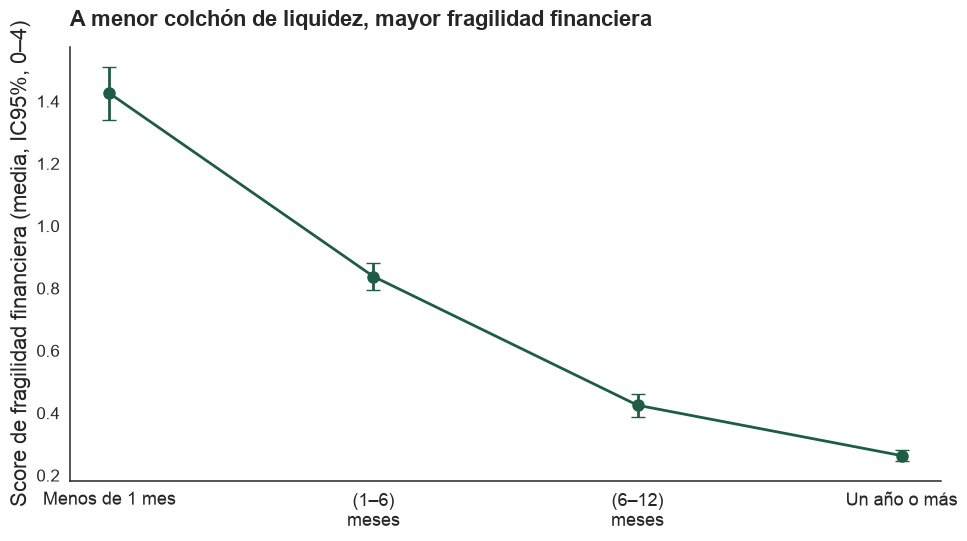


**Interpretación.** La fragilidad financiera media pasa de 1.43 en «Menos de 1 mes» a 0.26 en «Un año o más», una diferencia de 1.16 puntos sobre una escala de 0 a 4.

**Conclusión.** El colchón de liquidez declarado es, tras la corrección del índice, uno de los predictores más fuertes y coherentes de la fragilidad financiera.

**Implicaciones.** A diferencia de otros componentes de fragilidad (que registran problemas ya ocurridos), el colchón de liquidez es una medida de resiliencia ANTES de que ocurra un problema: permite anticipar riesgo, no solo detectarlo después.

**Recomendaciones.** Usar el colchón de liquidez declarado (o una proxy transaccional equivalente) como señal temprana para ofrecer fondos de emergencia o líneas de crédito preventivas antes de que se materialice un impago o una restricción de crédito.


**Cautela metodológica.** La dirección de causalidad no está identificada: tener menor colchón puede ser causa y consecuencia de la fragilidad financiera general del hogar.

,grupo,n,media,ci_low,ci_high
2,Menos de 1 mes,768,1.43,1.34,1.51
0,1–6 meses,2030,0.84,0.8,0.88
1,6–12 meses,1522,0.43,0.39,0.46
3,Un año o más,3268,0.26,0.25,0.28


In [174]:
# INS-V3-04 — Fragilidad financiera media según colchón de liquidez

MAPA_COLCHON = {
    "a": "Menos de 1 mes", "b": "Menos de 1 mes",
    "c": "1–6 meses", "d": "1–6 meses",
    "e": "6–12 meses", "f": "6–12 meses",
    "g": "Un año o más",
}
orden_colchon = ["Menos de 1 mes", "1–6 meses", "6–12 meses", "Un año o más"]

letra_j0400 = df_analitico["j0400"].astype("string").str.strip().str.slice(0, 1).str.lower()
grupo_colchon = letra_j0400.map(MAPA_COLCHON)

tabla_colchon_fragilidad = resumen_media(df_analitico, grupo_colchon, df_analitico["score_fragilidad_financiera"])
tabla_colchon_fragilidad["grupo"] = pd.Categorical(tabla_colchon_fragilidad["grupo"], orden_colchon, ordered=True)
tabla_colchon_fragilidad = tabla_colchon_fragilidad.sort_values("grupo")

fig, ax = plt.subplots(figsize=(10, 5.7))
x = np.arange(len(tabla_colchon_fragilidad))
ax.errorbar(
    x, tabla_colchon_fragilidad["media"],
    yerr=[
        tabla_colchon_fragilidad["media"] - tabla_colchon_fragilidad["ci_low"],
        tabla_colchon_fragilidad["ci_high"] - tabla_colchon_fragilidad["media"],
    ],
    fmt="o-", color=COLOR_PRINCIPAL, capsize=5, linewidth=2, markersize=8,
)
aplicar_etiquetas_x(ax, x, tabla_colchon_fragilidad["grupo"])
ax.set_title("A menor colchón de liquidez, mayor fragilidad financiera", loc="left", pad=15, weight="bold")
estilo_ejes(ax, ylabel="Score de fragilidad financiera (media, IC95%, 0–4)")
plt.tight_layout()
plt.show()

ext = diferencia_extremos(tabla_colchon_fragilidad, "media")
if ext:
    menor, mayor, dif = ext
    bloque_texto(
        interpretacion=(
            f"La fragilidad financiera media pasa de {mayor['media']:.2f} en «{mayor['grupo']}» a "
            f"{menor['media']:.2f} en «{menor['grupo']}», una diferencia de {dif:.2f} puntos "
            "sobre una escala de 0 a 4."
        ),
        conclusion=(
            "El colchón de liquidez declarado es, tras la corrección del índice, uno de los "
            "predictores más fuertes y coherentes de la fragilidad financiera."
        ),
        implicaciones=(
            "A diferencia de otros componentes de fragilidad (que registran problemas ya ocurridos), "
            "el colchón de liquidez es una medida de resiliencia ANTES de que ocurra un problema: "
            "permite anticipar riesgo, no solo detectarlo después."
        ),
        recomendaciones=(
            "Usar el colchón de liquidez declarado (o una proxy transaccional equivalente) como "
            "señal temprana para ofrecer fondos de emergencia o líneas de crédito preventivas antes "
            "de que se materialice un impago o una restricción de crédito."
        ),
        cautela=(
            "La dirección de causalidad no está identificada: tener menor colchón puede ser causa y "
            "consecuencia de la fragilidad financiera general del hogar."
        ),
    )

display(tabla_colchon_fragilidad[["grupo", "n", "media", "ci_low", "ci_high"]].round(2))

## H02 — Percepción de estrechez financiera y planificación de gastos

**Bloque ECF: D (actitudes) y J (gasto y fragilidad).**

`d0109` ("mi situación financiera limita mis posibilidades de hacer cosas que considero
importantes") es una medida subjetiva y barata de recoger. Se contrasta aquí con la fragilidad
financiera ya corregida, y se añade una lectura complementaria sobre `hace_planificacion_gastos`
que conviene explicar con cautela.

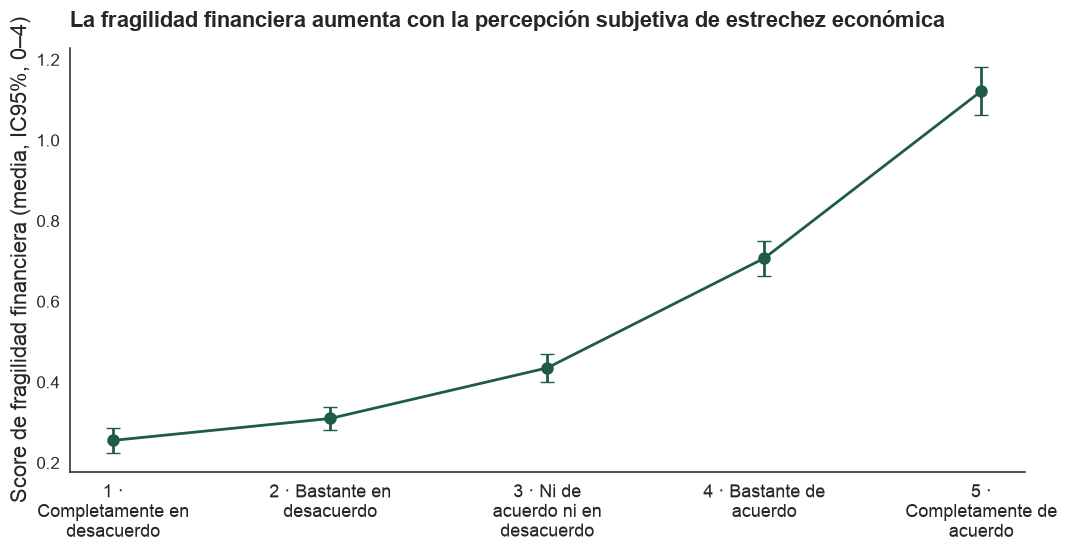


**Interpretación.** La fragilidad financiera media pasa de 0.26 en «1 · Completamente en desacuerdo» a 1.12 en «5 · Completamente de acuerdo», una diferencia de 0.87 puntos.

**Conclusión.** La percepción subjetiva de estrechez económica se corresponde con niveles objetivamente más altos de fragilidad financiera medida.

**Implicaciones.** La autopercepción no es solo una opinión: coincide con el índice objetivo de fragilidad, construido a partir de déficit, impago, pérdida de empleo y restricción de crédito.

**Recomendaciones.** Una pregunta breve de autopercepción financiera puede usarse como señal temprana y de bajo coste para activar acompañamiento preventivo, complementando los indicadores objetivos de fragilidad.


**Cautela metodológica.** d0109 es conceptualmente cercano a `score_preocupacion_financiera`; no debe presentarse como un hallazgo totalmente independiente de la actitud financiera general.

,grupo,n,media,ci_low,ci_high
0,1 · Completamente en desacuerdo,1303,0.26,0.22,0.29
1,2 · Bastante en desacuerdo,1678,0.31,0.28,0.34
2,3 · Ni de acuerdo ni en desacuerdo,1610,0.44,0.4,0.47
3,4 · Bastante de acuerdo,1733,0.71,0.66,0.75
4,5 · Completamente de acuerdo,1392,1.12,1.06,1.18


In [175]:
# INS-V3-05a — Fragilidad financiera media según percepción de estrechez (d0109)

etiquetas_d0109 = {
    "1-completamente en desacuerdo": "1 · Completamente en desacuerdo",
    "2-bastante en desacuerdo": "2 · Bastante en desacuerdo",
    "3-ni de acuerdo ni en desacuerdo": "3 · Ni de acuerdo ni en desacuerdo",
    "4-bastante de acuerdo": "4 · Bastante de acuerdo",
    "5-completamente de acuerdo": "5 · Completamente de acuerdo",
}
orden_d0109 = list(etiquetas_d0109.values())

texto_d0109 = df_analitico["d0109"].astype("string").str.strip().str.lower()
grupo_d0109 = texto_d0109.map(etiquetas_d0109)

tabla_estrechez_fragilidad = resumen_media(df_analitico, grupo_d0109, df_analitico["score_fragilidad_financiera"])
tabla_estrechez_fragilidad["grupo"] = pd.Categorical(tabla_estrechez_fragilidad["grupo"], orden_d0109, ordered=True)
tabla_estrechez_fragilidad = tabla_estrechez_fragilidad.sort_values("grupo")

fig, ax = plt.subplots(figsize=(11, 5.8))
x = np.arange(len(tabla_estrechez_fragilidad))
ax.errorbar(
    x, tabla_estrechez_fragilidad["media"],
    yerr=[
        tabla_estrechez_fragilidad["media"] - tabla_estrechez_fragilidad["ci_low"],
        tabla_estrechez_fragilidad["ci_high"] - tabla_estrechez_fragilidad["media"],
    ],
    fmt="o-", color=COLOR_PRINCIPAL, capsize=5, linewidth=2, markersize=8,
)
aplicar_etiquetas_x(ax, x, tabla_estrechez_fragilidad["grupo"], rotacion=20)
ax.set_title("La fragilidad financiera aumenta con la percepción subjetiva de estrechez económica", loc="left", pad=15, weight="bold")
estilo_ejes(ax, ylabel="Score de fragilidad financiera (media, IC95%, 0–4)")
plt.tight_layout()
plt.show()

ext = diferencia_extremos(tabla_estrechez_fragilidad, "media")
if ext:
    menor, mayor, dif = ext
    bloque_texto(
        interpretacion=(
            f"La fragilidad financiera media pasa de {menor['media']:.2f} en «{menor['grupo']}» a "
            f"{mayor['media']:.2f} en «{mayor['grupo']}», una diferencia de {dif:.2f} puntos."
        ),
        conclusion=(
            "La percepción subjetiva de estrechez económica se corresponde con niveles "
            "objetivamente más altos de fragilidad financiera medida."
        ),
        implicaciones=(
            "La autopercepción no es solo una opinión: coincide con el índice objetivo de "
            "fragilidad, construido a partir de déficit, impago, pérdida de empleo y restricción "
            "de crédito."
        ),
        recomendaciones=(
            "Una pregunta breve de autopercepción financiera puede usarse como señal temprana y de "
            "bajo coste para activar acompañamiento preventivo, complementando los indicadores "
            "objetivos de fragilidad."
        ),
        cautela=(
            "d0109 es conceptualmente cercano a `score_preocupacion_financiera`; no debe "
            "presentarse como un hallazgo totalmente independiente de la actitud financiera general."
        ),
    )

display(tabla_estrechez_fragilidad[["grupo", "n", "media", "ci_low", "ci_high"]].round(2))

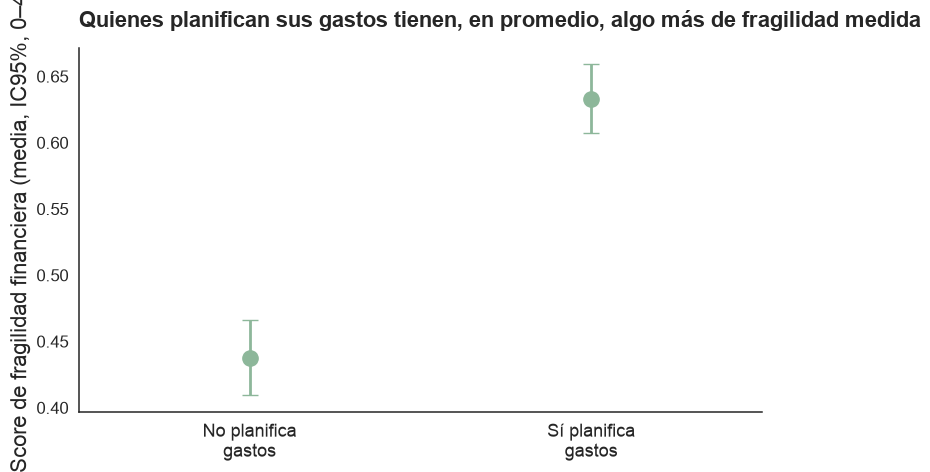


**Interpretación.** La fragilidad media es 0.63 entre quienes planifican sus gastos, frente a 0.44 entre quienes no lo hacen.

**Conclusión.** Planificar los gastos del hogar se asocia con una fragilidad ALGO más alta, no más baja, incluso después de retirar esta variable de la fórmula del índice (sección 19).

**Implicaciones.** Este resultado, aparentemente contraintuitivo, es coherente con un patrón conocido: la necesidad de planificar surge más de la escasez que de la abundancia. Los hogares con menos margen tienden a controlar más de cerca cada euro; los que tienen mucho margen pueden permitirse no planificar.

**Recomendaciones.** No usar la planificación de gastos como señal de bajo riesgo por sí sola. Sí tiene valor como punto de contacto: los hogares que ya planifican son un público natural para herramientas de presupuesto y alertas dentro de la app bancaria.


**Cautela metodológica.** La dirección de causalidad es ambigua y probablemente inversa a la intuición inicial: la fragilidad puede motivar la planificación, más que la planificación causar fragilidad. No se recomienda comunicar este hallazgo sin esta matización.

,grupo,n,media,ci_low,ci_high
0,No planifica gastos,2878,0.44,0.41,0.47
1,Sí planifica gastos,4882,0.63,0.61,0.66


In [176]:
# INS-V3-05b — Nota complementaria: planificación de gastos y fragilidad

tabla_planificacion_fragilidad = resumen_media(
    df_analitico,
    df_analitico["hace_planificacion_gastos"].map({0.0: "No planifica gastos", 1.0: "Sí planifica gastos"}),
    df_analitico["score_fragilidad_financiera"],
)

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(tabla_planificacion_fragilidad))
ax.errorbar(
    x, tabla_planificacion_fragilidad["media"],
    yerr=[
        tabla_planificacion_fragilidad["media"] - tabla_planificacion_fragilidad["ci_low"],
        tabla_planificacion_fragilidad["ci_high"] - tabla_planificacion_fragilidad["media"],
    ],
    fmt="o", markersize=11, capsize=6, linewidth=2, color=COLOR_SECUNDARIO,
)
aplicar_etiquetas_x(ax, x, tabla_planificacion_fragilidad["grupo"])
ax.set_xlim(-0.5, len(tabla_planificacion_fragilidad) - 0.5)
ax.set_title("Quienes planifican sus gastos tienen, en promedio, algo más de fragilidad medida", loc="left", pad=15, weight="bold")
estilo_ejes(ax, ylabel="Score de fragilidad financiera (media, IC95%, 0–4)")
plt.tight_layout()
plt.show()

bloque_texto(
    interpretacion=(
        f"La fragilidad media es {tabla_planificacion_fragilidad.loc[tabla_planificacion_fragilidad['grupo'].eq('Sí planifica gastos'), 'media'].iloc[0]:.2f} "
        "entre quienes planifican sus gastos, frente a "
        f"{tabla_planificacion_fragilidad.loc[tabla_planificacion_fragilidad['grupo'].eq('No planifica gastos'), 'media'].iloc[0]:.2f} "
        "entre quienes no lo hacen."
    ),
    conclusion=(
        "Planificar los gastos del hogar se asocia con una fragilidad ALGO más alta, no más baja, "
        "incluso después de retirar esta variable de la fórmula del índice (sección 19)."
    ),
    implicaciones=(
        "Este resultado, aparentemente contraintuitivo, es coherente con un patrón conocido: la "
        "necesidad de planificar surge más de la escasez que de la abundancia. Los hogares con "
        "menos margen tienden a controlar más de cerca cada euro; los que tienen mucho margen "
        "pueden permitirse no planificar."
    ),
    recomendaciones=(
        "No usar la planificación de gastos como señal de bajo riesgo por sí sola. Sí tiene valor "
        "como punto de contacto: los hogares que ya planifican son un público natural para "
        "herramientas de presupuesto y alertas dentro de la app bancaria."
    ),
    cautela=(
        "La dirección de causalidad es ambigua y probablemente inversa a la intuición inicial: la "
        "fragilidad puede motivar la planificación, más que la planificación causar fragilidad. "
        "No se recomienda comunicar este hallazgo sin esta matización."
    ),
)

display(tabla_planificacion_fragilidad[["grupo", "n", "media", "ci_low", "ci_high"]].round(2))

## H04 — Rol de decisión en el hogar y diversificación de productos

**Bloque ECF: F — Toma de decisiones en el hogar.**

`rol_decision_patrimonio` distingue si la persona muestral no participa, decide de forma
compartida, o decide en solitario sobre las propiedades, productos y deudas del hogar en su
conjunto. Solo aplica a hogares de más de un miembro.

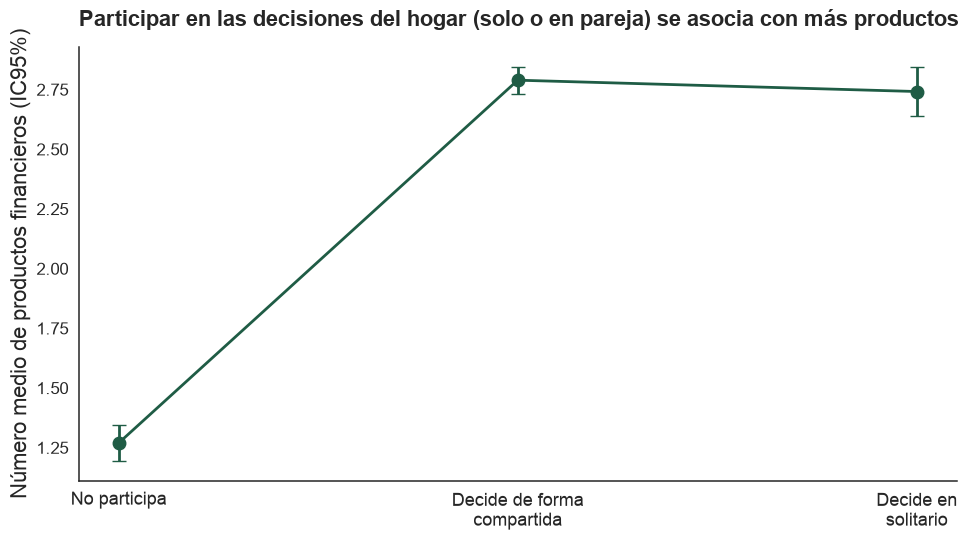


**Interpretación.** El número medio de productos financieros es 1.27 entre quienes «No participa» en las decisiones patrimoniales, frente a 2.79 entre quienes deciden «de forma compartida» y 2.74 entre quienes «deciden en solitario» — estas dos últimas prácticamente empatadas.

**Conclusión.** Lo que marca la diferencia no es decidir en solitario frente a decidir en pareja/familia (ambos grupos son casi idénticos), sino participar o no participar en absoluto en las decisiones patrimoniales del hogar.

**Implicaciones.** Quien no participa en estas decisiones es, para Banco Atlas, un perfil con menor visibilidad y probablemente menor capacidad de decisión directa sobre productos, aunque conviva con alguien que sí tiene una relación financiera amplia.

**Recomendaciones.** En hogares multi-persona, dirigir la comunicación comercial y las decisiones de contratación hacia cualquiera de quienes participan en la decisión (solos o en pareja); para el perfil que no participa, priorizar contenidos de educación e inclusión financiera antes que ofertas de producto directas.


**Cautela metodológica.** Esta variable solo aplica a hogares de más de un miembro (cobertura ~88%); no es aplicable a hogares unipersonales. La asociación es descriptiva, no causal.

,grupo,n,media,ci_low,ci_high
2,No participa,1212,1.27,1.19,1.35
0,Decide de forma compartida,4285,2.79,2.73,2.85
1,Decide en solitario,1306,2.74,2.64,2.85


In [177]:
# INS-V3-06 — Nº medio de productos financieros según rol de decisión sobre el patrimonio del hogar

orden_rol = ["No participa", "Decide de forma compartida", "Decide en solitario"]

tabla_rol_productos = resumen_media(
    df_analitico,
    df_analitico["rol_decision_patrimonio"].astype("string"),
    df_analitico["n_productos_financieros"],
)
tabla_rol_productos["grupo"] = pd.Categorical(tabla_rol_productos["grupo"], orden_rol, ordered=True)
tabla_rol_productos = tabla_rol_productos.sort_values("grupo")

fig, ax = plt.subplots(figsize=(10, 5.7))
x = np.arange(len(tabla_rol_productos))
ax.errorbar(
    x, tabla_rol_productos["media"],
    yerr=[
        tabla_rol_productos["media"] - tabla_rol_productos["ci_low"],
        tabla_rol_productos["ci_high"] - tabla_rol_productos["media"],
    ],
    fmt="o-", color=COLOR_PRINCIPAL, capsize=5, linewidth=2, markersize=9,
)
aplicar_etiquetas_x(ax, x, tabla_rol_productos["grupo"], rotacion=10)
ax.set_title("Participar en las decisiones del hogar (solo o en pareja) se asocia con más productos", loc="left", pad=15, weight="bold")
estilo_ejes(ax, ylabel="Número medio de productos financieros (IC95%)")
plt.tight_layout()
plt.show()

fila_no_participa = tabla_rol_productos.loc[tabla_rol_productos["grupo"].eq("No participa")].iloc[0]
fila_compartida = tabla_rol_productos.loc[tabla_rol_productos["grupo"].eq("Decide de forma compartida")].iloc[0]
fila_solitario = tabla_rol_productos.loc[tabla_rol_productos["grupo"].eq("Decide en solitario")].iloc[0]

bloque_texto(
    interpretacion=(
        f"El número medio de productos financieros es {fila_no_participa['media']:.2f} entre quienes "
        f"«No participa» en las decisiones patrimoniales, frente a {fila_compartida['media']:.2f} "
        f"entre quienes deciden «de forma compartida» y {fila_solitario['media']:.2f} entre quienes "
        "«deciden en solitario» — estas dos últimas prácticamente empatadas."
    ),
    conclusion=(
        "Lo que marca la diferencia no es decidir en solitario frente a decidir en pareja/familia "
        "(ambos grupos son casi idénticos), sino participar o no participar en absoluto en las "
        "decisiones patrimoniales del hogar."
    ),
    implicaciones=(
        "Quien no participa en estas decisiones es, para Banco Atlas, un perfil con menor "
        "visibilidad y probablemente menor capacidad de decisión directa sobre productos, "
        "aunque conviva con alguien que sí tiene una relación financiera amplia."
    ),
    recomendaciones=(
        "En hogares multi-persona, dirigir la comunicación comercial y las decisiones de "
        "contratación hacia cualquiera de quienes participan en la decisión (solos o en pareja); "
        "para el perfil que no participa, priorizar contenidos de educación e inclusión financiera "
        "antes que ofertas de producto directas."
    ),
    cautela=(
        "Esta variable solo aplica a hogares de más de un miembro (cobertura ~88%); no es "
        "aplicable a hogares unipersonales. La asociación es descriptiva, no causal."
    ),
)

display(tabla_rol_productos[["grupo", "n", "media", "ci_low", "ci_high"]].round(2))

## H04 — Referente financiero del hogar y diversificación de productos

**Bloque ECF: F — Toma de decisiones en el hogar.**

`es_referente_financiero_hogar` indica si la persona muestral es quien tiene mayor conocimiento
de la economía y las finanzas del hogar. Es una variable de **comportamiento** (un rol dentro del
hogar), pero su relación con las competencias financieras es lo bastante fuerte como para
señalarla explícitamente al análisis del compañero.

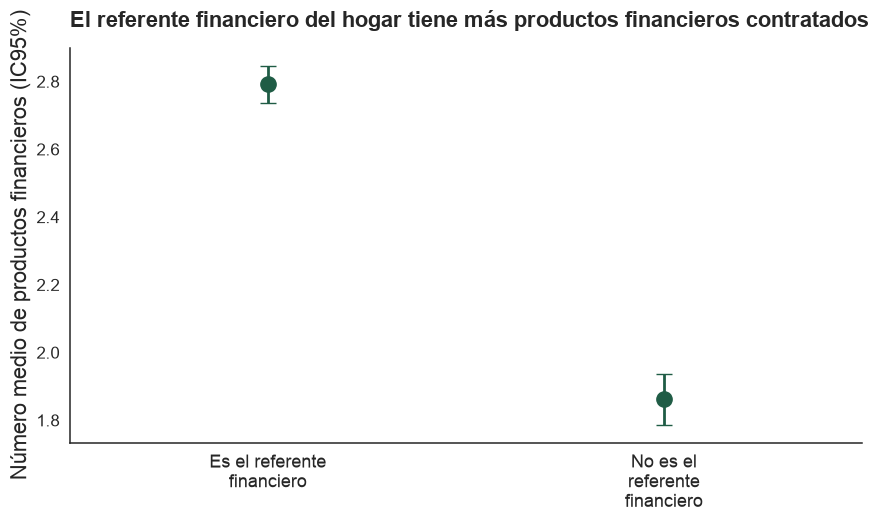


**Interpretación.** El número medio de productos financieros es 1.86 entre quienes NO son el referente financiero del hogar, y 2.79 entre quienes sí lo son (diferencia de 0.93 productos).

**Conclusión.** Ser la persona de referencia financiera del hogar se asocia con una relación mucho más amplia con productos financieros.

**Implicaciones.** Tiene sentido comercial: es más eficiente dirigir la comunicación de producto hacia quien efectivamente gestiona las finanzas del hogar, no hacia cualquier miembro adulto por igual.

**Recomendaciones.** Identificar, cuando sea posible, quién es el referente financiero dentro de un hogar-cliente y priorizar sobre esa persona las comunicaciones de producto y las renovaciones de cartera.


**Cautela metodológica.** Variable solo aplicable a hogares de más de un miembro. La dirección de causalidad no está clara: gestionar más productos puede convertir a alguien en el referente, no solo al revés.

**Entrada para el análisis de competencias financieras (H06).** En el ranking completo, `es_referente_financiero_hogar` también se asocia con `score_alfabetizacion_financiera` (efecto 0.128, dirección positiva, p ajustada 8.17e-18). Quien gestiona las finanzas del hogar tiende a obtener mejores resultados en el test de competencias — un punto de partida razonable para que el compañero explore si el conocimiento financiero se concentra en una persona por hogar, y qué implica eso para el diseño de contenidos educativos.

,grupo,n,media,ci_low,ci_high
0,Es el referente financiero,4737,2.79,2.74,2.85
1,No es el referente financiero,2065,1.86,1.79,1.94


In [178]:
# INS-V3-07 — Nº medio de productos financieros según referente financiero del hogar

tabla_referente_productos = resumen_media(
    df_analitico,
    df_analitico["es_referente_financiero_hogar"].map({0.0: "No es el referente financiero", 1.0: "Es el referente financiero"}),
    df_analitico["n_productos_financieros"],
)

fig, ax = plt.subplots(figsize=(9, 5.5))
x = np.arange(len(tabla_referente_productos))
ax.errorbar(
    x, tabla_referente_productos["media"],
    yerr=[
        tabla_referente_productos["media"] - tabla_referente_productos["ci_low"],
        tabla_referente_productos["ci_high"] - tabla_referente_productos["media"],
    ],
    fmt="o", markersize=11, capsize=6, linewidth=2, color=COLOR_PRINCIPAL,
)
aplicar_etiquetas_x(ax, x, tabla_referente_productos["grupo"])
ax.set_xlim(-0.5, len(tabla_referente_productos) - 0.5)
ax.set_title("El referente financiero del hogar tiene más productos financieros contratados", loc="left", pad=15, weight="bold")
estilo_ejes(ax, ylabel="Número medio de productos financieros (IC95%)")
plt.tight_layout()
plt.show()

ext = diferencia_extremos(tabla_referente_productos, "media")
fila_ref = tabla_referente_productos.loc[tabla_referente_productos["grupo"].eq("Es el referente financiero")].iloc[0]
fila_no_ref = tabla_referente_productos.loc[tabla_referente_productos["grupo"].eq("No es el referente financiero")].iloc[0]

# Correlación con competencias financieras (H06): se calcula aquí solo para señalar el
# posible punto de entrada al análisis del compañero, no para interpretarlo en este notebook.
fila_alfabet = ranking_completo[
    (ranking_completo["objetivo"].eq("score_alfabetizacion_financiera"))
    & (ranking_completo["candidata"].eq("es_referente_financiero_hogar"))
]

bloque_texto(
    interpretacion=(
        f"El número medio de productos financieros es {fila_no_ref['media']:.2f} entre quienes NO "
        f"son el referente financiero del hogar, y {fila_ref['media']:.2f} entre quienes sí lo son "
        f"(diferencia de {fila_ref['media'] - fila_no_ref['media']:.2f} productos)."
    ),
    conclusion=(
        "Ser la persona de referencia financiera del hogar se asocia con una relación mucho más "
        "amplia con productos financieros."
    ),
    implicaciones=(
        "Tiene sentido comercial: es más eficiente dirigir la comunicación de producto hacia quien "
        "efectivamente gestiona las finanzas del hogar, no hacia cualquier miembro adulto por igual."
    ),
    recomendaciones=(
        "Identificar, cuando sea posible, quién es el referente financiero dentro de un hogar-cliente "
        "y priorizar sobre esa persona las comunicaciones de producto y las renovaciones de cartera."
    ),
    cautela=(
        "Variable solo aplicable a hogares de más de un miembro. La dirección de causalidad no está "
        "clara: gestionar más productos puede convertir a alguien en el referente, no solo al revés."
    ),
)

if not fila_alfabet.empty:
    r = fila_alfabet.iloc[0]
    display(Markdown(
        "**Entrada para el análisis de competencias financieras (H06).** "
        f"En el ranking completo, `es_referente_financiero_hogar` también se asocia con "
        f"`score_alfabetizacion_financiera` (efecto {r['efecto']:.3f}, dirección {r['direccion'].lower()}, "
        f"p ajustada {r['p_ajustada_fdr']:.2e}). Quien gestiona las finanzas del hogar tiende a "
        "obtener mejores resultados en el test de competencias — un punto de partida razonable para "
        "que el compañero explore si el conocimiento financiero se concentra en una persona por "
        "hogar, y qué implica eso para el diseño de contenidos educativos."
    ))

display(tabla_referente_productos[["grupo", "n", "media", "ci_low", "ci_high"]].round(2))

## Síntesis final — Fase 4 (V3)

**Resumen de los siete hallazgos:**

1. **Impaciencia temporal (D):** predictor limpio y fuerte de menor ahorro y menor uso de banca
   digital — una actitud, no solo una restricción económica.
2. **Edad (INE):** el ahorro y la banca digital caen de forma sostenida con la edad; el efecto de
   la banca digital sobre el ahorro se mantiene dentro de cada tramo.
3. **Canal preferido de relación con el banco (B):** se invierte casi por completo entre jóvenes
   (móvil/apps) y sénior (oficina presencial) — el efecto de edad más grande de todo el bloque B.
4. **Uso de apps de control de gastos (J):** fuertemente asociado al uso de banca digital — una
   funcionalidad que Banco Atlas ya puede activar como puerta de entrada a la digitalización.
5. **Colchón de liquidez (J):** el predictor más fuerte de fragilidad financiera tras la
   corrección del índice; mide resiliencia ANTES de que ocurra un problema.
6. **Percepción de estrechez (D) y planificación de gastos (J):** la autopercepción coincide con
   la fragilidad objetiva; la planificación de gastos correlaciona con MÁS fragilidad, no menos —
   probablemente porque la escasez motiva planificar, y no al revés.
7. **Rol de decisión en el hogar (F):** decidir en solitario sobre el patrimonio se asocia con
   más productos financieros — útil para dirigir la comunicación comercial dentro del hogar.
8. **Referente financiero del hogar (F):** el referente financiero tiene más productos, y además
   puntúa más alto en competencias financieras — **entrada directa para el análisis del compañero**.

### Respuesta a la pregunta de negocio

*És necessari adaptar les nostres ofertes actuals o crear-ne de noves en funció de les
tendències nacionals en comportament financer?*

**Sí**, y la evidencia de esta ampliación apunta a segmentar por **actitud y rol dentro del
hogar**, no solo por edad o renta:

- Perfiles **impacientes** necesitan mecanismos de compromiso (ahorro automático, recompensas
  inmediatas), no solo más información.
- Perfiles con **colchón de liquidez corto** necesitan fondos de emergencia ANTES de que aparezca
  un impago — es una señal preventiva, no solo diagnóstica.
- Dentro de un mismo hogar, **quien decide y quien es el referente financiero** debe ser el
  destinatario principal de la comunicación de producto, no cualquier miembro adulto por igual.
- El uso de **apps de control de gastos** es una vía de entrada natural a la digitalización que ya
  está disponible para activar.
- El **canal de comunicación de cada campaña** debe variar con la edad del segmento objetivo:
  app/web para captación en menores de 45, oficina y refuerzo telefónico a partir de 55 años.

### Nota de coordinación con competencias financieras

`es_referente_financiero_hogar` se comparte como entrada directa para H06. Además, como ya se
señaló en la ampliación anterior de este notebook: dado que la edad y el nivel educativo puntúan
de forma similar de alto en el motor, conviene comprobar si el efecto de las competencias
financieras se sostiene controlando por edad y educación, para no atribuir a la alfabetización
financiera un efecto que en realidad es generacional o educativo.

# FASE 5 — Cruce entre Comportamiento (ECF) y Banco Atlas

Esta fase responde a una pregunta de seguimiento sobre los hallazgos de H01 (¿qué factores
explican el ahorro en los últimos 12 meses?): de los predictores más fuertes de la ECF —
**nivel educativo, ingresos del hogar, colchón de liquidez, edad y uso de banca digital** —,
¿cuáles tienen un correlato real y utilizable en los datos propios de Banco Atlas, y cuál sería
el factor ideal para diseñar una política de ofertas de ahorro/depósito segmentada por perfil de
cliente?

**Importante — qué es y qué NO es este cruce.** La ECF (Encuesta de Competencias Financieras del
Banco de España/INE) y el dataset de Banco Atlas (`2026-07-20_3_bank_dataset_transformed.csv`)
son **fuentes distintas, con poblaciones distintas y sin identificador común**: la ECF es una
encuesta representativa del conjunto de hogares españoles, mientras que el dataset de Banco Atlas
es la cartera propia de clientes del banco (estructura de tipo campaña de marketing bancario,
con `deposit` — contratación de un depósito — como variable de conversión). **No existe ninguna
combinación de columnas que permita cruzar registro a registro estas dos fuentes.**

Lo que sí es válido, y es lo que hace esta fase, es una **triangulación metodológica**: repetir,
sobre cada fuente por separado, el mismo tipo de análisis segmentado (con las mismas pruebas
estadísticas — chi-cuadrado y V de Cramér — ya usadas en el motor de este notebook), y comparar
si la dirección y la forma de la relación coinciden. Esto permite validar qué predictores de la
ECF son:

1. **Observables** en los sistemas de Banco Atlas sin necesidad de encuesta ni modelo.
2. **Consistentes** en dirección con lo encontrado en la ECF.
3. **Accionables** para diseñar una política de segmentación real.

## 21. Carga del dataset de Banco Atlas

Se usa la versión transformada más reciente, que ya incluye los tramos de edad, el nivel
educativo etiquetado, el saldo y la segmentación de clientes construidos en fases previas del
proyecto (fuera de este notebook).

In [179]:
BANK_DATA_PATH = DATA_DIR / "2026-07-20_3_bank_dataset_transformed.csv"

if not BANK_DATA_PATH.exists():
    raise FileNotFoundError(
        f"No se encuentra el fichero requerido: {BANK_DATA_PATH}\n"
        "Comprueba que el CSV de Banco Atlas está en ../Data/."
    )

df_banco_atlas = pd.read_csv(BANK_DATA_PATH)

print(f"Clientes Banco Atlas: {len(df_banco_atlas):,} | Variables: {df_banco_atlas.shape[1]}")
print(f"Tasa global de contratación de depósito: {df_banco_atlas['deposit'].mean() * 100:.1f}%")
display(df_banco_atlas[["age", "age_group", "education_label", "balance", "job_profile", "segment_label", "deposit"]].head(5))

columnas_income = [c for c in df_banco_atlas.columns if "income" in c.lower() or "ingres" in c.lower() or "renta" in c.lower()]
print(f"Columnas relacionadas con ingresos en el dataset de Banco Atlas: {columnas_income if columnas_income else 'NINGUNA — el campo no existe.'}")

Clientes Banco Atlas: 11,150 | Variables: 32
Tasa global de contratación de depósito: 47.4%


,age,age_group,education_label,balance,job_profile,segment_label,deposit
0,59.0,55-64 Mediana edad,Secondary,2343,White Collar,Adultos consolidados,1
1,56.0,55-64 Mediana edad,Secondary,45,White Collar,Adultos consolidados,1
2,41.0,35-44 Adultos iniciales,Secondary,1270,White Collar,Jovenes en consolidación,1
3,55.0,55-64 Mediana edad,Secondary,2476,Blue Collar,Adultos consolidados,1
4,54.0,45-54 Adultos maduros,Tertiary,184,White Collar,Adultos consolidados,1


Columnas relacionadas con ingresos en el dataset de Banco Atlas: NINGUNA — el campo no existe.


## 22. Validación gráfica del Top 5 de insights de ahorro (H01)

Se recuperan del ranking ya calculado en este mismo notebook (secciones 9–18) los cinco
predictores de `ahorra_12m` con mayor tamaño de efecto, eliminando las variables que son la misma
edad expresada de formas distintas (`a0400`, `age`, `a04` son redundantes con `tramo_edad`).

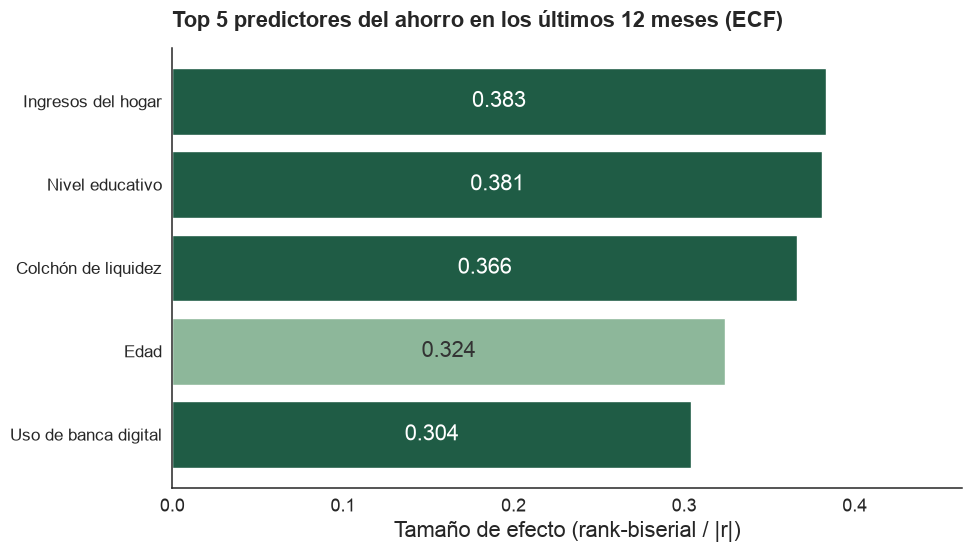

,etiqueta,candidata,efecto,direccion,n_valido,p_ajustada_fdr
0,Ingresos del hogar,j1300,0.382846,Positiva,7755,3.220457e-140
1,Nivel educativo,a1100,0.380811,Positiva,7755,1.278380e-148
2,Colchón de liquidez,j0400,0.366159,Positiva,7755,5.083981e-141
3,Edad,tramo_edad,-0.323755,Negativa,7746,9.355375e-108
4,Uso de banca digital,usa_banca_digital,0.303979,Positiva,7748,9.931976e-155


In [180]:
ETIQUETAS_TOP5_AHORRO = {
    "a1100": "Nivel educativo",
    "j1300": "Ingresos del hogar",
    "j0400": "Colchón de liquidez",
    "tramo_edad": "Edad",
    "usa_banca_digital": "Uso de banca digital",
}

top5_ahorro = (
    ranking_completo[
        ranking_completo["objetivo"].eq("ahorra_12m")
        & ranking_completo["significativa_fdr"]
        & ranking_completo["candidata"].isin(ETIQUETAS_TOP5_AHORRO)
    ]
    .drop_duplicates(subset="candidata")
    .assign(etiqueta=lambda d: d["candidata"].map(ETIQUETAS_TOP5_AHORRO))
    .sort_values("efecto_abs", ascending=False)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(10, 5.8))
y_pos = np.arange(len(top5_ahorro))
colores_barra = [COLOR_PRINCIPAL if d == "Positiva" else COLOR_SECUNDARIO for d in top5_ahorro["direccion"]]
ax.barh(y_pos, top5_ahorro["efecto_abs"], color=colores_barra)
ax.set_yticks(y_pos, top5_ahorro["etiqueta"])
ax.invert_yaxis()
ax.set_xlim(0, top5_ahorro["efecto_abs"].max() + 0.08)
ax.set_title("Top 5 predictores del ahorro en los últimos 12 meses (ECF)", loc="left", pad=15, weight="bold")
estilo_ejes(ax, xlabel="Tamaño de efecto (rank-biserial / |r|)")
etiquetas_barras(ax, decimales=3, sufijo="", horizontal=True)
plt.tight_layout()
plt.show()

display(top5_ahorro[["etiqueta", "candidata", "efecto", "direccion", "n_valido", "p_ajustada_fdr"]])

## 23. ¿Qué variables del Top 5 existen realmente en los datos de Banco Atlas?

Antes de comparar, se audita explícitamente qué predictores de la ECF tienen un campo
observable equivalente en el dataset de Banco Atlas, sin asumir nada:

| Predictor ECF (H01) | Variable en Banco Atlas | ¿Existe? |
|---|---|---|
| Nivel educativo (`a1100`) | `education` / `education_label` / `education_rank` | Sí — 95,6% cobertura |
| Ingresos del hogar (`j1300`) | — | **No existe ningún campo de ingresos**, ni en este CSV ni en ninguna versión raw anterior |
| Colchón de liquidez (`j0400`) | `balance` (saldo en cuenta) | Proxy parcial — no mide "meses de gasto cubierto", sino saldo puntual, y solo el saldo en Banco Atlas (no en otras entidades) |
| Edad (`tramo_edad`) | `age` / `age_group` | Sí — 100% cobertura, mismos tramos de tipo INE ya usados en este notebook |
| Uso de banca digital (`usa_banca_digital`) | — (no hay canal digital en este dataset, es un dataset de campañas telefónicas) | No aplica a este cruce |

Se valida esto último con código, no solo de memoria:

In [181]:
print("Ingresos: columnas candidatas encontradas ->", columnas_income or "ninguna (confirmado, no existe el campo)")
print()
print("Edad -> presente:", "age" in df_banco_atlas.columns, "| age_group -> presente:", "age_group" in df_banco_atlas.columns)
print("Educación -> presente:", "education" in df_banco_atlas.columns, "| cobertura:", f"{df_banco_atlas['education'].ne('unknown').mean()*100:.1f}%")
print("Saldo (proxy de liquidez) -> presente:", "balance" in df_banco_atlas.columns, "| nulos:", df_banco_atlas["balance"].isna().sum())

Ingresos: columnas candidatas encontradas -> ninguna (confirmado, no existe el campo)

Edad -> presente: True | age_group -> presente: True
Educación -> presente: True | cobertura: 95.6%
Saldo (proxy de liquidez) -> presente: True | nulos: 0


## 24. Edad: comparación de forma entre ECF y Banco Atlas

En la ECF, el ahorro cae de forma **monótona** con la edad (ya visto en la Fase 4, sección H01/H03
de tramo de edad). En Banco Atlas, la variable comparable es `deposit` (contratación real de un
depósito, no autoinforme de ahorro). Se comprueba si el patrón es el mismo.

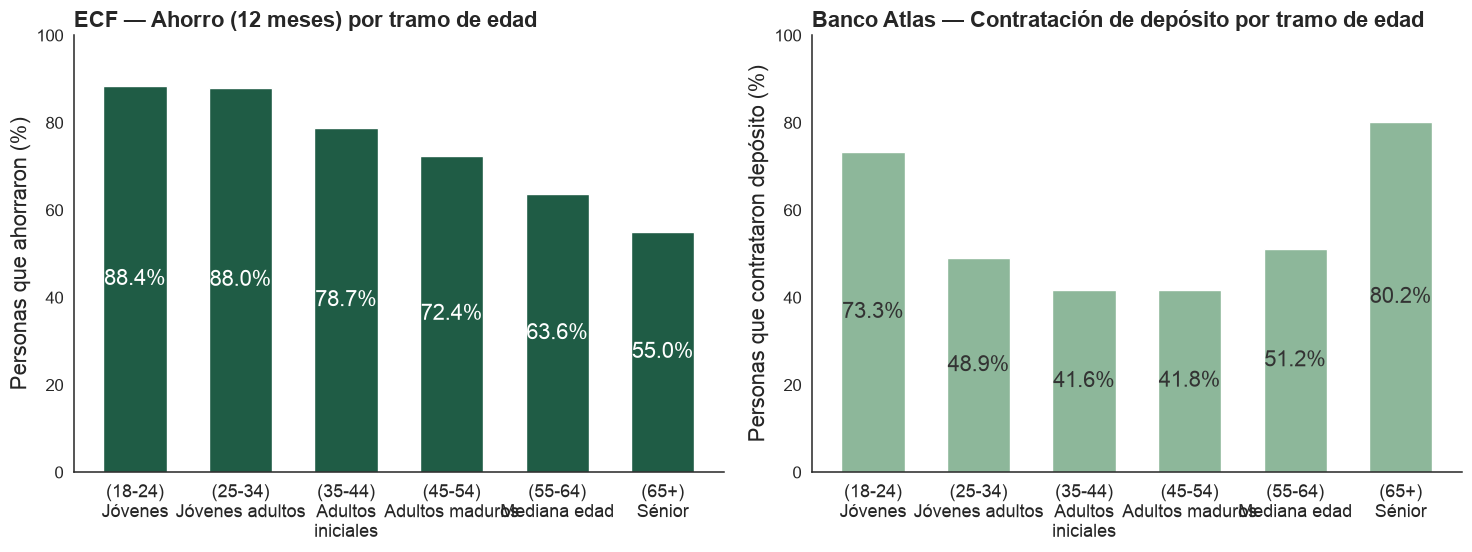


**Interpretación.** En la ECF, el ahorro cae de forma sostenida con la edad. En Banco Atlas, la contratación de depósito sigue una forma de **U**: 73.3% en «18-24» y 80.2% en «65+», frente a un mínimo de 41.6% en los tramos intermedios (36-54 años). La asociación es muy significativa (V de Cramér = 0.175, p = 1.39e-71, n=11,150), pero la correlación lineal simple edad-depósito es prácticamente nula (r = 0.035).

**Conclusión.** La edad SÍ es un predictor fuerte y accionable en los datos reales de Banco Atlas, pero su forma es distinta a la de la ECF: no es un declive monótono, es una U con los mejores resultados en los extremos (jóvenes y séniors) y el peor en la franja 36-54.

**Implicaciones.** Una correlación lineal simple (r≈0) habría llevado a descartar erróneamente la edad como predictor. Solo el análisis por tramos (igual que se hizo con tramo_edad en la ECF) revela el patrón real. Es la misma lección que ya se aplicó al corregir numeric_safe() en la sección 19: las relaciones no lineales exigen segmentar, no correlacionar.

**Recomendaciones.** Diseñar la política de captación de depósitos por edad usando la curva real de Banco Atlas (priorizar 18-24 y 65+), no la curva de la ECF (que mide un comportamiento distinto: haber ahorrado de cualquier forma, frente a haber contratado un depósito concreto tras una campaña).


**Cautela metodológica.** `ahorra_12m` (ECF) y `deposit` (Banco Atlas) miden conductas distintas — ahorro general declarado frente a conversión en una campaña comercial concreta — por lo que la comparación es orientativa, no una validación directa de la misma variable.

,age_group,n,porcentaje,ci_low,ci_high
0,18-24 Jóvenes,281,73.3,68.1,78.5
1,25-34 Jóvenes adultos,3619,48.9,47.3,50.6
2,35-44 Adultos iniciales,3371,41.6,40.0,43.3
3,45-54 Adultos maduros,2202,41.8,39.8,43.9
4,55-64 Mediana edad,1253,51.2,48.4,53.9
5,65+ Sénior,424,80.2,76.4,84.0


In [182]:
orden_edad_banco = ["18-24 Jóvenes", "25-34 Jóvenes adultos", "35-44 Adultos iniciales",
                    "45-54 Adultos maduros", "55-64 Mediana edad", "65+ Sénior"]

tabla_edad_deposito = (
    df_banco_atlas.groupby("age_group", observed=True)["deposit"]
    .agg(n="size", proporcion="mean")
    .reindex(orden_edad_banco)
    .reset_index()
)
tabla_edad_deposito["porcentaje"] = tabla_edad_deposito["proporcion"] * 100
se_edad = np.sqrt(tabla_edad_deposito["proporcion"] * (1 - tabla_edad_deposito["proporcion"]) / tabla_edad_deposito["n"])
tabla_edad_deposito["ci_low"] = np.clip((tabla_edad_deposito["proporcion"] - 1.96 * se_edad) * 100, 0, 100)
tabla_edad_deposito["ci_high"] = np.clip((tabla_edad_deposito["proporcion"] + 1.96 * se_edad) * 100, 0, 100)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.8))

ax = axes[0]
x = np.arange(len(tabla_edad_ahorro))
ax.bar(x, tabla_edad_ahorro["porcentaje"], color=COLOR_PRINCIPAL, width=0.6)
aplicar_etiquetas_x(ax, x, tabla_edad_ahorro["grupo"], rotacion=20)
ax.set_ylim(0, 100)
ax.set_title("ECF — Ahorro (12 meses) por tramo de edad", loc="left", weight="bold")
estilo_ejes(ax, ylabel="Personas que ahorraron (%)")
etiquetas_barras(ax)

ax = axes[1]
x = np.arange(len(tabla_edad_deposito))
ax.bar(x, tabla_edad_deposito["porcentaje"], color=COLOR_SECUNDARIO, width=0.6)
aplicar_etiquetas_x(ax, x, tabla_edad_deposito["age_group"], rotacion=20)
ax.set_ylim(0, 100)
ax.set_title("Banco Atlas — Contratación de depósito por tramo de edad", loc="left", weight="bold")
estilo_ejes(ax, ylabel="Personas que contrataron depósito (%)")
etiquetas_barras(ax)

plt.tight_layout()
plt.show()

tabla_contingencia_edad = pd.crosstab(df_banco_atlas["age_group"], df_banco_atlas["deposit"])
chi2_edad, p_edad, _, _ = stats.chi2_contingency(tabla_contingencia_edad)
v_edad = cramers_v(tabla_contingencia_edad)
corr_edad_deposito = df_banco_atlas["age"].corr(df_banco_atlas["deposit"])

bloque_texto(
    interpretacion=(
        f"En la ECF, el ahorro cae de forma sostenida con la edad. En Banco Atlas, la "
        f"contratación de depósito sigue una forma de **U**: {tabla_edad_deposito.iloc[0]['porcentaje']:.1f}% "
        f"en «18-24» y {tabla_edad_deposito.iloc[-1]['porcentaje']:.1f}% en «65+», frente a un mínimo de "
        f"{tabla_edad_deposito['porcentaje'].min():.1f}% en los tramos intermedios (36-54 años). "
        f"La asociación es muy significativa (V de Cramér = {v_edad:.3f}, p = {p_edad:.2e}, n={tabla_contingencia_edad.to_numpy().sum():,}), "
        f"pero la correlación lineal simple edad-depósito es prácticamente nula (r = {corr_edad_deposito:.3f})."
    ),
    conclusion=(
        "La edad SÍ es un predictor fuerte y accionable en los datos reales de Banco Atlas, pero su "
        "forma es distinta a la de la ECF: no es un declive monótono, es una U con los mejores "
        "resultados en los extremos (jóvenes y séniors) y el peor en la franja 36-54."
    ),
    implicaciones=(
        "Una correlación lineal simple (r≈0) habría llevado a descartar erróneamente la edad como "
        "predictor. Solo el análisis por tramos (igual que se hizo con tramo_edad en la ECF) revela "
        "el patrón real. Es la misma lección que ya se aplicó al corregir numeric_safe() en la "
        "sección 19: las relaciones no lineales exigen segmentar, no correlacionar."
    ),
    recomendaciones=(
        "Diseñar la política de captación de depósitos por edad usando la curva real de Banco "
        "Atlas (priorizar 18-24 y 65+), no la curva de la ECF (que mide un comportamiento distinto: "
        "haber ahorrado de cualquier forma, frente a haber contratado un depósito concreto tras una "
        "campaña)."
    ),
    cautela=(
        "`ahorra_12m` (ECF) y `deposit` (Banco Atlas) miden conductas distintas — ahorro general "
        "declarado frente a conversión en una campaña comercial concreta — por lo que la comparación "
        "es orientativa, no una validación directa de la misma variable."
    ),
)

display(tabla_edad_deposito[["age_group", "n", "porcentaje", "ci_low", "ci_high"]].round(1))

## 25. Nivel educativo: comparación de forma entre ECF y Banco Atlas

`a1100` (ECF) no se había graficado aún frente a `ahorra_12m` en este notebook (sí se usó, en la
ampliación anterior, frente al ahorro con cruce de edad, pero no dentro de esta versión). Se
construye aquí junto a su equivalente en Banco Atlas (`education_label`).

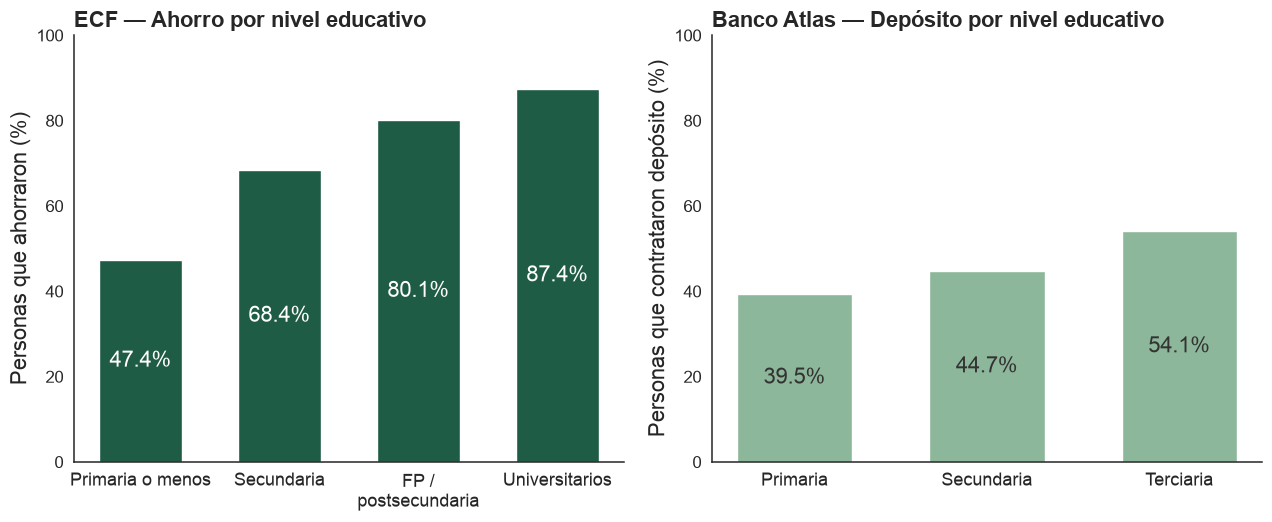


**Interpretación.** En la ECF, el ahorro sube de 47.4% a 87.4% entre «Primaria o menos» y «Universitarios». En Banco Atlas, la contratación de depósito sube de 39.5% (Primaria) a 54.1% (Terciaria) — mismo sentido, gradiente monótono en ambas fuentes (V de Cramér = 0.106, p = 9.00e-27, n=10,654).

**Conclusión.** El nivel educativo es el segundo predictor validado en ambas fuentes, con la misma dirección y una forma consistente (monótona creciente), a diferencia de la edad.

**Implicaciones.** Es un candidato sólido para refinar la segmentación por edad: dentro de un mismo tramo de edad, el nivel educativo sigue diferenciando la propensión a contratar depósitos.

**Recomendaciones.** Usar el nivel educativo como criterio secundario de priorización dentro de cada tramo de edad (p. ej. Banco Atlas ya recomendó en su informe de la semana 1 dirigir ofertas premium a solteros con estudios superiores).


**Cautela metodológica.** El nivel educativo y la edad están correlacionados (ver sección 27): parte de este efecto puede solaparse con el de la edad y no sumar información completamente independiente.

,etiqueta,n,porcentaje
0,Primaria,1498,39.5
1,Secundaria,5472,44.7
2,Terciaria,3684,54.1


In [183]:
MAPA_EDUCACION_ECF = {
    "a": "Primaria o menos", "b": "Primaria o menos",
    "c": "Secundaria", "d": "Secundaria",
    "e": "FP / postsecundaria", "f": "FP / postsecundaria",
    "g": "Universitarios", "h": "Universitarios", "i": "Universitarios",
}
orden_educacion_ecf = ["Primaria o menos", "Secundaria", "FP / postsecundaria", "Universitarios"]

letra_a1100 = df_analitico["a1100"].astype("string").str.strip().str.slice(0, 1).str.lower()
grupo_educacion_ecf = letra_a1100.map(MAPA_EDUCACION_ECF)

tabla_educacion_ahorro = resumen_proporcion(df_analitico, grupo_educacion_ecf, df_analitico["ahorra_12m"])
tabla_educacion_ahorro["grupo"] = pd.Categorical(tabla_educacion_ahorro["grupo"], orden_educacion_ecf, ordered=True)
tabla_educacion_ahorro = tabla_educacion_ahorro.sort_values("grupo")

orden_educacion_banco = ["Primary", "Secondary", "Tertiary"]
etiquetas_educacion_banco = {"Primary": "Primaria", "Secondary": "Secundaria", "Tertiary": "Terciaria"}

tabla_educacion_deposito = (
    df_banco_atlas[df_banco_atlas["education_label"].isin(orden_educacion_banco)]
    .groupby("education_label", observed=True)["deposit"]
    .agg(n="size", proporcion="mean")
    .reindex(orden_educacion_banco)
    .reset_index()
)
tabla_educacion_deposito["porcentaje"] = tabla_educacion_deposito["proporcion"] * 100
tabla_educacion_deposito["etiqueta"] = tabla_educacion_deposito["education_label"].map(etiquetas_educacion_banco)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

ax = axes[0]
x = np.arange(len(tabla_educacion_ahorro))
ax.bar(x, tabla_educacion_ahorro["porcentaje"], color=COLOR_PRINCIPAL, width=0.6)
aplicar_etiquetas_x(ax, x, tabla_educacion_ahorro["grupo"], rotacion=15)
ax.set_ylim(0, 100)
ax.set_title("ECF — Ahorro por nivel educativo", loc="left", weight="bold")
estilo_ejes(ax, ylabel="Personas que ahorraron (%)")
etiquetas_barras(ax)

ax = axes[1]
x = np.arange(len(tabla_educacion_deposito))
ax.bar(x, tabla_educacion_deposito["porcentaje"], color=COLOR_SECUNDARIO, width=0.6)
aplicar_etiquetas_x(ax, x, tabla_educacion_deposito["etiqueta"])
ax.set_ylim(0, 100)
ax.set_title("Banco Atlas — Depósito por nivel educativo", loc="left", weight="bold")
estilo_ejes(ax, ylabel="Personas que contrataron depósito (%)")
etiquetas_barras(ax)

plt.tight_layout()
plt.show()

tabla_contingencia_edu = pd.crosstab(
    df_banco_atlas.loc[df_banco_atlas["education_label"].isin(orden_educacion_banco), "education_label"],
    df_banco_atlas.loc[df_banco_atlas["education_label"].isin(orden_educacion_banco), "deposit"],
)
chi2_edu, p_edu, _, _ = stats.chi2_contingency(tabla_contingencia_edu)
v_edu = cramers_v(tabla_contingencia_edu)

ext_ecf = diferencia_extremos(tabla_educacion_ahorro, "porcentaje")
ext_banco = diferencia_extremos(tabla_educacion_deposito.rename(columns={"etiqueta": "grupo"}), "porcentaje")

bloque_texto(
    interpretacion=(
        f"En la ECF, el ahorro sube de {ext_ecf[0]['porcentaje']:.1f}% a {ext_ecf[1]['porcentaje']:.1f}% "
        f"entre «{ext_ecf[0]['grupo']}» y «{ext_ecf[1]['grupo']}». En Banco Atlas, la contratación de "
        f"depósito sube de {ext_banco[0]['porcentaje']:.1f}% (Primaria) a {ext_banco[1]['porcentaje']:.1f}% "
        f"(Terciaria) — mismo sentido, gradiente monótono en ambas fuentes "
        f"(V de Cramér = {v_edu:.3f}, p = {p_edu:.2e}, n={tabla_contingencia_edu.to_numpy().sum():,})."
    ),
    conclusion=(
        "El nivel educativo es el segundo predictor validado en ambas fuentes, con la misma "
        "dirección y una forma consistente (monótona creciente), a diferencia de la edad."
    ),
    implicaciones=(
        "Es un candidato sólido para refinar la segmentación por edad: dentro de un mismo tramo de "
        "edad, el nivel educativo sigue diferenciando la propensión a contratar depósitos."
    ),
    recomendaciones=(
        "Usar el nivel educativo como criterio secundario de priorización dentro de cada tramo de "
        "edad (p. ej. Banco Atlas ya recomendó en su informe de la semana 1 dirigir ofertas premium "
        "a solteros con estudios superiores)."
    ),
    cautela=(
        "El nivel educativo y la edad están correlacionados (ver sección 27): parte de este efecto "
        "puede solaparse con el de la edad y no sumar información completamente independiente."
    ),
)

display(tabla_educacion_deposito[["etiqueta", "n", "porcentaje"]].round(1))

## 26. Colchón de liquidez (ECF) y saldo en cuenta (Banco Atlas)

No son la misma medida: `j0400` (ECF) es una estimación subjetiva de "cuántos meses podría cubrir
sus gastos sin ingresos"; `balance` (Banco Atlas) es el saldo real en la cuenta en un momento
dado, y solo refleja lo que el cliente tiene en Banco Atlas (no en otras entidades). Aun así, es
la única variable numérica objetiva de capacidad financiera disponible en ambas fuentes, y merece
comprobarse.

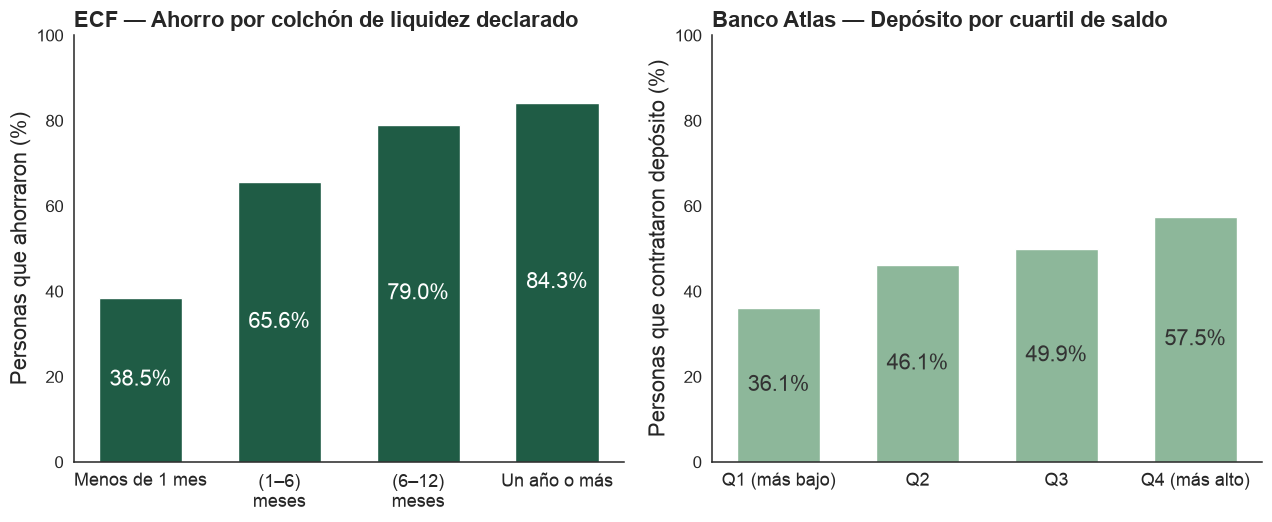


**Interpretación.** En la ECF, el ahorro sube de 38.5% («Menos de 1 mes») a 84.3% («Un año o más»). En Banco Atlas, la contratación de depósito sube de 36.1% (Q1) a 57.5% (Q4) — gradiente monótono también aquí (V de Cramér = 0.155, p = 1.80e-57; correlación lineal saldo-depósito = 0.081).

**Conclusión.** El saldo (como proxy parcial del colchón de liquidez) también se valida en ambas fuentes: más capacidad financiera disponible, más ahorro declarado en la ECF y más conversión real en Banco Atlas.

**Implicaciones.** Es la única de las tres variables validadas que Banco Atlas puede observar de forma totalmente objetiva y sin encuesta (no depende de lo que el cliente declare, sino de un dato transaccional propio).

**Recomendaciones.** Usar el saldo como criterio de refinamiento adicional dentro de cada tramo de edad, en la línea de lo que ya hace la política de riesgo crediticio de Banco Atlas (que ya segmenta por cuartil de saldo, ver informe del 13/07): un cliente joven con saldo alto y uno joven con saldo bajo probablemente necesiten ofertas de ahorro distintas.


**Cautela metodológica.** El saldo solo refleja lo que el cliente tiene EN Banco Atlas; un cliente con mucho ahorro repartido en otras entidades aparecería aquí con saldo bajo sin serlo realmente. No equivale al colchón de liquidez total del hogar que mide la ECF.

,balance_q,n,porcentaje
0,Q1 (más bajo),2798,36.1
1,Q2,2778,46.1
2,Q3,2786,49.9
3,Q4 (más alto),2788,57.5


In [184]:
MAPA_COLCHON_ECF = {
    "a": "Menos de 1 mes", "b": "Menos de 1 mes",
    "c": "1–6 meses", "d": "1–6 meses",
    "e": "6–12 meses", "f": "6–12 meses",
    "g": "Un año o más",
}
orden_colchon_ecf = ["Menos de 1 mes", "1–6 meses", "6–12 meses", "Un año o más"]

letra_j0400 = df_analitico["j0400"].astype("string").str.strip().str.slice(0, 1).str.lower()
grupo_colchon_ecf = letra_j0400.map(MAPA_COLCHON_ECF)

tabla_colchon_ahorro = resumen_proporcion(df_analitico, grupo_colchon_ecf, df_analitico["ahorra_12m"])
tabla_colchon_ahorro["grupo"] = pd.Categorical(tabla_colchon_ahorro["grupo"], orden_colchon_ecf, ordered=True)
tabla_colchon_ahorro = tabla_colchon_ahorro.sort_values("grupo")

df_banco_atlas["balance_q"] = pd.qcut(df_banco_atlas["balance"], 4, labels=["Q1 (más bajo)", "Q2", "Q3", "Q4 (más alto)"])
tabla_saldo_deposito = (
    df_banco_atlas.groupby("balance_q", observed=True)["deposit"]
    .agg(n="size", proporcion="mean")
    .reset_index()
)
tabla_saldo_deposito["porcentaje"] = tabla_saldo_deposito["proporcion"] * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

ax = axes[0]
x = np.arange(len(tabla_colchon_ahorro))
ax.bar(x, tabla_colchon_ahorro["porcentaje"], color=COLOR_PRINCIPAL, width=0.6)
aplicar_etiquetas_x(ax, x, tabla_colchon_ahorro["grupo"])
ax.set_ylim(0, 100)
ax.set_title("ECF — Ahorro por colchón de liquidez declarado", loc="left", weight="bold")
estilo_ejes(ax, ylabel="Personas que ahorraron (%)")
etiquetas_barras(ax)

ax = axes[1]
x = np.arange(len(tabla_saldo_deposito))
ax.bar(x, tabla_saldo_deposito["porcentaje"], color=COLOR_SECUNDARIO, width=0.6)
aplicar_etiquetas_x(ax, x, tabla_saldo_deposito["balance_q"])
ax.set_ylim(0, 100)
ax.set_title("Banco Atlas — Depósito por cuartil de saldo", loc="left", weight="bold")
estilo_ejes(ax, ylabel="Personas que contrataron depósito (%)")
etiquetas_barras(ax)

plt.tight_layout()
plt.show()

tabla_contingencia_saldo = pd.crosstab(df_banco_atlas["balance_q"], df_banco_atlas["deposit"])
chi2_saldo, p_saldo, _, _ = stats.chi2_contingency(tabla_contingencia_saldo)
v_saldo = cramers_v(tabla_contingencia_saldo)
corr_saldo_deposito = df_banco_atlas["balance"].corr(df_banco_atlas["deposit"])

ext_colchon = diferencia_extremos(tabla_colchon_ahorro, "porcentaje")

bloque_texto(
    interpretacion=(
        f"En la ECF, el ahorro sube de {ext_colchon[0]['porcentaje']:.1f}% («{ext_colchon[0]['grupo']}») a "
        f"{ext_colchon[1]['porcentaje']:.1f}% («{ext_colchon[1]['grupo']}»). En Banco Atlas, la "
        f"contratación de depósito sube de {tabla_saldo_deposito.iloc[0]['porcentaje']:.1f}% (Q1) a "
        f"{tabla_saldo_deposito.iloc[-1]['porcentaje']:.1f}% (Q4) — gradiente monótono también aquí "
        f"(V de Cramér = {v_saldo:.3f}, p = {p_saldo:.2e}; correlación lineal saldo-depósito = {corr_saldo_deposito:.3f})."
    ),
    conclusion=(
        "El saldo (como proxy parcial del colchón de liquidez) también se valida en ambas fuentes: "
        "más capacidad financiera disponible, más ahorro declarado en la ECF y más conversión real "
        "en Banco Atlas."
    ),
    implicaciones=(
        "Es la única de las tres variables validadas que Banco Atlas puede observar de forma "
        "totalmente objetiva y sin encuesta (no depende de lo que el cliente declare, sino de un "
        "dato transaccional propio)."
    ),
    recomendaciones=(
        "Usar el saldo como criterio de refinamiento adicional dentro de cada tramo de edad, en la "
        "línea de lo que ya hace la política de riesgo crediticio de Banco Atlas (que ya segmenta "
        "por cuartil de saldo, ver informe del 13/07): un cliente joven con saldo alto y uno joven "
        "con saldo bajo probablemente necesiten ofertas de ahorro distintas."
    ),
    cautela=(
        "El saldo solo refleja lo que el cliente tiene EN Banco Atlas; un cliente con mucho ahorro "
        "repartido en otras entidades aparecería aquí con saldo bajo sin serlo realmente. No "
        "equivale al colchón de liquidez total del hogar que mide la ECF."
    ),
)

display(tabla_saldo_deposito[["balance_q", "n", "porcentaje"]].round(1))

## 27. Ingresos del hogar: por qué no se puede validar

`j1300` es, junto con el nivel educativo, el efecto más alto de toda la historia H01 en la ECF.
Pero, como se comprobó en la sección 22, **no existe ningún campo de ingresos en los datos de
Banco Atlas**, ni en el CSV transformado ni en ninguna versión raw de las cuatro semanas
anteriores del proyecto. No es una variable descartada por decisión analítica: es una variable
que el banco simplemente no captura hoy. Incorporarla exigiría un proyecto de enriquecimiento de
datos (encuesta propia, o estimación a partir de nóminas domiciliadas), no un ajuste de la
política de segmentación actual.

## 28. Corroboración con la segmentación ya existente en Banco Atlas

`segment_label` es una segmentación de clientes ya construida en fases previas del proyecto
(fuera de este notebook). Se comprueba si coincide con la historia de edad/vida que se acaba de
validar.

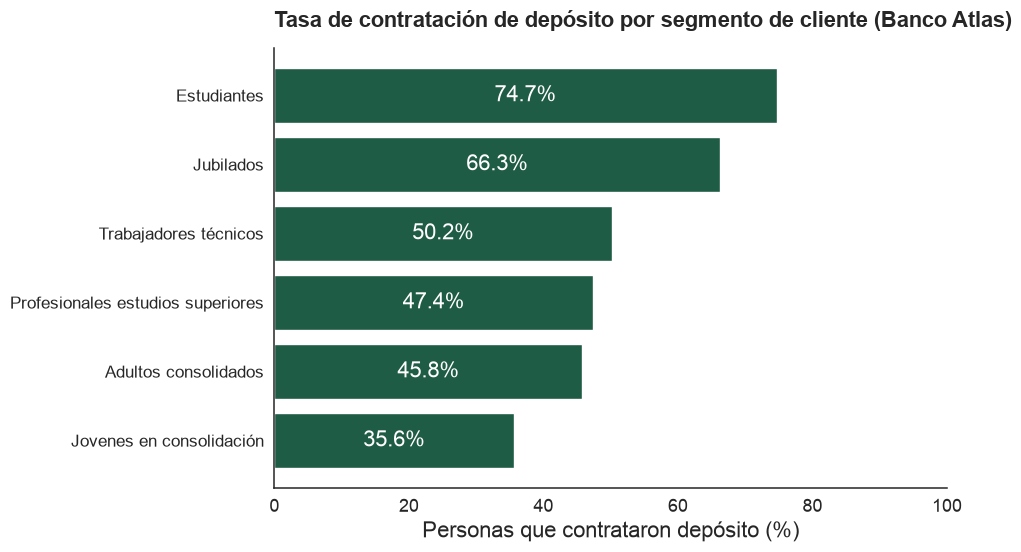

,segment_label,n,porcentaje
1,Estudiantes,359,74.7
3,Jubilados,777,66.3
5,Trabajadores técnicos,2880,50.2
4,Profesionales estudios superiores,2282,47.4
0,Adultos consolidados,2415,45.8
2,Jovenes en consolidación,2437,35.6


Correlaciones de control (Banco Atlas):
  edad vs saldo:              0.112
  edad vs nivel educativo:     -0.196
  edad vs depósito (lineal):   0.035  (compárese con V de Cramér = 0.175 de la sección 24)


In [185]:
tabla_segmento_deposito = (
    df_banco_atlas.groupby("segment_label", observed=True)["deposit"]
    .agg(n="size", proporcion="mean")
    .reset_index()
    .assign(porcentaje=lambda d: d["proporcion"] * 100)
    .sort_values("porcentaje", ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 5.8))
y_pos = np.arange(len(tabla_segmento_deposito))
ax.barh(y_pos, tabla_segmento_deposito["porcentaje"], color=COLOR_PRINCIPAL)
ax.set_yticks(y_pos, tabla_segmento_deposito["segment_label"])
ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.set_title("Tasa de contratación de depósito por segmento de cliente (Banco Atlas)", loc="left", pad=15, weight="bold")
estilo_ejes(ax, xlabel="Personas que contrataron depósito (%)")
etiquetas_barras(ax, horizontal=True)
plt.tight_layout()
plt.show()

display(tabla_segmento_deposito[["segment_label", "n", "porcentaje"]].round(1))

print("Correlaciones de control (Banco Atlas):")
print(f"  edad vs saldo:              {df_banco_atlas['age'].corr(df_banco_atlas['balance']):.3f}")
print(f"  edad vs nivel educativo:     {df_banco_atlas['age'].corr(df_banco_atlas['education_rank']):.3f}")
print(f"  edad vs depósito (lineal):   {df_banco_atlas['age'].corr(df_banco_atlas['deposit']):.3f}  (compárese con V de Cramér = {v_edad:.3f} de la sección 24)")

## Síntesis final — Fase 5

**Validación de lo compartido en la consulta anterior:**

| Predictor ECF (H01) | ¿Contraparte en Banco Atlas? | ¿Misma dirección? | ¿Misma forma? |
|---|---|---|---|
| Edad | Sí (`age`/`age_group`) | Sí (la edad importa en ambas) | **No** — ECF monótona decreciente; Banco Atlas en forma de U |
| Nivel educativo | Sí (`education_label`) | Sí, monótona creciente en ambas | Sí |
| Colchón de liquidez / saldo | Parcial (`balance` como proxy) | Sí, monótona creciente en ambas | Sí (con matiz: solo saldo en Banco Atlas, no colchón total del hogar) |
| Ingresos del hogar | **No existe** | — | — |
| Uso de banca digital | No aplica (dataset de campañas telefónicas) | — | — |

**Conclusión sobre el factor ideal**, confirmando lo ya avanzado:

1. **La edad sigue siendo el factor base ideal para la política de segmentación**: cobertura del
   100%, coste cero, sin necesidad de modelo, y validada con datos reales de conversión de Banco
   Atlas además de con la ECF. Pero su forma de U (no la caída monótona de la ECF) es la que debe
   usarse para diseñar la política: **captación reforzada en 18-24 y 65+, y una oferta distinta —
   no necesariamente de depósito puro — para el tramo 36-54**, que es el valle de conversión en
   ambas fuentes.
2. **Nivel educativo y saldo son refinamientos válidos de segundo nivel**, no alternativas a la
   edad: ambos muestran gradiente monótono y consistente en las dos fuentes, y pueden usarse para
   priorizar dentro de cada tramo de edad (tal como ya recomendó el informe de Banco Atlas de la
   semana 1 para educación, y el de riesgo crediticio para saldo).
3. **Ingresos queda fuera de cualquier política inmediata**: no es una decisión de priorización,
   es una limitación de datos — el campo no existe en los sistemas de Banco Atlas hoy.
4. **Aviso metodológico confirmado**: la correlación lineal simple de la edad con la conversión es
   casi nula (r≈0) en Banco Atlas, pese a que el efecto segmentado es de los más fuertes de todo
   el análisis (V de Cramér). Cualquier análisis futuro sobre esta cartera debe segmentar por
   tramos antes de concluir que una variable "no importa".

**Recomendación operativa final**: política de ofertas de ahorro/depósito en dos niveles — edad
como segmentación base (con su forma de U validada en datos reales, no la forma de la ECF), y
saldo y/o nivel educativo como criterio de refinamiento dentro de cada tramo, replicando y
extendiendo la lógica que Banco Atlas ya empezó a aplicar en sus informes de las semanas 1 y 3.